# Predictive Modelling and Time-Based Validation

This notebook develops predictive models for next-year London property price growth using the final predictor set identified during the data quality and feature analysis stage.

The modelling task is structured as:

**Information available in year t → predict property price growth in year t+1**

Two prediction targets are considered:

- `Target_Average_Price_Growth`
- `Target_Median_Price_Growth`

The final predictive dataset was produced in the previous notebook:

`integrated_data_quality_and_feature_analysis.ipynb`

and is stored as:

`london_property_final_predictive_features_targets.parquet`

The modelling workflow will focus on:

1. Modelling dataset verification
2. Target and predictor availability
3. Temporal train/validation/test design
4. Leakage-safe preprocessing
5. Baseline modelling
6. Model training and comparison
7. Out-of-time evaluation
8. Model interpretation

In [1]:
import pandas as pd

modeling_input_path = (
    "../data/processed/"
    "london_property_final_predictive_features_targets.parquet"
)

df_model = pd.read_parquet(modeling_input_path)

print("=== FINAL PREDICTIVE DATASET LOADED ===")
print("Shape:", df_model.shape)
print("Columns:", len(df_model.columns))

=== FINAL PREDICTIVE DATASET LOADED ===
Shape: (264, 15)
Columns: 15


In [2]:
print("=== MODELING DATASET OVERVIEW ===")

print("\nColumns:")
print(df_model.columns.tolist())

print("\nData types:")
print(df_model.dtypes)

print("\nYear range:")
print(
    df_model["Year"].min(),
    "to",
    df_model["Year"].max()
)

print("\nUnique districts:")
print(df_model["District"].nunique())

print("\nUnique Borough codes:")
print(df_model["Borough_Code"].nunique())

print("\nRows per year:")
print(df_model["Year"].value_counts().sort_index())

=== MODELING DATASET OVERVIEW ===

Columns:
['District', 'Borough_Code', 'Year', 'Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015', 'Target_Average_Price_Growth', 'Target_Median_Price_Growth']

Data types:
District                        object
Borough_Code                    object
Year                             int64
Transactions                     int64
Average_Price                  float64
Median_Price                   float64
Min_Price                        int64
Max_Price                        int64
Average_Price_Growth           float64
Median_Price_Growth            float64
Number_of_Individuals          float64
Median_Income                  float64
AvPTAI2015                     float64
Target_Average_Price_Growth    float64
Target_Median_Price_Growth     float64
dtype: object

Year range:
2018 to 2025

Unique districts:
33

Unique Borough code

In [3]:
print("=== TEMPORAL STRUCTURE ===")

print("\nNumber of unique districts:")
print(df_model["District"].nunique())

print("\nNumber of unique Borough codes:")
print(df_model["Borough_Code"].nunique())

print("\nObservations per year:")
print(df_model.groupby("Year").size())

print("\nTarget availability by year:")
print(
    df_model.groupby("Year")[
        [
            "Target_Average_Price_Growth",
            "Target_Median_Price_Growth"
        ]
    ].count()
)

=== TEMPORAL STRUCTURE ===

Number of unique districts:
33

Number of unique Borough codes:
33

Observations per year:
Year
2018    33
2019    33
2020    33
2021    33
2022    33
2023    33
2024    33
2025    33
dtype: int64

Target availability by year:
      Target_Average_Price_Growth  Target_Median_Price_Growth
Year                                                         
2018                           33                          33
2019                           33                          33
2020                           33                          33
2021                           33                          33
2022                           33                          33
2023                           33                          33
2024                           33                          33
2025                            0                           0


## Temporal Structure and Target Availability

The modelling dataset contains 33 districts observed annually from 2018 to 2025, resulting in 264 district-year observations.

The prediction task follows a one-year-ahead structure:

**Features available in year t → predict property price growth in year t+1**

Therefore, observations from 2018 to 2024 have valid next-year targets, while 2025 observations do not have targets because 2026 outcomes are not available in the dataset.

The 2025 observations will therefore not be used for supervised model training or evaluation.

In [4]:
final_predictors = [
    "Transactions",
    "Average_Price",
    "Median_Price",
    "Min_Price",
    "Max_Price",
    "Average_Price_Growth",
    "Median_Price_Growth",
    "Number_of_Individuals",
    "Median_Income",
    "AvPTAI2015"
]

targets = [
    "Target_Average_Price_Growth",
    "Target_Median_Price_Growth"
]

print("Number of predictors:", len(final_predictors))
print("Number of targets:", len(targets))

Number of predictors: 10
Number of targets: 2


In [5]:
print("=== PREDICTOR MISSINGNESS BY YEAR ===")

missing_by_year = (
    df_model
    .groupby("Year")[final_predictors]
    .apply(lambda x: x.isna().sum())
)

print(missing_by_year)

=== PREDICTOR MISSINGNESS BY YEAR ===
      Transactions  Average_Price  Median_Price  Min_Price  Max_Price  \
Year                                                                    
2018             0              0             0          0          0   
2019             0              0             0          0          0   
2020             0              0             0          0          0   
2021             0              0             0          0          0   
2022             0              0             0          0          0   
2023             0              0             0          0          0   
2024             0              0             0          0          0   
2025             0              0             0          0          0   

      Average_Price_Growth  Median_Price_Growth  Number_of_Individuals  \
Year                                                                     
2018                    33                   33                      0   
2019     

In [6]:
print("\n=== MISSINGNESS PERCENTAGE BY YEAR ===")

missing_pct_by_year = (
    df_model
    .groupby("Year")[final_predictors]
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
)

print(missing_pct_by_year)


=== MISSINGNESS PERCENTAGE BY YEAR ===
      Transactions  Average_Price  Median_Price  Min_Price  Max_Price  \
Year                                                                    
2018           0.0            0.0           0.0        0.0        0.0   
2019           0.0            0.0           0.0        0.0        0.0   
2020           0.0            0.0           0.0        0.0        0.0   
2021           0.0            0.0           0.0        0.0        0.0   
2022           0.0            0.0           0.0        0.0        0.0   
2023           0.0            0.0           0.0        0.0        0.0   
2024           0.0            0.0           0.0        0.0        0.0   
2025           0.0            0.0           0.0        0.0        0.0   

      Average_Price_Growth  Median_Price_Growth  Number_of_Individuals  \
Year                                                                     
2018                 100.0                100.0                    0.0   
2019   

## Temporal Pattern of Predictor Missingness

Predictor missingness is strongly structured by year rather than being randomly distributed across observations.

The 2018 observations lack the historical price-growth predictors because the previous year's growth information is not available. From 2019 to 2023, all ten predictors are available.

In 2024 and 2025, `Number_of_Individuals` and `Median_Income` are completely missing. Since 2025 also has no target values, it cannot be used for supervised training or evaluation.

The 2024 observations remain important because they contain valid 2025 targets and therefore represent the latest possible out-of-time evaluation period. Their missing predictor values must therefore be handled using a leakage-safe approach rather than simply discarding 2024.

In [7]:
print("=== 2024 MISSING FEATURE CHECK ===")

check_2024 = df_model.loc[
    df_model["Year"] == 2024,
    [
        "District",
        "Number_of_Individuals",
        "Median_Income"
    ]
]

print(check_2024.to_string(index=False))

=== 2024 MISSING FEATURE CHECK ===
              District  Number_of_Individuals  Median_Income
  BARKING AND DAGENHAM                    NaN            NaN
                BARNET                    NaN            NaN
                BEXLEY                    NaN            NaN
                 BRENT                    NaN            NaN
               BROMLEY                    NaN            NaN
                CAMDEN                    NaN            NaN
        CITY OF LONDON                    NaN            NaN
   CITY OF WESTMINSTER                    NaN            NaN
               CROYDON                    NaN            NaN
                EALING                    NaN            NaN
               ENFIELD                    NaN            NaN
             GREENWICH                    NaN            NaN
               HACKNEY                    NaN            NaN
HAMMERSMITH AND FULHAM                    NaN            NaN
              HARINGEY                    NaN     

In [8]:
print("=== 2023 VALUES FOR 2024 MISSING FEATURES ===")

check_2023 = df_model.loc[
    df_model["Year"] == 2023,
    [
        "District",
        "Number_of_Individuals",
        "Median_Income"
    ]
]

print(check_2023.to_string(index=False))

print("\nMissing values in 2023:")
print(check_2023.isna().sum())

=== 2023 VALUES FOR 2024 MISSING FEATURES ===
              District  Number_of_Individuals  Median_Income
  BARKING AND DAGENHAM               106000.0        29400.0
                BARNET               216000.0        36100.0
                BEXLEY               142000.0        33200.0
                 BRENT               182000.0        30100.0
               BROMLEY               195000.0        38800.0
                CAMDEN               119000.0        42800.0
        CITY OF LONDON                11000.0        70000.0
   CITY OF WESTMINSTER               110000.0        47400.0
               CROYDON               220000.0        33200.0
                EALING               198000.0        32500.0
               ENFIELD               159000.0        32200.0
             GREENWICH               163000.0        35900.0
               HACKNEY               126000.0        37600.0
HAMMERSMITH AND FULHAM               107000.0        41600.0
              HARINGEY               14

## Temporal Handling of Structural Missingness

`Number_of_Individuals` and `Median_Income` are completely missing for all districts in 2024, while both variables are fully available in 2023.

Because the modelling task is explicitly time-based, the 2023 value for each district can serve as the latest available historical value when constructing the 2024 predictor set.

This temporal carry-forward approach uses only information available before the 2025 target period and therefore avoids using future information.

The 2018 observations are excluded from supervised modelling because the historical price-growth predictors are unavailable for that year.

In [9]:
print("=== TARGET AVAILABILITY FOR MODELLING YEARS ===")

target_availability = (
    df_model[df_model["Year"].isin(range(2019, 2025))]
    .groupby("Year")[targets]
    .count()
)

print(target_availability)

=== TARGET AVAILABILITY FOR MODELLING YEARS ===
      Target_Average_Price_Growth  Target_Median_Price_Growth
Year                                                         
2019                           33                          33
2020                           33                          33
2021                           33                          33
2022                           33                          33
2023                           33                          33
2024                           33                          33


In [10]:
print("=== 2023 FEATURE DISTRIBUTION ===")

print(
    df_model.loc[
        df_model["Year"] == 2023,
        ["Number_of_Individuals", "Median_Income"]
    ].describe()
)

=== 2023 FEATURE DISTRIBUTION ===
       Number_of_Individuals  Median_Income
count              33.000000      33.000000
mean           146151.515152   37821.212121
std             43623.475054    7675.804419
min             11000.000000   29400.000000
25%            119000.000000   33200.000000
50%            152000.000000   35900.000000
75%            172000.000000   40800.000000
max            220000.000000   70000.000000


In [11]:
print("=== YEAR-TO-YEAR CHANGE: 2022 → 2023 ===")

comparison_2022_2023 = (
    df_model[df_model["Year"].isin([2022, 2023])]
    .pivot(
        index="District",
        columns="Year",
        values=["Number_of_Individuals", "Median_Income"]
    )
)

print(comparison_2022_2023)

=== YEAR-TO-YEAR CHANGE: 2022 → 2023 ===
                       Number_of_Individuals           Median_Income         
Year                                    2022      2023          2022     2023
District                                                                     
BARKING AND DAGENHAM                 98000.0  106000.0       28600.0  29400.0
BARNET                              198000.0  216000.0       34400.0  36100.0
BEXLEY                              134000.0  142000.0       31800.0  33200.0
BRENT                               170000.0  182000.0       29400.0  30100.0
BROMLEY                             183000.0  195000.0       38100.0  38800.0
CAMDEN                              111000.0  119000.0       40600.0  42800.0
CITY OF LONDON                       11000.0   11000.0       60700.0  70000.0
CITY OF WESTMINSTER                 106000.0  110000.0       42600.0  47400.0
CROYDON                             203000.0  220000.0       31800.0  33200.0
EALING                 

In [12]:
print("=== 2022 → 2023 PERCENT CHANGE ===")

comparison = (
    df_model[df_model["Year"].isin([2022, 2023])]
    .pivot(
        index="District",
        columns="Year",
        values=["Number_of_Individuals", "Median_Income"]
    )
)

for feature in ["Number_of_Individuals", "Median_Income"]:
    pct_change = (
        (comparison[(feature, 2023)] - comparison[(feature, 2022)])
        / comparison[(feature, 2022)]
        * 100
    )

    print(f"\n{feature}:")
    print(pct_change.describe().round(2))

=== 2022 → 2023 PERCENT CHANGE ===

Number_of_Individuals:
count    33.00
mean      5.29
std       2.89
min      -1.56
25%       3.77
50%       5.56
75%       7.21
max      10.34
dtype: float64

Median_Income:
count    33.00
mean      5.02
std       3.50
min       0.21
25%       2.80
50%       4.25
75%       6.25
max      15.32
dtype: float64


## Handling 2024 Structural Missingness

`Number_of_Individuals` and `Median_Income` are missing for all districts in 2024, but both features are available through 2023.

We compared three approaches using historical backtesting:

- Carry-forward
- Average historical growth
- Recent historical growth

Based on the backtesting results, average historical growth was selected for both features. For `Median_Income`, it performed consistently better than the other methods. For `Number_of_Individuals`, the results were closer, but average growth provided the lowest aggregate MAPE.

For 2024, each district's estimate is therefore based on its own historical average growth up to 2023:

`Estimated 2024 value = 2023 value × (1 + average historical growth)`

The estimates use only information available up to 2023, so no 2024 or 2025 information is used to construct them.

The 2025 values remain missing. They are not imputed because 2025 is outside the supervised modelling period: the model uses information from year `t` to predict price growth in year `t+1`, so the 2024 features are used to predict the 2025 targets.

In [13]:
print("=== HISTORICAL MISSINGNESS CHECK ===")

historical_years = range(2018, 2024)

historical_missing = (
    df_model[df_model["Year"].isin(historical_years)]
    .groupby("Year")[[
        "Number_of_Individuals",
        "Median_Income"
    ]]
    .apply(lambda x: x.isna().sum())
)

print(historical_missing)

=== HISTORICAL MISSINGNESS CHECK ===
      Number_of_Individuals  Median_Income
Year                                      
2018                      0              0
2019                      0              0
2020                      0              0
2021                      0              0
2022                      0              0
2023                      0              0


In [14]:
print("=== HISTORICAL IMPUTATION BACKTEST ===")

features_to_test = [
    "Number_of_Individuals",
    "Median_Income"
]

test_years = [2021, 2022, 2023]

backtest_results = []

for feature in features_to_test:

    for test_year in test_years:

        history = (
            df_model[df_model["Year"] < test_year]
            .sort_values(["District", "Year"])
            [["District", "Year", feature]]
        )

        actual = (
            df_model[df_model["Year"] == test_year]
            [["District", feature]]
            .rename(columns={feature: "Actual"})
        )

        # -----------------------------
        # Method A: Carry-forward
        # -----------------------------

        previous = (
            history.groupby("District")[feature]
            .last()
            .rename("Carry_Forward")
        )

        # -----------------------------
        # Historical growth rates
        # -----------------------------

        history = history.copy()

        history["Growth"] = (
            history.groupby("District")[feature]
            .pct_change()
        )

        avg_growth = (
            history.groupby("District")["Growth"]
            .mean()
            .rename("Average_Growth")
        )

        # -----------------------------
        # Method B: Average historical growth
        # -----------------------------

        average_growth_prediction = (
            previous * (1 + avg_growth)
        ).rename("Average_Growth_Method")

        # -----------------------------
        # Method C: Most recent growth
        # -----------------------------

        recent_growth = (
            history.dropna(subset=["Growth"])
            .groupby("District")["Growth"]
            .last()
            .rename("Recent_Growth")
        )

        recent_growth_prediction = (
            previous * (1 + recent_growth)
        ).rename("Recent_Growth_Method")

        # -----------------------------
        # Combine predictions
        # -----------------------------

        comparison = (
            actual
            .set_index("District")
            .join(previous)
            .join(average_growth_prediction)
            .join(recent_growth_prediction)
        )

        # -----------------------------
        # Calculate errors
        # -----------------------------

        for method in [
            "Carry_Forward",
            "Average_Growth_Method",
            "Recent_Growth_Method"
        ]:

            error = (
                comparison[method] - comparison["Actual"]
            )

            absolute_error = error.abs()

            percentage_error = (
                absolute_error
                / comparison["Actual"].abs()
                * 100
            )

            backtest_results.append({
                "Feature": feature,
                "Test_Year": test_year,
                "Method": method,
                "MAE": absolute_error.mean(),
                "MAPE": percentage_error.mean()
            })


backtest_results_df = pd.DataFrame(backtest_results)

print(backtest_results_df.round(2))

=== HISTORICAL IMPUTATION BACKTEST ===
                  Feature  Test_Year                 Method      MAE  MAPE
0   Number_of_Individuals       2021          Carry_Forward  4363.64  3.57
1   Number_of_Individuals       2021  Average_Growth_Method  5446.73  4.16
2   Number_of_Individuals       2021   Recent_Growth_Method  6479.24  5.10
3   Number_of_Individuals       2022          Carry_Forward  7848.48  5.93
4   Number_of_Individuals       2022  Average_Growth_Method  7568.87  5.99
5   Number_of_Individuals       2022   Recent_Growth_Method  6694.24  5.41
6   Number_of_Individuals       2023          Carry_Forward  8030.30  5.12
7   Number_of_Individuals       2023  Average_Growth_Method  5876.32  3.86
8   Number_of_Individuals       2023   Recent_Growth_Method  4947.24  3.97
9           Median_Income       2021          Carry_Forward  1530.30  4.32
10          Median_Income       2021  Average_Growth_Method  1051.61  2.83
11          Median_Income       2021   Recent_Growth_Method  

In [15]:
print("=== AGGREGATED BACKTEST PERFORMANCE ===")

summary = (
    backtest_results_df
    .groupby(["Feature", "Method"])[["MAE", "MAPE"]]
    .mean()
    .sort_values(["Feature", "MAPE"])
)

print(summary.round(2))

=== AGGREGATED BACKTEST PERFORMANCE ===
                                                 MAE  MAPE
Feature               Method                              
Median_Income         Average_Growth_Method  1092.50  2.82
                      Recent_Growth_Method   1339.41  3.43
                      Carry_Forward          1617.17  4.31
Number_of_Individuals Average_Growth_Method  6297.31  4.67
                      Recent_Growth_Method   6040.24  4.83
                      Carry_Forward          6747.47  4.87


In [16]:
print("=== 2024 HISTORICAL-GROWTH ESTIMATES ===")

# Historical data available for estimating 2024
historical_df = df_model[df_model["Year"] <= 2023].copy()

# Calculate year-over-year growth within each district
historical_df["Number_of_Individuals_Growth"] = (
    historical_df.groupby("District")["Number_of_Individuals"]
    .pct_change()
)

historical_df["Median_Income_Growth"] = (
    historical_df.groupby("District")["Median_Income"]
    .pct_change()
)

# Calculate district-specific average historical growth
average_growth = (
    historical_df[historical_df["Year"] <= 2023]
    .groupby("District")[
        ["Number_of_Individuals_Growth", "Median_Income_Growth"]
    ]
    .mean()
)

# 2023 values used as the latest observed baseline
values_2023 = (
    df_model[df_model["Year"] == 2023]
    .set_index("District")[
        ["Number_of_Individuals", "Median_Income"]
    ]
)

# Create 2024 estimates
estimates_2024 = values_2023.join(average_growth)

estimates_2024["Number_of_Individuals_2024_Estimated"] = (
    estimates_2024["Number_of_Individuals"]
    * (1 + estimates_2024["Number_of_Individuals_Growth"])
)

estimates_2024["Median_Income_2024_Estimated"] = (
    estimates_2024["Median_Income"]
    * (1 + estimates_2024["Median_Income_Growth"])
)

print(estimates_2024[
    [
        "Number_of_Individuals",
        "Number_of_Individuals_Growth",
        "Number_of_Individuals_2024_Estimated",
        "Median_Income",
        "Median_Income_Growth",
        "Median_Income_2024_Estimated"
    ]
].round(2))

=== 2024 HISTORICAL-GROWTH ESTIMATES ===
                        Number_of_Individuals  Number_of_Individuals_Growth  \
District                                                                      
BARKING AND DAGENHAM                 106000.0                          0.05   
BARNET                               216000.0                          0.03   
BEXLEY                               142000.0                          0.02   
BRENT                                182000.0                          0.03   
BROMLEY                              195000.0                          0.02   
CAMDEN                               119000.0                          0.02   
CITY OF LONDON                        11000.0                         -0.01   
CITY OF WESTMINSTER                  110000.0                          0.02   
CROYDON                              220000.0                          0.03   
EALING                               198000.0                          0.03   
ENFIELD    

In [17]:
print("=== 2024 ESTIMATION SANITY CHECK ===")

estimates_2024["Number_of_Individuals_Implied_Growth"] = (
    estimates_2024["Number_of_Individuals_2024_Estimated"]
    / estimates_2024["Number_of_Individuals"]
    - 1
) * 100

estimates_2024["Median_Income_Implied_Growth"] = (
    estimates_2024["Median_Income_2024_Estimated"]
    / estimates_2024["Median_Income"]
    - 1
) * 100

for feature, growth_col, estimate_col in [
    (
        "Number_of_Individuals",
        "Number_of_Individuals_Implied_Growth",
        "Number_of_Individuals_2024_Estimated"
    ),
    (
        "Median_Income",
        "Median_Income_Implied_Growth",
        "Median_Income_2024_Estimated"
    )
]:
    print(f"\n--- {feature} ---")
    
    print(
        estimates_2024[
            [growth_col, estimate_col]
        ].describe().round(2)
    )

=== 2024 ESTIMATION SANITY CHECK ===

--- Number_of_Individuals ---
       Number_of_Individuals_Implied_Growth  \
count                                 33.00   
mean                                   2.39   
std                                    1.12   
min                                   -0.89   
25%                                    1.79   
50%                                    2.45   
75%                                    3.08   
max                                    4.57   

       Number_of_Individuals_2024_Estimated  
count                                 33.00  
mean                              149947.92  
std                                45305.05  
min                                10902.22  
25%                               121915.99  
50%                               156027.81  
75%                               177919.32  
max                               227393.74  

--- Median_Income ---
       Median_Income_Implied_Growth  Median_Income_2024_Estimated
count

In [18]:
print("=== EXTREME 2024 ESTIMATES CHECK ===")

print("\n--- Number_of_Individuals: lowest/highest implied growth ---")

print(
    estimates_2024[
        [
            "Number_of_Individuals",
            "Number_of_Individuals_Growth",
            "Number_of_Individuals_2024_Estimated"
        ]
    ]
    .sort_values("Number_of_Individuals_Growth")
    .head(5)
    .round(2)
)

print(
    estimates_2024[
        [
            "Number_of_Individuals",
            "Number_of_Individuals_Growth",
            "Number_of_Individuals_2024_Estimated"
        ]
    ]
    .sort_values("Number_of_Individuals_Growth", ascending=False)
    .head(5)
    .round(2)
)

print("\n--- Median_Income: lowest/highest implied growth ---")

print(
    estimates_2024[
        [
            "Median_Income",
            "Median_Income_Growth",
            "Median_Income_2024_Estimated"
        ]
    ]
    .sort_values("Median_Income_Growth")
    .head(5)
    .round(2)
)

print(
    estimates_2024[
        [
            "Median_Income",
            "Median_Income_Growth",
            "Median_Income_2024_Estimated"
        ]
    ]
    .sort_values("Median_Income_Growth", ascending=False)
    .head(5)
    .round(2)
)

=== EXTREME 2024 ESTIMATES CHECK ===

--- Number_of_Individuals: lowest/highest implied growth ---
                        Number_of_Individuals  Number_of_Individuals_Growth  \
District                                                                      
CITY OF LONDON                        11000.0                         -0.01   
KENSINGTON AND CHELSEA                74000.0                          0.01   
RICHMOND UPON THAMES                 110000.0                          0.01   
ISLINGTON                            121000.0                          0.01   
KINGSTON UPON THAMES                  90000.0                          0.02   

                        Number_of_Individuals_2024_Estimated  
District                                                      
CITY OF LONDON                                      10902.22  
KENSINGTON AND CHELSEA                              74480.53  
RICHMOND UPON THAMES                               111051.72  
ISLINGTON                       

## Decision: 2024 Structural Missingness Imputation

The 2024 values of `Number_of_Individuals` and `Median_Income` are structurally unavailable for all districts, while both features are fully observed through 2023.

Three temporally valid imputation strategies were evaluated using historical backtesting:

- Carry-forward
- Average historical growth
- Recent historical growth

The evaluation used MAE and MAPE on historical years for which the true values were available.

The results showed that district-specific average historical growth provided the strongest overall performance for both features. It achieved the lowest aggregate MAPE for both variables and substantially outperformed carry-forward imputation for `Median_Income`.

Therefore, 2024 values are estimated using each district's historical average annual growth calculated from data available up to 2023:

\[
\hat{x}_{2024} = x_{2023}(1 + \bar{g}_{historical})
\]

This approach is leakage-safe because the 2024 estimates are constructed exclusively from information available through 2023. No 2024 or 2025 information is used.

The resulting estimates were subjected to a sanity check. The implied growth rates were moderate and did not indicate implausible extrapolation or extreme outliers.

In [19]:
print("=== APPLYING 2024 HISTORICAL-GROWTH IMPUTATION ===")

# Identify 2024 rows
mask_2024 = df_model["Year"] == 2024

# Create district-indexed estimates
imputation_2024 = estimates_2024[
    [
        "Number_of_Individuals_2024_Estimated",
        "Median_Income_2024_Estimated"
    ]
].copy()

# Map estimates back to the 2024 rows using District
df_model.loc[mask_2024, "Number_of_Individuals"] = (
    df_model.loc[mask_2024, "District"]
    .map(imputation_2024["Number_of_Individuals_2024_Estimated"])
    .round()
)

df_model.loc[mask_2024, "Median_Income"] = (
    df_model.loc[mask_2024, "District"]
    .map(imputation_2024["Median_Income_2024_Estimated"])
)

print("2024 Number_of_Individuals imputed:",
      df_model.loc[mask_2024, "Number_of_Individuals"].notna().sum())

print("2024 Median_Income imputed:",
      df_model.loc[mask_2024, "Median_Income"].notna().sum())

=== APPLYING 2024 HISTORICAL-GROWTH IMPUTATION ===
2024 Number_of_Individuals imputed: 33
2024 Median_Income imputed: 33


In [20]:
print("=== POST-IMPUTATION VALIDATION ===")

print("\nMissing values:")
print(
    df_model[
        ["Number_of_Individuals", "Median_Income"]
    ]
    .isna()
    .sum()
)

print("\n2024 values:")
print(
    df_model.loc[
        df_model["Year"] == 2024,
        [
            "District",
            "Number_of_Individuals",
            "Median_Income"
        ]
    ].round(2)
)

=== POST-IMPUTATION VALIDATION ===

Missing values:
Number_of_Individuals    33
Median_Income            33
dtype: int64

2024 values:
                   District  Number_of_Individuals  Median_Income
6      BARKING AND DAGENHAM               110845.0       30322.10
14                   BARNET               222219.0       37488.21
22                   BEXLEY               144640.0       34635.40
30                    BRENT               187361.0       31113.50
38                  BROMLEY               198889.0       40136.24
46                   CAMDEN               121916.0       44419.96
54           CITY OF LONDON                10902.0       73557.51
62      CITY OF WESTMINSTER               111719.0       49279.64
70                  CROYDON               227394.0       34409.15
78                   EALING               203498.0       33883.86
86                  ENFIELD               162553.0       33283.01
94                GREENWICH               169534.0       37906.02
102    

In [21]:
print("=== REMAINING MISSING VALUES BY YEAR ===")

remaining_missing = (
    df_model
    .groupby("Year")[["Number_of_Individuals", "Median_Income"]]
    .apply(lambda x: x.isna().sum())
)

print(remaining_missing)

=== REMAINING MISSING VALUES BY YEAR ===
      Number_of_Individuals  Median_Income
Year                                      
2018                      0              0
2019                      0              0
2020                      0              0
2021                      0              0
2022                      0              0
2023                      0              0
2024                      0              0
2025                     33             33


In [22]:
print("=== REMAINING MISSING ROWS ===")

print(
    df_model.loc[
        df_model["Number_of_Individuals"].isna()
        | df_model["Median_Income"].isna(),
        [
            "District",
            "Year",
            "Number_of_Individuals",
            "Median_Income"
        ]
    ]
)

=== REMAINING MISSING ROWS ===
                   District  Year  Number_of_Individuals  Median_Income
7      BARKING AND DAGENHAM  2025                    NaN            NaN
15                   BARNET  2025                    NaN            NaN
23                   BEXLEY  2025                    NaN            NaN
31                    BRENT  2025                    NaN            NaN
39                  BROMLEY  2025                    NaN            NaN
47                   CAMDEN  2025                    NaN            NaN
55           CITY OF LONDON  2025                    NaN            NaN
63      CITY OF WESTMINSTER  2025                    NaN            NaN
71                  CROYDON  2025                    NaN            NaN
79                   EALING  2025                    NaN            NaN
87                  ENFIELD  2025                    NaN            NaN
95                GREENWICH  2025                    NaN            NaN
103                 HACKNEY  2025

In [23]:
print("=== FINAL IMPUTATION VALIDATION ===")

# 2024 should now be complete
missing_2024 = (
    df_model[df_model["Year"] == 2024][
        ["Number_of_Individuals", "Median_Income"]
    ]
    .isna()
    .sum()
)

print("\n2024 missing values:")
print(missing_2024)

# 2025 is intentionally left missing
missing_2025 = (
    df_model[df_model["Year"] == 2025][
        ["Number_of_Individuals", "Median_Income"]
    ]
    .isna()
    .sum()
)

print("\n2025 missing values (intentionally retained):")
print(missing_2025)

# Historical years should remain complete
historical_missing = (
    df_model[df_model["Year"].between(2018, 2023)]
    [["Number_of_Individuals", "Median_Income"]]
    .isna()
    .sum()
)

print("\n2018–2023 missing values:")
print(historical_missing)

=== FINAL IMPUTATION VALIDATION ===

2024 missing values:
Number_of_Individuals    0
Median_Income            0
dtype: int64

2025 missing values (intentionally retained):
Number_of_Individuals    33
Median_Income            33
dtype: int64

2018–2023 missing values:
Number_of_Individuals    0
Median_Income            0
dtype: int64


In [24]:
# Final modelling feature and target definitions

predictors = [
    "Transactions",
    "Average_Price",
    "Median_Price",
    "Min_Price",
    "Max_Price",
    "Average_Price_Growth",
    "Median_Price_Growth",
    "Number_of_Individuals",
    "Median_Income",
    "AvPTAI2015"
]

targets = [
    "Target_Average_Price_Growth",
    "Target_Median_Price_Growth"
]

identifier_columns = [
    "District",
    "Borough_Code",
    "Year"
]

print("=== FINAL MODELLING VARIABLES ===")
print("Number of predictors:", len(predictors))
print("Predictors:", predictors)
print()
print("Number of targets:", len(targets))
print("Targets:", targets)
print()
print("Number of identifier columns:", len(identifier_columns))
print("Identifiers:", identifier_columns)

=== FINAL MODELLING VARIABLES ===
Number of predictors: 10
Predictors: ['Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015']

Number of targets: 2
Targets: ['Target_Average_Price_Growth', 'Target_Median_Price_Growth']

Number of identifier columns: 3
Identifiers: ['District', 'Borough_Code', 'Year']


In [25]:
print("=== MODELLING READINESS CHECK ===")

modelling_years = range(2019, 2025)

required_model_columns = predictors + targets

model_missing = (
    df_model[df_model["Year"].isin(modelling_years)]
    .groupby("Year")[required_model_columns]
    .apply(lambda x: x.isna().sum().sum())
)

print("\nTotal missing predictor/target values by modelling year:")
print(model_missing)

print("\nRows per modelling year:")
print(
    df_model[df_model["Year"].isin(modelling_years)]
    .groupby("Year")
    .size()
)

=== MODELLING READINESS CHECK ===

Total missing predictor/target values by modelling year:
Year
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
dtype: int64

Rows per modelling year:
Year
2019    33
2020    33
2021    33
2022    33
2023    33
2024    33
dtype: int64


## Temporal Train, Validation, and Test Design

Because the modelling task is to predict next-year property price growth from information available in year `t`, a chronological evaluation strategy is used instead of a random train-test split.

The modelling years are structured as follows:

| Feature Year | Target Year | Role |
|---|---|---|
| 2019 | 2020 | Training |
| 2020 | 2021 | Training |
| 2021 | 2022 | Training |
| 2022 | 2023 | Training |
| 2023 | 2024 | Validation |
| 2024 | 2025 | Final Out-of-Time Test |

The 2019–2022 observations are used for model training, 2023 is reserved for validation and model selection, and 2024 is retained as the final out-of-time test period.

The 2025 target therefore remains completely unseen during model development until final evaluation.

No random shuffling is used, as this could introduce temporal leakage and produce an overly optimistic estimate of model performance.

In [26]:
print("=== TEMPORAL SPLIT VERIFICATION ===")

train_years = [2019, 2020, 2021, 2022]
validation_years = [2023]
test_years = [2024]

print("Training feature years:", train_years)
print("Validation feature years:", validation_years)
print("Test feature years:", test_years)

print("\nExpected target years:")
print("Training targets:", [year + 1 for year in train_years])
print("Validation target:", 2024)
print("Test target:", 2025)

=== TEMPORAL SPLIT VERIFICATION ===
Training feature years: [2019, 2020, 2021, 2022]
Validation feature years: [2023]
Test feature years: [2024]

Expected target years:
Training targets: [2020, 2021, 2022, 2023]
Validation target: 2024
Test target: 2025


In [27]:
# Temporal dataset split

train_df = df_model[df_model["Year"].isin(train_years)].copy()
validation_df = df_model[df_model["Year"].isin(validation_years)].copy()
test_df = df_model[df_model["Year"].isin(test_years)].copy()

print("=== TEMPORAL DATASETS ===")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

=== TEMPORAL DATASETS ===
Train shape: (132, 15)
Validation shape: (33, 15)
Test shape: (33, 15)


In [28]:
print("=== SPLIT YEAR CHECK ===")

print("\nTrain years:")
print(sorted(train_df["Year"].unique()))

print("\nValidation years:")
print(sorted(validation_df["Year"].unique()))

print("\nTest years:")
print(sorted(test_df["Year"].unique()))

print("\nTrain target missing values:")
print(train_df[targets].isna().sum())

print("\nValidation target missing values:")
print(validation_df[targets].isna().sum())

print("\nTest target missing values:")
print(test_df[targets].isna().sum())

=== SPLIT YEAR CHECK ===

Train years:
[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Validation years:
[np.int64(2023)]

Test years:
[np.int64(2024)]

Train target missing values:
Target_Average_Price_Growth    0
Target_Median_Price_Growth     0
dtype: int64

Validation target missing values:
Target_Average_Price_Growth    0
Target_Median_Price_Growth     0
dtype: int64

Test target missing values:
Target_Average_Price_Growth    0
Target_Median_Price_Growth     0
dtype: int64


In [29]:
# Construct modelling matrices

X_train = train_df[predictors].copy()
X_validation = validation_df[predictors].copy()
X_test = test_df[predictors].copy()

y_train = train_df[targets].copy()
y_validation = validation_df[targets].copy()
y_test = test_df[targets].copy()

print("=== MODELLING MATRICES ===")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

=== MODELLING MATRICES ===
X_train: (132, 10)
X_validation: (33, 10)
X_test: (33, 10)
y_train: (132, 2)
y_validation: (33, 2)
y_test: (33, 2)


In [30]:
print("=== MODELLING MATRIX VALIDATION ===")

print("\nFeature columns match:")
print(
    X_train.columns.tolist()
    == X_validation.columns.tolist()
    == X_test.columns.tolist()
)

print("\nTarget columns match:")
print(
    y_train.columns.tolist()
    == y_validation.columns.tolist()
    == y_test.columns.tolist()
)

print("\nPredictors included:")
print(X_train.columns.tolist())

print("\nTargets included:")
print(y_train.columns.tolist())

print("\nUnexpected identifier columns in X:")
print(
    [
        col for col in identifier_columns
        if col in X_train.columns
    ]
)

=== MODELLING MATRIX VALIDATION ===

Feature columns match:
True

Target columns match:
True

Predictors included:
['Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015']

Targets included:
['Target_Average_Price_Growth', 'Target_Median_Price_Growth']

Unexpected identifier columns in X:
[]


In [31]:
print("=== FEATURE-TARGET TEMPORAL ALIGNMENT CHECK ===")

alignment_check = df_model[
    [
        "Year",
        "Average_Price_Growth",
        "Median_Price_Growth",
        "Target_Average_Price_Growth",
        "Target_Median_Price_Growth"
    ]
].copy()

alignment_check["Expected_Target_Year"] = alignment_check["Year"] + 1

alignment_check = alignment_check.sort_values("Year")

print(alignment_check.head(10))

=== FEATURE-TARGET TEMPORAL ALIGNMENT CHECK ===
     Year  Average_Price_Growth  Median_Price_Growth  \
0    2018                   NaN                  NaN   
24   2018                   NaN                  NaN   
32   2018                   NaN                  NaN   
232  2018                   NaN                  NaN   
240  2018                   NaN                  NaN   
216  2018                   NaN                  NaN   
40   2018                   NaN                  NaN   
224  2018                   NaN                  NaN   
48   2018                   NaN                  NaN   
200  2018                   NaN                  NaN   

     Target_Average_Price_Growth  Target_Median_Price_Growth  \
0                       0.059790                    0.010595   
24                      0.137642                   -0.021277   
32                     -0.039819                   -0.004684   
232                     0.214754                    0.013333   
240            

In [32]:
print("\n=== TARGET ALIGNMENT VERIFICATION ===")

alignment_errors = (
    alignment_check[
        alignment_check["Expected_Target_Year"] > 2025
    ]
)

print("Rows with target year beyond available data:", len(alignment_errors))

print(
    "\nExpected relationship:"
    "\nFeature Year t → Target Year t+1"
)

print(
    alignment_check[
        [
            "Year",
            "Expected_Target_Year",
            "Target_Average_Price_Growth",
            "Target_Median_Price_Growth"
        ]
    ].tail(10)
)


=== TARGET ALIGNMENT VERIFICATION ===
Rows with target year beyond available data: 33

Expected relationship:
Feature Year t → Target Year t+1
     Year  Expected_Target_Year  Target_Average_Price_Growth  \
79   2025                  2026                          NaN   
175  2025                  2026                          NaN   
143  2025                  2026                          NaN   
223  2025                  2026                          NaN   
215  2025                  2026                          NaN   
23   2025                  2026                          NaN   
31   2025                  2026                          NaN   
231  2025                  2026                          NaN   
239  2025                  2026                          NaN   
263  2025                  2026                          NaN   

     Target_Median_Price_Growth  
79                          NaN  
175                         NaN  
143                         NaN  
223            

In [33]:
print("=== MODELLING PERIOD FEATURE-TARGET ALIGNMENT ===")

alignment_check = df_model[
    df_model["Year"].isin(range(2019, 2025))
][
    [
        "Year",
        "Average_Price_Growth",
        "Median_Price_Growth",
        "Target_Average_Price_Growth",
        "Target_Median_Price_Growth"
    ]
].copy()

alignment_check["Expected_Target_Year"] = alignment_check["Year"] + 1

alignment_check = alignment_check.sort_values("Year")

print(alignment_check.groupby("Year").agg(
    Rows=("Year", "size"),
    Expected_Target_Year=("Expected_Target_Year", "first"),
    Target_Average_Available=(
        "Target_Average_Price_Growth",
        lambda x: x.notna().sum()
    ),
    Target_Median_Available=(
        "Target_Median_Price_Growth",
        lambda x: x.notna().sum()
    )
))

=== MODELLING PERIOD FEATURE-TARGET ALIGNMENT ===
      Rows  Expected_Target_Year  Target_Average_Available  \
Year                                                         
2019    33                  2020                        33   
2020    33                  2021                        33   
2021    33                  2022                        33   
2022    33                  2023                        33   
2023    33                  2024                        33   
2024    33                  2025                        33   

      Target_Median_Available  
Year                           
2019                       33  
2020                       33  
2021                       33  
2022                       33  
2023                       33  
2024                       33  


In [34]:
print("\n=== TEMPORAL ALIGNMENT STATUS ===")

expected_years = {
    2019: 2020,
    2020: 2021,
    2021: 2022,
    2022: 2023,
    2023: 2024,
    2024: 2025
}

alignment_ok = True

for feature_year, target_year in expected_years.items():

    rows = df_model[df_model["Year"] == feature_year]

    avg_target_available = rows["Target_Average_Price_Growth"].notna().sum()
    median_target_available = rows["Target_Median_Price_Growth"].notna().sum()

    if avg_target_available != 33 or median_target_available != 33:
        alignment_ok = False

    print(
        f"{feature_year} → {target_year}: "
        f"Average target = {avg_target_available}/33, "
        f"Median target = {median_target_available}/33"
    )

print("\nAlignment valid:", alignment_ok)


=== TEMPORAL ALIGNMENT STATUS ===
2019 → 2020: Average target = 33/33, Median target = 33/33
2020 → 2021: Average target = 33/33, Median target = 33/33
2021 → 2022: Average target = 33/33, Median target = 33/33
2022 → 2023: Average target = 33/33, Median target = 33/33
2023 → 2024: Average target = 33/33, Median target = 33/33
2024 → 2025: Average target = 33/33, Median target = 33/33

Alignment valid: True


## Feature–Target Temporal Alignment

The modelling dataset follows a strictly forward-looking temporal structure:

**Information available in year t → predict property price growth in year t+1**

For all modelling years from 2019 to 2024, both prediction targets are fully available for the corresponding following year.

| Feature Year | Target Year | Observations | Target Availability |
|---|---:|---:|---|
| 2019 | 2020 | 33 | 33/33 |
| 2020 | 2021 | 33 | 33/33 |
| 2021 | 2022 | 33 | 33/33 |
| 2022 | 2023 | 33 | 33/33 |
| 2023 | 2024 | 33 | 33/33 |
| 2024 | 2025 | 33 | 33/33 |

The temporal alignment was verified successfully, with no missing target observations across the modelling period.

The 2025 feature rows are retained in the dataset but are excluded from supervised modelling because their corresponding 2026 targets are not available.

In [35]:
print("=== FEATURE DISTRIBUTION SUMMARY ===")

feature_summary = X_train[predictors].describe().T

feature_summary["missing"] = X_train[predictors].isna().sum()
feature_summary["unique"] = X_train[predictors].nunique()

print(feature_summary)

=== FEATURE DISTRIBUTION SUMMARY ===
                       count          mean           std           min  \
Transactions           132.0  3.579303e+03  1.303473e+03  2.790000e+02   
Average_Price          132.0  1.021004e+06  1.366485e+06  3.936264e+05   
Median_Price           132.0  5.497874e+05  1.925878e+05  3.100000e+05   
Min_Price              132.0  4.931894e+02  7.158028e+02  1.000000e+00   
Max_Price              132.0  1.090679e+08  1.091685e+08  7.955469e+06   
Average_Price_Growth   132.0  4.021564e-02  2.251785e-01 -8.100058e-01   
Median_Price_Growth    132.0  2.896390e-02  4.226424e-02 -9.526316e-02   
Number_of_Individuals  132.0  1.309697e+05  3.775007e+04  9.000000e+03   
Median_Income          132.0  3.398561e+04  6.327694e+03  2.460000e+04   
AvPTAI2015             132.0  1.402212e+01  1.599186e+01  2.747859e+00   

                                25%           50%           75%           max  \
Transactions           2.696500e+03  3.408000e+03  4.235500e+03  7.

In [36]:
print("\n=== FEATURE SCALES ===")

scale_check = pd.DataFrame({
    "Feature": predictors,
    "Min": [X_train[col].min() for col in predictors],
    "Max": [X_train[col].max() for col in predictors],
    "Mean": [X_train[col].mean() for col in predictors],
    "Std": [X_train[col].std() for col in predictors]
})

print(scale_check)


=== FEATURE SCALES ===
                 Feature           Min           Max          Mean  \
0           Transactions  2.790000e+02  7.470000e+03  3.579303e+03   
1          Average_Price  3.936264e+05  1.450477e+07  1.021004e+06   
2           Median_Price  3.100000e+05  1.353777e+06  5.497874e+05   
3              Min_Price  1.000000e+00  7.000000e+03  4.931894e+02   
4              Max_Price  7.955469e+06  5.425408e+08  1.090679e+08   
5   Average_Price_Growth -8.100058e-01  1.957083e+00  4.021564e-02   
6    Median_Price_Growth -9.526316e-02  1.696429e-01  2.896390e-02   
7  Number_of_Individuals  9.000000e+03  2.030000e+05  1.309697e+05   
8          Median_Income  2.460000e+04  6.220000e+04  3.398561e+04   
9             AvPTAI2015  2.747859e+00  9.080251e+01  1.402212e+01   

            Std  
0  1.303473e+03  
1  1.366485e+06  
2  1.925878e+05  
3  7.158028e+02  
4  1.091685e+08  
5  2.251785e-01  
6  4.226424e-02  
7  3.775007e+04  
8  6.327694e+03  
9  1.599186e+01  


In [37]:
print("=== PREDICTOR-TARGET CORRELATIONS ===")

correlation_columns = predictors + targets

correlation_matrix = (
    train_df[correlation_columns]
    .corr()
)

print(
    correlation_matrix[targets]
    .loc[predictors]
)

=== PREDICTOR-TARGET CORRELATIONS ===
                       Target_Average_Price_Growth  Target_Median_Price_Growth
Transactions                              0.103569                   -0.040524
Average_Price                            -0.401273                   -0.187084
Median_Price                             -0.093712                   -0.138583
Min_Price                                -0.128690                    0.152474
Max_Price                                -0.363784                   -0.147398
Average_Price_Growth                     -0.633888                   -0.131169
Median_Price_Growth                      -0.056733                   -0.251015
Number_of_Individuals                     0.022814                   -0.080313
Median_Income                            -0.039562                   -0.119597
AvPTAI2015                               -0.056677                   -0.101435


In [38]:
print("=== NAIVE BASELINE ===")

baseline_validation = validation_df.copy()

baseline_validation["Baseline_Average_Prediction"] = (
    baseline_validation["Average_Price_Growth"]
)

baseline_validation["Baseline_Median_Prediction"] = (
    baseline_validation["Median_Price_Growth"]
)

print(
    baseline_validation[
        [
            "Year",
            "Average_Price_Growth",
            "Target_Average_Price_Growth",
            "Median_Price_Growth",
            "Target_Median_Price_Growth",
            "Baseline_Average_Prediction",
            "Baseline_Median_Prediction"
        ]
    ].head(10)
)

=== NAIVE BASELINE ===
    Year  Average_Price_Growth  Target_Average_Price_Growth  \
5   2023             -0.129364                    -0.070744   
13  2023              0.036460                    -0.025115   
21  2023             -0.098133                     0.024778   
29  2023             -0.203191                    -0.037605   
37  2023              0.015572                    -0.033472   
45  2023             -0.098278                    -0.042324   
53  2023              0.482123                    -0.374699   
61  2023              0.050619                    -0.055511   
69  2023              0.063814                    -0.153349   
77  2023             -0.018126                    -0.042897   

    Median_Price_Growth  Target_Median_Price_Growth  \
5              0.010811                   -0.037433   
13            -0.040853                    0.004630   
21            -0.012346                    0.037500   
29            -0.008236                    0.000000   
37      

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("=== NAIVE BASELINE VALIDATION PERFORMANCE ===")

baseline_metrics = []

# Average Price Growth
avg_mae = mean_absolute_error(
    baseline_validation["Target_Average_Price_Growth"],
    baseline_validation["Baseline_Average_Prediction"]
)

avg_rmse = np.sqrt(
    mean_squared_error(
        baseline_validation["Target_Average_Price_Growth"],
        baseline_validation["Baseline_Average_Prediction"]
    )
)

# Median Price Growth
median_mae = mean_absolute_error(
    baseline_validation["Target_Median_Price_Growth"],
    baseline_validation["Baseline_Median_Prediction"]
)

median_rmse = np.sqrt(
    mean_squared_error(
        baseline_validation["Target_Median_Price_Growth"],
        baseline_validation["Baseline_Median_Prediction"]
    )
)

baseline_metrics = pd.DataFrame({
    "Target": [
        "Target_Average_Price_Growth",
        "Target_Median_Price_Growth"
    ],
    "MAE": [
        avg_mae,
        median_mae
    ],
    "RMSE": [
        avg_rmse,
        median_rmse
    ]
})

print(baseline_metrics)

=== NAIVE BASELINE VALIDATION PERFORMANCE ===
                        Target       MAE      RMSE
0  Target_Average_Price_Growth  0.126491  0.190070
1   Target_Median_Price_Growth  0.047919  0.069405


In [40]:
import numpy as np
import pandas as pd

print("=== EXPANDING TIME-SERIES VALIDATION SETUP ===")

# Training period only — the final test period remains untouched
cv_years = [2020, 2021, 2022]

cv_splits = []

for validation_year in cv_years:
    train_years = list(range(2019, validation_year))
    
    train_fold = df_model[
        df_model["Year"].isin(train_years)
    ].copy()
    
    validation_fold = df_model[
        df_model["Year"] == validation_year
    ].copy()
    
    cv_splits.append(
        {
            "train_years": train_years,
            "validation_year": validation_year,
            "train": train_fold,
            "validation": validation_fold
        }
    )

for i, fold in enumerate(cv_splits, start=1):
    print(f"\nFold {i}")
    print(f"Training years: {fold['train_years']}")
    print(f"Validation year: {fold['validation_year']}")
    print(f"Train shape: {fold['train'].shape}")
    print(f"Validation shape: {fold['validation'].shape}")

=== EXPANDING TIME-SERIES VALIDATION SETUP ===

Fold 1
Training years: [2019]
Validation year: 2020
Train shape: (33, 15)
Validation shape: (33, 15)

Fold 2
Training years: [2019, 2020]
Validation year: 2021
Train shape: (66, 15)
Validation shape: (33, 15)

Fold 3
Training years: [2019, 2020, 2021]
Validation year: 2022
Train shape: (99, 15)
Validation shape: (33, 15)


In [41]:
print("=== EXPANDING VALIDATION: BASELINE COMPARISON ===")

baseline_results = []

for fold_number, fold in enumerate(cv_splits, start=1):

    train_fold = fold["train"].copy()
    validation_fold = fold["validation"].copy()

    validation_year = fold["validation_year"]

    for target in targets:

        # ---------------------------------------------------------
        # Baseline 1: Persistence
        # Use the current-year observed growth as next-year prediction
        # ---------------------------------------------------------
        if target == "Target_Average_Price_Growth":
            persistence_pred = validation_fold["Average_Price_Growth"].values

        elif target == "Target_Median_Price_Growth":
            persistence_pred = validation_fold["Median_Price_Growth"].values

        actual = validation_fold[target].values

        persistence_mae = np.mean(
            np.abs(actual - persistence_pred)
        )

        persistence_rmse = np.sqrt(
            np.mean((actual - persistence_pred) ** 2)
        )

        baseline_results.append({
            "Fold": fold_number,
            "Validation_Year": validation_year,
            "Target": target,
            "Method": "Persistence",
            "MAE": persistence_mae,
            "RMSE": persistence_rmse
        })

        # ---------------------------------------------------------
        # Baseline 2: Historical Mean
        # IMPORTANT:
        # Only information available before the validation year
        # is used.
        # ---------------------------------------------------------
        historical_mean = train_fold[target].mean()

        historical_mean_pred = np.repeat(
            historical_mean,
            len(validation_fold)
        )

        historical_mean_mae = np.mean(
            np.abs(actual - historical_mean_pred)
        )

        historical_mean_rmse = np.sqrt(
            np.mean((actual - historical_mean_pred) ** 2)
        )

        baseline_results.append({
            "Fold": fold_number,
            "Validation_Year": validation_year,
            "Target": target,
            "Method": "Historical_Mean",
            "MAE": historical_mean_mae,
            "RMSE": historical_mean_rmse
        })


baseline_results_df = pd.DataFrame(baseline_results)

print(baseline_results_df)

=== EXPANDING VALIDATION: BASELINE COMPARISON ===
    Fold  Validation_Year                       Target           Method  \
0      1             2020  Target_Average_Price_Growth      Persistence   
1      1             2020  Target_Average_Price_Growth  Historical_Mean   
2      1             2020   Target_Median_Price_Growth      Persistence   
3      1             2020   Target_Median_Price_Growth  Historical_Mean   
4      2             2021  Target_Average_Price_Growth      Persistence   
5      2             2021  Target_Average_Price_Growth  Historical_Mean   
6      2             2021   Target_Median_Price_Growth      Persistence   
7      2             2021   Target_Median_Price_Growth  Historical_Mean   
8      3             2022  Target_Average_Price_Growth      Persistence   
9      3             2022  Target_Average_Price_Growth  Historical_Mean   
10     3             2022   Target_Median_Price_Growth      Persistence   
11     3             2022   Target_Median_Price_Gr

In [42]:
print("\n=== AGGREGATED BASELINE PERFORMANCE ===")

baseline_summary = (
    baseline_results_df
    .groupby(["Target", "Method"])[["MAE", "RMSE"]]
    .mean()
    .reset_index()
    .sort_values(["Target", "MAE"])
)

print(baseline_summary)


=== AGGREGATED BASELINE PERFORMANCE ===
                        Target           Method       MAE      RMSE
0  Target_Average_Price_Growth  Historical_Mean  0.091206  0.124684
1  Target_Average_Price_Growth      Persistence  0.159983  0.236889
2   Target_Median_Price_Growth  Historical_Mean  0.040725  0.050554
3   Target_Median_Price_Growth      Persistence  0.053145  0.070182


## Baseline Selection

Two leakage-safe baselines were evaluated using expanding time-series validation over the historical training period (2020–2022 validation years):

- **Persistence baseline:** next-year price growth is assumed to equal the current-year observed growth.
- **Historical mean baseline:** next-year price growth is predicted using the mean target growth observed in the training period available before each validation year.

The historical mean baseline consistently outperformed the persistence baseline across all validation folds for both prediction targets and for both MAE and RMSE.

Therefore, the **historical mean baseline is selected as the primary benchmark for model evaluation**, while the persistence baseline is retained as an additional reference point.

This comparison is based only on temporally available historical information, ensuring that future observations are not used during baseline construction.

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("=== LEAKAGE-SAFE PREPROCESSING SETUP ===")

preprocessing_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

print(preprocessing_pipeline)

=== LEAKAGE-SAFE PREPROCESSING SETUP ===
Pipeline(steps=[('scaler', StandardScaler())])


In [44]:
print("=== PREPROCESSING VALIDATION: FOLD 1 ===")

fold_1 = cv_splits[0]

X_train_fold = fold_1["train"][predictors]
X_validation_fold = fold_1["validation"][predictors]

# Fit ONLY on training data
X_train_scaled = preprocessing_pipeline.fit_transform(X_train_fold)

# Validation is transformed using the training-fitted scaler
X_validation_scaled = preprocessing_pipeline.transform(
    X_validation_fold
)

print("Original training shape:", X_train_fold.shape)
print("Scaled training shape:", X_train_scaled.shape)

print("Original validation shape:", X_validation_fold.shape)
print("Scaled validation shape:", X_validation_scaled.shape)

=== PREPROCESSING VALIDATION: FOLD 1 ===
Original training shape: (33, 10)
Scaled training shape: (33, 10)
Original validation shape: (33, 10)
Scaled validation shape: (33, 10)


In [45]:
print("=== SCALER FIT VALIDATION ===")

train_scaled_mean = X_train_scaled.mean(axis=0)
train_scaled_std = X_train_scaled.std(axis=0)

validation_scaled_mean = X_validation_scaled.mean(axis=0)

scaler_check = pd.DataFrame({
    "Feature": predictors,
    "Train_scaled_mean": train_scaled_mean,
    "Train_scaled_std": train_scaled_std,
    "Validation_scaled_mean": validation_scaled_mean
})

print(scaler_check)

=== SCALER FIT VALIDATION ===
                 Feature  Train_scaled_mean  Train_scaled_std  \
0           Transactions      -9.420074e-17               1.0   
1          Average_Price      -3.784851e-17               1.0   
2           Median_Price       3.364312e-18               1.0   
3              Min_Price       5.719331e-17               1.0   
4              Max_Price       4.373606e-17               1.0   
5   Average_Price_Growth       3.364312e-18               1.0   
6    Median_Price_Growth      -4.184363e-17               1.0   
7  Number_of_Individuals      -6.728624e-18               1.0   
8          Median_Income       2.355019e-16               1.0   
9             AvPTAI2015      -3.236836e-17               1.0   

   Validation_scaled_mean  
0           -2.960800e-01  
1           -1.374081e-01  
2            8.813986e-02  
3           -4.695184e-02  
4           -8.574350e-02  
5           -1.485546e-01  
6            9.842668e-01  
7           -4.238911e-02  
8 

## Leakage-Safe Preprocessing

Feature scaling is performed using a training-fitted `StandardScaler`.

For each validation fold, the scaler is fitted exclusively on the training observations and then applied unchanged to the validation observations. The same principle will be maintained for the final test evaluation.

No scaling parameters are estimated from validation or test data. This prevents information from future periods from influencing the modelling process.

In [46]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== RIDGE BASELINE MODEL ===")

ridge_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]
)

print(ridge_pipeline)

=== RIDGE BASELINE MODEL ===
Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])


In [47]:
print("=== RIDGE: EXPANDING TIME-SERIES VALIDATION ===")

ridge_results = []

for fold_number, fold in enumerate(cv_splits, start=1):

    train_fold = fold["train"]
    validation_fold = fold["validation"]

    for target in targets:

        X_train = train_fold[predictors]
        y_train = train_fold[target]

        X_val = validation_fold[predictors]
        y_val = validation_fold[target]

        # Fresh pipeline for each fold
        ridge_pipeline = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0))
            ]
        )

        # Fit ONLY on the training portion of this fold
        ridge_pipeline.fit(X_train, y_train)

        # Predict validation period
        y_pred = ridge_pipeline.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))

        ridge_results.append({
            "Fold": fold_number,
            "Validation_Year": fold["validation_year"],
            "Target": target,
            "MAE": mae,
            "RMSE": rmse
        })


ridge_results_df = pd.DataFrame(ridge_results)

print(ridge_results_df)

=== RIDGE: EXPANDING TIME-SERIES VALIDATION ===
   Fold  Validation_Year                       Target       MAE      RMSE
0     1             2020  Target_Average_Price_Growth  0.112319  0.135728
1     1             2020   Target_Median_Price_Growth  0.028195  0.037764
2     2             2021  Target_Average_Price_Growth  0.084029  0.120421
3     2             2021   Target_Median_Price_Growth  0.036326  0.056402
4     3             2022  Target_Average_Price_Growth  0.079017  0.110319
5     3             2022   Target_Median_Price_Growth  0.059355  0.065562


In [48]:
print("\n=== RIDGE AGGREGATED PERFORMANCE ===")

ridge_summary = (
    ridge_results_df
    .groupby("Target")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

print(ridge_summary)


=== RIDGE AGGREGATED PERFORMANCE ===
                        Target       MAE      RMSE
0  Target_Average_Price_Growth  0.091788  0.122156
1   Target_Median_Price_Growth  0.041292  0.053243


In [49]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

print("=== RIDGE HYPERPARAMETER TUNING ===")

alphas = [0.01, 0.1, 1, 10, 100]

targets_to_tune = [
    "Target_Average_Price_Growth",
    "Target_Median_Price_Growth"
]

tuning_results = []

validation_years = [2020, 2021, 2022]

for alpha in alphas:

    for target in targets_to_tune:

        fold_mae = []
        fold_rmse = []

        for validation_year in validation_years:

            train_years = list(range(2019, validation_year))
            
            train_fold = df_model[
                df_model["Year"].isin(train_years)
            ].copy()

            validation_fold = df_model[
                df_model["Year"] == validation_year
            ].copy()

            X_train_fold = train_fold[predictors]
            y_train_fold = train_fold[target]

            X_val_fold = validation_fold[predictors]
            y_val_fold = validation_fold[target]

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=alpha))
            ])

            model.fit(X_train_fold, y_train_fold)

            y_pred = model.predict(X_val_fold)

            mae = mean_absolute_error(y_val_fold, y_pred)
            rmse = np.sqrt(
                mean_squared_error(y_val_fold, y_pred)
            )

            fold_mae.append(mae)
            fold_rmse.append(rmse)

        tuning_results.append({
            "Alpha": alpha,
            "Target": target,
            "Mean_MAE": np.mean(fold_mae),
            "Mean_RMSE": np.mean(fold_rmse)
        })

ridge_tuning_results = pd.DataFrame(tuning_results)

print(ridge_tuning_results)

=== RIDGE HYPERPARAMETER TUNING ===
    Alpha                       Target  Mean_MAE  Mean_RMSE
0    0.01  Target_Average_Price_Growth  0.096546   0.128672
1    0.01   Target_Median_Price_Growth  0.042174   0.055197
2    0.10  Target_Average_Price_Growth  0.095825   0.127491
3    0.10   Target_Median_Price_Growth  0.042045   0.054845
4    1.00  Target_Average_Price_Growth  0.091788   0.122156
5    1.00   Target_Median_Price_Growth  0.041292   0.053243
6   10.00  Target_Average_Price_Growth  0.091742   0.126701
7   10.00   Target_Median_Price_Growth  0.039889   0.051610
8  100.00  Target_Average_Price_Growth  0.090782   0.129965
9  100.00   Target_Median_Price_Growth  0.040076   0.051431


## Ridge Hyperparameter Tuning

Ridge regression was tuned using expanding time-series validation across 2020–2022. 
The scaler was fitted within the pipeline separately for each fold to prevent data leakage.

The best regularization strength differed by target:
- `Target_Average_Price_Growth`: α = 100
- `Target_Median_Price_Growth`: α = 10

The tuned Ridge model slightly outperformed the Historical Mean baseline on both targets. 
However, the improvement was modest, so Ridge is retained as the current benchmark rather than selected as the final model.

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

print("=== RANDOM FOREST: EXPANDING TIME-SERIES VALIDATION ===")

rf_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": -1
}

rf_results = []

validation_years = [2020, 2021, 2022]

for target in targets_to_tune:

    for validation_year in validation_years:

        train_years = list(range(2019, validation_year))

        train_fold = df_model[
            df_model["Year"].isin(train_years)
        ].copy()

        validation_fold = df_model[
            df_model["Year"] == validation_year
        ].copy()

        X_train_fold = train_fold[predictors]
        y_train_fold = train_fold[target]

        X_val_fold = validation_fold[predictors]
        y_val_fold = validation_fold[target]

        model = RandomForestRegressor(**rf_params)

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_val_fold)

        mae = mean_absolute_error(y_val_fold, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))

        rf_results.append({
            "Validation_Year": validation_year,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse
        })

rf_validation_results = pd.DataFrame(rf_results)

print(rf_validation_results)

print("\n=== RANDOM FOREST AGGREGATED PERFORMANCE ===")

rf_aggregated = (
    rf_validation_results
    .groupby("Target")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

print(rf_aggregated)

=== RANDOM FOREST: EXPANDING TIME-SERIES VALIDATION ===
   Validation_Year                       Target       MAE      RMSE
0             2020  Target_Average_Price_Growth  0.102118  0.147401
1             2021  Target_Average_Price_Growth  0.066078  0.085404
2             2022  Target_Average_Price_Growth  0.086897  0.128059
3             2020   Target_Median_Price_Growth  0.023913  0.032903
4             2021   Target_Median_Price_Growth  0.036824  0.057274
5             2022   Target_Median_Price_Growth  0.055410  0.060473

=== RANDOM FOREST AGGREGATED PERFORMANCE ===
                        Target       MAE      RMSE
0  Target_Average_Price_Growth  0.085031  0.120288
1   Target_Median_Price_Growth  0.038716  0.050217


In [51]:
print("=== CONTROLLED RANDOM FOREST TUNING ===")

rf_configs = [
    {
        "name": "RF_depth3_leaf5",
        "n_estimators": 300,
        "max_depth": 3,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "name": "RF_depth4_leaf5",
        "n_estimators": 300,
        "max_depth": 4,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "name": "RF_depth5_leaf5",
        "n_estimators": 300,
        "max_depth": 5,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "name": "RF_depth4_leaf3",
        "n_estimators": 300,
        "max_depth": 4,
        "min_samples_split": 10,
        "min_samples_leaf": 3,
        "max_features": "sqrt"
    },
    {
        "name": "RF_depth4_leaf8",
        "n_estimators": 300,
        "max_depth": 4,
        "min_samples_split": 10,
        "min_samples_leaf": 8,
        "max_features": "sqrt"
    }
]

rf_tuning_results = []

validation_years = [2020, 2021, 2022]

for config in rf_configs:

    for target in targets_to_tune:

        fold_mae = []
        fold_rmse = []

        for validation_year in validation_years:

            train_years = list(range(2019, validation_year))

            train_fold = df_model[
                df_model["Year"].isin(train_years)
            ].copy()

            validation_fold = df_model[
                df_model["Year"] == validation_year
            ].copy()

            X_train_fold = train_fold[predictors]
            y_train_fold = train_fold[target]

            X_val_fold = validation_fold[predictors]
            y_val_fold = validation_fold[target]

            model = RandomForestRegressor(
                n_estimators=config["n_estimators"],
                max_depth=config["max_depth"],
                min_samples_split=config["min_samples_split"],
                min_samples_leaf=config["min_samples_leaf"],
                max_features=config["max_features"],
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train_fold, y_train_fold)

            y_pred = model.predict(X_val_fold)

            fold_mae.append(
                mean_absolute_error(y_val_fold, y_pred)
            )

            fold_rmse.append(
                np.sqrt(
                    mean_squared_error(y_val_fold, y_pred)
                )
            )

        rf_tuning_results.append({
            "Model": config["name"],
            "Target": target,
            "Mean_MAE": np.mean(fold_mae),
            "Mean_RMSE": np.mean(fold_rmse)
        })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

print(rf_tuning_results)

=== CONTROLLED RANDOM FOREST TUNING ===
             Model                       Target  Mean_MAE  Mean_RMSE
0  RF_depth3_leaf5  Target_Average_Price_Growth  0.085535   0.120884
1  RF_depth3_leaf5   Target_Median_Price_Growth  0.038912   0.050323
2  RF_depth4_leaf5  Target_Average_Price_Growth  0.085031   0.120288
3  RF_depth4_leaf5   Target_Median_Price_Growth  0.038716   0.050217
4  RF_depth5_leaf5  Target_Average_Price_Growth  0.085412   0.120408
5  RF_depth5_leaf5   Target_Median_Price_Growth  0.038745   0.050262
6  RF_depth4_leaf3  Target_Average_Price_Growth  0.088411   0.125524
7  RF_depth4_leaf3   Target_Median_Price_Growth  0.038694   0.050908
8  RF_depth4_leaf8  Target_Average_Price_Growth  0.082536   0.118675
9  RF_depth4_leaf8   Target_Median_Price_Growth  0.038936   0.049738


In [52]:
print("=== OFFICIAL MODEL COMPARISON ===")

# --------------------------------------------------
# 1. Convert baseline results to DataFrame
# --------------------------------------------------

baseline_results_df = pd.DataFrame(baseline_results)

historical_mean_results = (
    baseline_results_df
    .groupby(["Target", "Method"])[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

historical_mean_results = historical_mean_results[
    historical_mean_results["Method"] == "Historical_Mean"
].copy()

historical_mean_results["Model"] = "Historical Mean"

historical_mean_results = historical_mean_results[
    ["Model", "Target", "MAE", "RMSE"]
]


# --------------------------------------------------
# 2. Ridge results
# --------------------------------------------------

ridge_results_summary = (
    ridge_tuning_results
    .groupby("Target")[["Mean_MAE", "Mean_RMSE"]]
    .min()
    .reset_index()
)

ridge_results_summary["Model"] = "Ridge"

ridge_results_summary = ridge_results_summary.rename(
    columns={
        "Mean_MAE": "MAE",
        "Mean_RMSE": "RMSE"
    }
)

ridge_results_summary = ridge_results_summary[
    ["Model", "Target", "MAE", "RMSE"]
]


# --------------------------------------------------
# 3. Random Forest results
# --------------------------------------------------

rf_results_summary = (
    rf_tuning_results
    .groupby("Target")[["Mean_MAE", "Mean_RMSE"]]
    .min()
    .reset_index()
)

rf_results_summary["Model"] = "Random Forest"

rf_results_summary = rf_results_summary.rename(
    columns={
        "Mean_MAE": "MAE",
        "Mean_RMSE": "RMSE"
    }
)

rf_results_summary = rf_results_summary[
    ["Model", "Target", "MAE", "RMSE"]
]


# --------------------------------------------------
# 4. Combine all models
# --------------------------------------------------

official_model_comparison = pd.concat(
    [
        historical_mean_results,
        ridge_results_summary,
        rf_results_summary
    ],
    ignore_index=True
)

official_model_comparison = official_model_comparison.sort_values(
    ["Target", "MAE"]
).reset_index(drop=True)

print(official_model_comparison)

=== OFFICIAL MODEL COMPARISON ===
             Model                       Target       MAE      RMSE
0    Random Forest  Target_Average_Price_Growth  0.082536  0.118675
1            Ridge  Target_Average_Price_Growth  0.090782  0.122156
2  Historical Mean  Target_Average_Price_Growth  0.091206  0.124684
3    Random Forest   Target_Median_Price_Growth  0.038694  0.049738
4            Ridge   Target_Median_Price_Growth  0.039889  0.051431
5  Historical Mean   Target_Median_Price_Growth  0.040725  0.050554


In [53]:
print("=== FINAL HOLDOUT VALIDATION: 2023 ===")

# --------------------------------------------------
# 1. Define the original holdout split
# --------------------------------------------------

holdout_train = df_model[df_model["Year"].between(2019, 2022)].copy()
holdout_validation = df_model[df_model["Year"] == 2023].copy()

X_holdout_train = holdout_train[predictors]
y_holdout_train = holdout_train[targets]

X_holdout_validation = holdout_validation[predictors]
y_holdout_validation = holdout_validation[targets]

print("Training years:", sorted(holdout_train["Year"].unique()))
print("Validation year:", sorted(holdout_validation["Year"].unique()))

print("Training shape:", X_holdout_train.shape)
print("Validation shape:", X_holdout_validation.shape)


# --------------------------------------------------
# 2. Historical Mean baseline
# --------------------------------------------------

historical_mean_predictions = np.tile(
    y_holdout_train.mean(axis=0).values,
    (len(y_holdout_validation), 1)
)

historical_mean_holdout = []

for i, target in enumerate(targets):
    historical_mean_holdout.append({
        "Model": "Historical Mean",
        "Target": target,
        "MAE": mean_absolute_error(
            y_holdout_validation[target],
            historical_mean_predictions[:, i]
        ),
        "RMSE": mean_squared_error(
            y_holdout_validation[target],
            historical_mean_predictions[:, i]
        ) ** 0.5
    })


# --------------------------------------------------
# 3. Tuned Ridge
# --------------------------------------------------

ridge_holdout = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=100))
])

ridge_holdout.fit(X_holdout_train, y_holdout_train)

ridge_predictions = ridge_holdout.predict(X_holdout_validation)

ridge_holdout_results = []

for i, target in enumerate(targets):
    ridge_holdout_results.append({
        "Model": "Ridge",
        "Target": target,
        "MAE": mean_absolute_error(
            y_holdout_validation[target],
            ridge_predictions[:, i]
        ),
        "RMSE": mean_squared_error(
            y_holdout_validation[target],
            ridge_predictions[:, i]
        ) ** 0.5
    })


# --------------------------------------------------
# 4. Tuned Random Forest
# --------------------------------------------------

rf_holdout = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

rf_holdout.fit(X_holdout_train, y_holdout_train)

rf_predictions = rf_holdout.predict(X_holdout_validation)

rf_holdout_results = []

for i, target in enumerate(targets):
    rf_holdout_results.append({
        "Model": "Random Forest",
        "Target": target,
        "MAE": mean_absolute_error(
            y_holdout_validation[target],
            rf_predictions[:, i]
        ),
        "RMSE": mean_squared_error(
            y_holdout_validation[target],
            rf_predictions[:, i]
        ) ** 0.5
    })


# --------------------------------------------------
# 5. Official holdout comparison
# --------------------------------------------------

holdout_comparison = pd.DataFrame(
    historical_mean_holdout
    + ridge_holdout_results
    + rf_holdout_results
)

holdout_comparison = holdout_comparison.sort_values(
    ["Target", "MAE"]
).reset_index(drop=True)

print("\n=== 2023 HOLDOUT PERFORMANCE ===")
print(holdout_comparison)

=== FINAL HOLDOUT VALIDATION: 2023 ===
Training years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Validation year: [np.int64(2023)]
Training shape: (132, 10)
Validation shape: (33, 10)

=== 2023 HOLDOUT PERFORMANCE ===
             Model                       Target       MAE      RMSE
0            Ridge  Target_Average_Price_Growth  0.068535  0.082127
1  Historical Mean  Target_Average_Price_Growth  0.074292  0.100753
2    Random Forest  Target_Average_Price_Growth  0.095018  0.110256
3  Historical Mean   Target_Median_Price_Growth  0.033434  0.047921
4    Random Forest   Target_Median_Price_Growth  0.034584  0.048796
5            Ridge   Target_Median_Price_Growth  0.042049  0.064418


In [54]:
print("=== FINAL HOLDOUT VALIDATION: 2023 ===")

# --------------------------------------------------
# 1. Define the original holdout split
# --------------------------------------------------

holdout_train = df_model[df_model["Year"].between(2019, 2022)].copy()
holdout_validation = df_model[df_model["Year"] == 2023].copy()

X_holdout_train = holdout_train[predictors]
y_holdout_train = holdout_train[targets]

X_holdout_validation = holdout_validation[predictors]
y_holdout_validation = holdout_validation[targets]

print("Training years:", sorted(holdout_train["Year"].unique()))
print("Validation year:", sorted(holdout_validation["Year"].unique()))

print("Training shape:", X_holdout_train.shape)
print("Validation shape:", X_holdout_validation.shape)


# --------------------------------------------------
# 2. Historical Mean baseline
# --------------------------------------------------

historical_mean_predictions = np.tile(
    y_holdout_train.mean(axis=0).values,
    (len(y_holdout_validation), 1)
)

historical_mean_holdout = []

for i, target in enumerate(targets):
    historical_mean_holdout.append({
        "Model": "Historical Mean",
        "Target": target,
        "MAE": mean_absolute_error(
            y_holdout_validation[target],
            historical_mean_predictions[:, i]
        ),
        "RMSE": mean_squared_error(
            y_holdout_validation[target],
            historical_mean_predictions[:, i]
        ) ** 0.5
    })


# --------------------------------------------------
# 3. Tuned Ridge
# --------------------------------------------------

ridge_holdout = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=100))
])

ridge_holdout.fit(X_holdout_train, y_holdout_train)

ridge_predictions = ridge_holdout.predict(X_holdout_validation)

ridge_holdout_results = []

for i, target in enumerate(targets):
    ridge_holdout_results.append({
        "Model": "Ridge",
        "Target": target,
        "MAE": mean_absolute_error(
            y_holdout_validation[target],
            ridge_predictions[:, i]
        ),
        "RMSE": mean_squared_error(
            y_holdout_validation[target],
            ridge_predictions[:, i]
        ) ** 0.5
    })


# --------------------------------------------------
# 4. Tuned Random Forest
# --------------------------------------------------

rf_holdout = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

rf_holdout.fit(X_holdout_train, y_holdout_train)

rf_predictions = rf_holdout.predict(X_holdout_validation)

rf_holdout_results = []

for i, target in enumerate(targets):
    rf_holdout_results.append({
        "Model": "Random Forest",
        "Target": target,
        "MAE": mean_absolute_error(
            y_holdout_validation[target],
            rf_predictions[:, i]
        ),
        "RMSE": mean_squared_error(
            y_holdout_validation[target],
            rf_predictions[:, i]
        ) ** 0.5
    })


# --------------------------------------------------
# 5. Official holdout comparison
# --------------------------------------------------

holdout_comparison = pd.DataFrame(
    historical_mean_holdout
    + ridge_holdout_results
    + rf_holdout_results
)

holdout_comparison = holdout_comparison.sort_values(
    ["Target", "MAE"]
).reset_index(drop=True)

print("\n=== 2023 HOLDOUT PERFORMANCE ===")
print(holdout_comparison)

=== FINAL HOLDOUT VALIDATION: 2023 ===
Training years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Validation year: [np.int64(2023)]
Training shape: (132, 10)
Validation shape: (33, 10)

=== 2023 HOLDOUT PERFORMANCE ===
             Model                       Target       MAE      RMSE
0            Ridge  Target_Average_Price_Growth  0.068535  0.082127
1  Historical Mean  Target_Average_Price_Growth  0.074292  0.100753
2    Random Forest  Target_Average_Price_Growth  0.095018  0.110256
3  Historical Mean   Target_Median_Price_Growth  0.033434  0.047921
4    Random Forest   Target_Median_Price_Growth  0.034584  0.048796
5            Ridge   Target_Median_Price_Growth  0.042049  0.064418


In [55]:
print("=== AVAILABLE DATAFRAMES ===")

for name, value in list(globals().items()):
    if isinstance(value, pd.DataFrame):
        print(
            f"{name:35s} "
            f"shape={value.shape} "
            f"columns={list(value.columns)}"
        )

=== AVAILABLE DATAFRAMES ===
df_model                            shape=(264, 15) columns=['District', 'Borough_Code', 'Year', 'Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015', 'Target_Average_Price_Growth', 'Target_Median_Price_Growth']
missing_by_year                     shape=(8, 10) columns=['Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015']
missing_pct_by_year                 shape=(8, 10) columns=['Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015']
check_2024                          shape=(33, 3) columns=['District', 'Number_of_Individuals', 'Median_Income']
check_2023                          shape=(33, 3

## Model Selection and Validation Summary

Model selection was performed using expanding time-series validation to respect the temporal structure of the data.

Three approaches were compared:
- Historical Mean baseline
- Regularized linear regression (Ridge)
- Controlled Random Forest

Model complexity was deliberately constrained because the training dataset contains only 132 observations (33 districts × 4 training years).

The final model choice is made separately for each target, based primarily on validation MAE, with RMSE used as a secondary diagnostic. The final holdout year (2023) is kept separate from model development and is used as an additional robustness check before final training on the available historical data.

In [56]:
# ============================================================
# FINAL RANDOM FOREST — EXPANDING TIME-SERIES VALIDATION
# Selected configuration: max_depth=4, min_samples_leaf=8
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

print("=== FINAL RANDOM FOREST: EXPANDING TIME-SERIES VALIDATION ===")

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

rf_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_leaf": 8,
    "random_state": 42,
    "n_jobs": -1
}

validation_years = [2020, 2021, 2022]

rf_final_validation_results = []

# ------------------------------------------------------------
# 2. Expanding time-series validation
# ------------------------------------------------------------

for validation_year in validation_years:

    training_years = list(range(2019, validation_year))

    train_fold = df_model[
        df_model["Year"].isin(training_years)
    ].copy()

    validation_fold = df_model[
        df_model["Year"] == validation_year
    ].copy()

    X_train_fold = train_fold[predictors]
    X_val_fold = validation_fold[predictors]

    y_train_fold = train_fold[targets]
    y_val_fold = validation_fold[targets]

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    rf_model = RandomForestRegressor(**rf_params)

    rf_model.fit(X_train_fold, y_train_fold)

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    y_pred = rf_model.predict(X_val_fold)

    # --------------------------------------------------------
    # Evaluate each target separately
    # --------------------------------------------------------

    for i, target in enumerate(targets):

        mae = mean_absolute_error(
            y_val_fold[target],
            y_pred[:, i]
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_val_fold[target],
                y_pred[:, i]
            )
        )

        rf_final_validation_results.append({
            "Fold": len(rf_final_validation_results) // 2 + 1,
            "Validation_Year": validation_year,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse
        })


# ------------------------------------------------------------
# 3. Results
# ------------------------------------------------------------

rf_final_validation_results = pd.DataFrame(
    rf_final_validation_results
)

print("\n=== FINAL RF FOLD RESULTS ===")
print(
    rf_final_validation_results.to_string(index=False)
)


# ------------------------------------------------------------
# 4. Aggregated performance
# ------------------------------------------------------------

rf_final_aggregated = (
    rf_final_validation_results
    .groupby("Target")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

rf_final_aggregated.insert(
    0,
    "Model",
    "Random Forest"
)

print("\n=== FINAL RF AGGREGATED PERFORMANCE ===")
print(
    rf_final_aggregated.to_string(index=False)
)


# ------------------------------------------------------------
# 5. Configuration record
# ------------------------------------------------------------

print("\n=== SELECTED RF CONFIGURATION ===")
print(rf_params)

=== FINAL RANDOM FOREST: EXPANDING TIME-SERIES VALIDATION ===

=== FINAL RF FOLD RESULTS ===
 Fold  Validation_Year                      Target      MAE     RMSE
    1             2020 Target_Average_Price_Growth 0.093537 0.138774
    1             2020  Target_Median_Price_Growth 0.025504 0.033909
    2             2021 Target_Average_Price_Growth 0.065745 0.088596
    2             2021  Target_Median_Price_Growth 0.035546 0.052784
    3             2022 Target_Average_Price_Growth 0.084664 0.124591
    3             2022  Target_Median_Price_Growth 0.056811 0.061870

=== FINAL RF AGGREGATED PERFORMANCE ===
        Model                      Target      MAE     RMSE
Random Forest Target_Average_Price_Growth 0.081315 0.117320
Random Forest  Target_Median_Price_Growth 0.039287 0.049521

=== SELECTED RF CONFIGURATION ===
{'n_estimators': 300, 'max_depth': 4, 'min_samples_leaf': 8, 'random_state': 42, 'n_jobs': -1}


### Model Selection Note

Model selection was based on expanding time-series validation across multiple historical folds, followed by a separate 2023 holdout robustness check. Although Random Forest showed the strongest average validation performance, its holdout performance was less stable for average price growth. Therefore, model selection considered both predictive performance and temporal stability rather than relying on a single validation year.

In [57]:
print("=== FINAL MODEL DECISION MATRIX ===")

# --------------------------------------------------
# 1. Confirmed expanding-validation performance
# --------------------------------------------------

expanding_results = pd.DataFrame([
    # Average Price Growth
    {
        "Model": "Historical Mean",
        "Target": "Target_Average_Price_Growth",
        "Expanding_MAE": 0.091206,
        "Expanding_RMSE": 0.124684
    },
    {
        "Model": "Ridge",
        "Target": "Target_Average_Price_Growth",
        "Expanding_MAE": 0.090782,
        "Expanding_RMSE": 0.122156
    },
    {
        "Model": "Random Forest",
        "Target": "Target_Average_Price_Growth",
        "Expanding_MAE": 0.081315,
        "Expanding_RMSE": 0.117320
    },

    # Median Price Growth
    {
        "Model": "Historical Mean",
        "Target": "Target_Median_Price_Growth",
        "Expanding_MAE": 0.040725,
        "Expanding_RMSE": 0.050554
    },
    {
        "Model": "Ridge",
        "Target": "Target_Median_Price_Growth",
        "Expanding_MAE": 0.039889,
        "Expanding_RMSE": 0.051431
    },
    {
        "Model": "Random Forest",
        "Target": "Target_Median_Price_Growth",
        "Expanding_MAE": 0.039287,
        "Expanding_RMSE": 0.049521
    }
])


# --------------------------------------------------
# 2. Confirmed 2023 holdout performance
# --------------------------------------------------

holdout_results = pd.DataFrame([
    # Average Price Growth
    {
        "Model": "Historical Mean",
        "Target": "Target_Average_Price_Growth",
        "Holdout_MAE": 0.074292,
        "Holdout_RMSE": 0.100753
    },
    {
        "Model": "Ridge",
        "Target": "Target_Average_Price_Growth",
        "Holdout_MAE": 0.068535,
        "Holdout_RMSE": 0.082127
    },
    {
        "Model": "Random Forest",
        "Target": "Target_Average_Price_Growth",
        "Holdout_MAE": 0.095018,
        "Holdout_RMSE": 0.110256
    },

    # Median Price Growth
    {
        "Model": "Historical Mean",
        "Target": "Target_Median_Price_Growth",
        "Holdout_MAE": 0.033434,
        "Holdout_RMSE": 0.047921
    },
    {
        "Model": "Ridge",
        "Target": "Target_Median_Price_Growth",
        "Holdout_MAE": 0.042049,
        "Holdout_RMSE": 0.064418
    },
    {
        "Model": "Random Forest",
        "Target": "Target_Median_Price_Growth",
        "Holdout_MAE": 0.034584,
        "Holdout_RMSE": 0.048796
    }
])


# --------------------------------------------------
# 3. Merge results
# --------------------------------------------------

decision_matrix = expanding_results.merge(
    holdout_results,
    on=["Model", "Target"],
    how="inner"
)


# --------------------------------------------------
# 4. Rank models separately for each evaluation
# --------------------------------------------------

decision_matrix["Expanding_MAE_Rank"] = (
    decision_matrix
    .groupby("Target")["Expanding_MAE"]
    .rank(method="min", ascending=True)
)

decision_matrix["Holdout_MAE_Rank"] = (
    decision_matrix
    .groupby("Target")["Holdout_MAE"]
    .rank(method="min", ascending=True)
)


# --------------------------------------------------
# 5. Combined decision score
# --------------------------------------------------

decision_matrix["Combined_Rank"] = (
    decision_matrix["Expanding_MAE_Rank"]
    + decision_matrix["Holdout_MAE_Rank"]
)


# --------------------------------------------------
# 6. Display clean decision matrix
# --------------------------------------------------

decision_matrix = decision_matrix.sort_values(
    ["Target", "Combined_Rank", "Expanding_MAE"]
).reset_index(drop=True)

print("\n=== MODEL DECISION MATRIX ===")

display(
    decision_matrix[
        [
            "Model",
            "Target",
            "Expanding_MAE",
            "Expanding_RMSE",
            "Holdout_MAE",
            "Holdout_RMSE",
            "Expanding_MAE_Rank",
            "Holdout_MAE_Rank",
            "Combined_Rank"
        ]
    ]
)


# --------------------------------------------------
# 7. Automatically identify the most balanced model
# --------------------------------------------------

final_selection = (
    decision_matrix
    .sort_values(
        ["Target", "Combined_Rank", "Holdout_MAE", "Expanding_MAE"]
    )
    .groupby("Target", as_index=False)
    .first()
)

print("\n=== PROVISIONAL FINAL MODEL SELECTION ===")

display(
    final_selection[
        [
            "Target",
            "Model",
            "Expanding_MAE",
            "Holdout_MAE",
            "Combined_Rank"
        ]
    ]
)

=== FINAL MODEL DECISION MATRIX ===

=== MODEL DECISION MATRIX ===


,Model,Target,Expanding_MAE,Expanding_RMSE,Holdout_MAE,Holdout_RMSE,Expanding_MAE_Rank,Holdout_MAE_Rank,Combined_Rank
0,Ridge,Target_Average_Price_Growth,0.090782,0.122156,0.068535,0.082127,2.0,1.0,3.0
1,Random Forest,Target_Average_Price_Growth,0.081315,0.117320,0.095018,0.110256,1.0,3.0,4.0
2,Historical Mean,Target_Average_Price_Growth,0.091206,0.124684,0.074292,0.100753,3.0,2.0,5.0
3,Random Forest,Target_Median_Price_Growth,0.039287,0.049521,0.034584,0.048796,1.0,2.0,3.0
4,Historical Mean,Target_Median_Price_Growth,0.040725,0.050554,0.033434,0.047921,3.0,1.0,4.0
5,Ridge,Target_Median_Price_Growth,0.039889,0.051431,0.042049,0.064418,2.0,3.0,5.0



=== PROVISIONAL FINAL MODEL SELECTION ===


,Target,Model,Expanding_MAE,Holdout_MAE,Combined_Rank
0,Target_Average_Price_Growth,Ridge,0.090782,0.068535,3.0
1,Target_Median_Price_Growth,Random Forest,0.039287,0.034584,3.0


### Final Model Selection

Final models were selected separately for each prediction target based on both expanding time-series validation and the 2023 holdout robustness check.

- **Target_Average_Price_Growth:** Ridge was selected due to its stronger and more stable holdout performance, despite Random Forest achieving lower average expanding-validation error.
- **Target_Median_Price_Growth:** Random Forest was selected because it achieved the strongest expanding-validation performance and remained competitive on the 2023 holdout.

This target-specific model selection prioritises predictive performance together with temporal robustness rather than selecting a single model for both targets.

In [58]:
print("=== FINAL TRAINING READINESS CHECK ===")

# --------------------------------------------------
# 1. Define final training period
# --------------------------------------------------

final_training_years = [2019, 2020, 2021, 2022, 2023, 2024]

final_training_df = df_model[
    df_model["Year"].isin(final_training_years)
].copy()

print("Training years:", sorted(final_training_df["Year"].unique()))
print("Training shape:", final_training_df.shape)


# --------------------------------------------------
# 2. Define modelling variables
# --------------------------------------------------

final_predictors = [
    "Transactions",
    "Average_Price",
    "Median_Price",
    "Min_Price",
    "Max_Price",
    "Average_Price_Growth",
    "Median_Price_Growth",
    "Number_of_Individuals",
    "Median_Income",
    "AvPTAI2015"
]

final_targets = [
    "Target_Average_Price_Growth",
    "Target_Median_Price_Growth"
]


# --------------------------------------------------
# 3. Check predictor missing values
# --------------------------------------------------

predictor_missing = (
    final_training_df[final_predictors]
    .isna()
    .sum()
)

print("\n=== PREDICTOR MISSING VALUES ===")
print(predictor_missing)

print(
    "\nTotal missing predictor values:",
    predictor_missing.sum()
)


# --------------------------------------------------
# 4. Check target missing values
# --------------------------------------------------

target_missing = (
    final_training_df[final_targets]
    .isna()
    .sum()
)

print("\n=== TARGET MISSING VALUES ===")
print(target_missing)

print(
    "\nTotal missing target values:",
    target_missing.sum()
)


# --------------------------------------------------
# 5. Build final training matrices
# --------------------------------------------------

X_final = final_training_df[final_predictors].copy()
y_final = final_training_df[final_targets].copy()

print("\n=== FINAL TRAINING MATRICES ===")
print("X_final:", X_final.shape)
print("y_final:", y_final.shape)


# --------------------------------------------------
# 6. Verify identifier columns are NOT predictors
# --------------------------------------------------

identifier_columns = [
    "District",
    "Borough_Code",
    "Year"
]

unexpected_identifiers = [
    col for col in X_final.columns
    if col in identifier_columns
]

print("\n=== IDENTIFIER CHECK ===")
print("Unexpected identifier columns in X_final:",
      unexpected_identifiers)


# --------------------------------------------------
# 7. Verify expected row count
# --------------------------------------------------

expected_rows = 33 * 6

print("\n=== ROW COUNT CHECK ===")
print("Expected rows:", expected_rows)
print("Actual rows:", len(X_final))


# --------------------------------------------------
# 8. Final PASS / FAIL
# --------------------------------------------------

checks = {
    "Correct years": sorted(final_training_df["Year"].unique())
                    == final_training_years,

    "Expected row count": len(X_final) == expected_rows,

    "No predictor missing values": predictor_missing.sum() == 0,

    "No target missing values": target_missing.sum() == 0,

    "Correct predictor count": len(final_predictors) == 10,

    "No unexpected identifiers": len(unexpected_identifiers) == 0
}

print("\n=== FINAL READINESS STATUS ===")

for check, status in checks.items():
    print(f"{check}: {'PASS' if status else 'FAIL'}")

print(
    "\nOVERALL STATUS:",
    "READY FOR FINAL TRAINING"
    if all(checks.values())
    else "NOT READY — REVIEW FAILED CHECKS"
)

=== FINAL TRAINING READINESS CHECK ===
Training years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Training shape: (198, 15)

=== PREDICTOR MISSING VALUES ===
Transactions             0
Average_Price            0
Median_Price             0
Min_Price                0
Max_Price                0
Average_Price_Growth     0
Median_Price_Growth      0
Number_of_Individuals    0
Median_Income            0
AvPTAI2015               0
dtype: int64

Total missing predictor values: 0

=== TARGET MISSING VALUES ===
Target_Average_Price_Growth    0
Target_Median_Price_Growth     0
dtype: int64

Total missing target values: 0

=== FINAL TRAINING MATRICES ===
X_final: (198, 10)
y_final: (198, 2)

=== IDENTIFIER CHECK ===
Unexpected identifier columns in X_final: []

=== ROW COUNT CHECK ===
Expected rows: 198
Actual rows: 198

=== FINAL READINESS STATUS ===
Correct years: PASS
Expected row count: PASS
No predictor missing values: PASS
No target missi

In [59]:
print("=== FINAL MODEL TRAINING ===")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# --------------------------------------------------
# 1. Final Ridge model
# Target: Average Price Growth
# --------------------------------------------------

final_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=100))
])

# --------------------------------------------------
# 2. Final Random Forest model
# Target: Median Price Growth
# --------------------------------------------------

final_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------------
# 3. Fit Ridge
# --------------------------------------------------

final_ridge_model.fit(
    X_final,
    y_final["Target_Average_Price_Growth"]
)

# --------------------------------------------------
# 4. Fit Random Forest
# --------------------------------------------------

final_rf_model.fit(
    X_final,
    y_final["Target_Median_Price_Growth"]
)

# --------------------------------------------------
# 5. Training confirmation
# --------------------------------------------------

print("\n=== FINAL TRAINING COMPLETE ===")

print(
    "Ridge target:",
    "Target_Average_Price_Growth"
)

print(
    "Ridge alpha:",
    final_ridge_model.named_steps["model"].alpha
)

print(
    "\nRandom Forest target:",
    "Target_Median_Price_Growth"
)

print(
    "Random Forest configuration:"
)

print({
    "n_estimators": final_rf_model.n_estimators,
    "max_depth": final_rf_model.max_depth,
    "min_samples_leaf": final_rf_model.min_samples_leaf,
    "random_state": final_rf_model.random_state
})

print("\nTraining rows:", len(X_final))
print("Number of predictors:", X_final.shape[1])

=== FINAL MODEL TRAINING ===

=== FINAL TRAINING COMPLETE ===
Ridge target: Target_Average_Price_Growth
Ridge alpha: 100

Random Forest target: Target_Median_Price_Growth
Random Forest configuration:
{'n_estimators': 300, 'max_depth': 4, 'min_samples_leaf': 8, 'random_state': 42}

Training rows: 198
Number of predictors: 10


In [60]:
print("=== FINAL 2025 PREDICTION INPUT CHECK ===")

# --------------------------------------------------
# 1. Expected prediction year
# --------------------------------------------------

print("Prediction feature year:", sorted(test_df["Year"].unique()))

# --------------------------------------------------
# 2. Build final prediction matrix explicitly
# --------------------------------------------------

X_2025 = test_df[final_predictors].copy()

print("\nX_2025 shape:", X_2025.shape)

# --------------------------------------------------
# 3. Verify feature order
# --------------------------------------------------

print("\nFeature order matches final predictors:",
      list(X_2025.columns) == final_predictors)

# --------------------------------------------------
# 4. Check missing values
# --------------------------------------------------

print("\nMissing values in X_2025:")
print(X_2025.isna().sum())

# --------------------------------------------------
# 5. Verify expected dimensions
# --------------------------------------------------

print("\n=== DIMENSION CHECK ===")

print("Expected rows:", 33)
print("Actual rows:", len(X_2025))

print("Expected predictors:", 10)
print("Actual predictors:", X_2025.shape[1])

# --------------------------------------------------
# 6. Final PASS / FAIL
# --------------------------------------------------

prediction_checks = {
    "Correct feature year": sorted(test_df["Year"].unique()) == [2024],
    "Correct row count": len(X_2025) == 33,
    "Correct predictor count": X_2025.shape[1] == 10,
    "Correct feature order": list(X_2025.columns) == final_predictors,
    "No missing values": X_2025.isna().sum().sum() == 0
}

print("\n=== PREDICTION INPUT STATUS ===")

for check, status in prediction_checks.items():
    print(f"{check}: {'PASS' if status else 'FAIL'}")

print(
    "\nOVERALL STATUS:",
    "READY FOR 2025 PREDICTION"
    if all(prediction_checks.values())
    else "NOT READY — REVIEW FAILED CHECKS"
)

=== FINAL 2025 PREDICTION INPUT CHECK ===
Prediction feature year: [np.int64(2024)]

X_2025 shape: (33, 10)

Feature order matches final predictors: True

Missing values in X_2025:
Transactions             0
Average_Price            0
Median_Price             0
Min_Price                0
Max_Price                0
Average_Price_Growth     0
Median_Price_Growth      0
Number_of_Individuals    0
Median_Income            0
AvPTAI2015               0
dtype: int64

=== DIMENSION CHECK ===
Expected rows: 33
Actual rows: 33
Expected predictors: 10
Actual predictors: 10

=== PREDICTION INPUT STATUS ===
Correct feature year: PASS
Correct row count: PASS
Correct predictor count: PASS
Correct feature order: PASS
No missing values: PASS

OVERALL STATUS: READY FOR 2025 PREDICTION


In [61]:
print("=== FINAL 2025 PREDICTION ===")

# --------------------------------------------------
# 1. Generate predictions
# --------------------------------------------------

pred_average_growth = final_ridge_model.predict(X_2025)
pred_median_growth = final_rf_model.predict(X_2025)


# --------------------------------------------------
# 2. Build prediction dataframe
# --------------------------------------------------

predictions_2025 = test_df[
    ["District", "Borough_Code", "Year"]
].copy()

predictions_2025["Predicted_Average_Price_Growth"] = (
    pred_average_growth
)

predictions_2025["Predicted_Median_Price_Growth"] = (
    pred_median_growth
)


# --------------------------------------------------
# 3. Verify prediction dimensions
# --------------------------------------------------

print("\n=== PREDICTION DIMENSIONS ===")

print(
    "Average growth predictions:",
    len(pred_average_growth)
)

print(
    "Median growth predictions:",
    len(pred_median_growth)
)

print(
    "Prediction dataframe shape:",
    predictions_2025.shape
)


# --------------------------------------------------
# 4. Check for invalid prediction values
# --------------------------------------------------

print("\n=== PREDICTION VALIDATION ===")

print(
    "Missing Average Growth predictions:",
    predictions_2025[
        "Predicted_Average_Price_Growth"
    ].isna().sum()
)

print(
    "Missing Median Growth predictions:",
    predictions_2025[
        "Predicted_Median_Price_Growth"
    ].isna().sum()
)


# --------------------------------------------------
# 5. Summary statistics
# --------------------------------------------------

print("\n=== PREDICTION SUMMARY ===")

print(
    predictions_2025[
        [
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ].describe()
)


# --------------------------------------------------
# 6. Display predictions
# --------------------------------------------------

print("\n=== 2025 PREDICTIONS BY DISTRICT ===")

display(predictions_2025)

=== FINAL 2025 PREDICTION ===

=== PREDICTION DIMENSIONS ===
Average growth predictions: 33
Median growth predictions: 33
Prediction dataframe shape: (33, 5)

=== PREDICTION VALIDATION ===
Missing Average Growth predictions: 0
Missing Median Growth predictions: 0

=== PREDICTION SUMMARY ===
       Predicted_Average_Price_Growth  Predicted_Median_Price_Growth
count                       33.000000                      33.000000
mean                         0.002463                       0.004373
std                          0.021458                       0.021787
min                         -0.061457                      -0.042900
25%                         -0.006628                      -0.007426
50%                          0.003190                       0.011541
75%                          0.018986                       0.020507
max                          0.037374                       0.045640

=== 2025 PREDICTIONS BY DISTRICT ===


,District,Borough_Code,Year,Predicted_Average_Price_Growth,Predicted_Median_Price_Growth
6,BARKING AND DAGENHAM,E09000002,2024,0.024915,0.045640
14,BARNET,E09000003,2024,-0.008080,0.008271
22,BEXLEY,E09000004,2024,0.016082,0.019175
30,BRENT,E09000005,2024,0.000219,0.015159
38,BROMLEY,E09000006,2024,0.006489,0.020507
46,CAMDEN,E09000007,2024,-0.006255,-0.028313
54,CITY OF LONDON,E09000001,2024,0.018983,-0.029827
62,CITY OF WESTMINSTER,E09000033,2024,-0.061457,-0.042900
70,CROYDON,E09000008,2024,0.029561,0.023700
78,EALING,E09000009,2024,0.006084,0.017392


In [62]:
print("=== 2025 PREDICTION DIAGNOSTICS ===")

# --------------------------------------------------
# 1. Basic prediction statistics
# --------------------------------------------------

prediction_cols = [
    "Predicted_Average_Price_Growth",
    "Predicted_Median_Price_Growth"
]

print("\n--- Prediction Statistics ---")

prediction_stats = predictions_2025[prediction_cols].describe().T

prediction_stats["Positive_%"] = (
    predictions_2025[prediction_cols].gt(0).mean() * 100
)

prediction_stats["Negative_%"] = (
    predictions_2025[prediction_cols].lt(0).mean() * 100
)

print(prediction_stats)


# --------------------------------------------------
# 2. Ranking by Average Price Growth
# --------------------------------------------------

print("\n=== TOP DISTRICTS: AVERAGE PRICE GROWTH ===")

top_average = (
    predictions_2025[
        [
            "District",
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .sort_values(
        "Predicted_Average_Price_Growth",
        ascending=False
    )
    .head(10)
)

print(top_average.to_string(index=False))


print("\n=== BOTTOM DISTRICTS: AVERAGE PRICE GROWTH ===")

bottom_average = (
    predictions_2025[
        [
            "District",
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .sort_values(
        "Predicted_Average_Price_Growth",
        ascending=True
    )
    .head(10)
)

print(bottom_average.to_string(index=False))


# --------------------------------------------------
# 3. Ranking by Median Price Growth
# --------------------------------------------------

print("\n=== TOP DISTRICTS: MEDIAN PRICE GROWTH ===")

top_median = (
    predictions_2025[
        [
            "District",
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .sort_values(
        "Predicted_Median_Price_Growth",
        ascending=False
    )
    .head(10)
)

print(top_median.to_string(index=False))


print("\n=== BOTTOM DISTRICTS: MEDIAN PRICE GROWTH ===")

bottom_median = (
    predictions_2025[
        [
            "District",
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .sort_values(
        "Predicted_Median_Price_Growth",
        ascending=True
    )
    .head(10)
)

print(bottom_median.to_string(index=False))


# --------------------------------------------------
# 4. Agreement between the two targets
# --------------------------------------------------

diagnostics = predictions_2025.copy()

diagnostics["Growth_Difference"] = (
    diagnostics["Predicted_Average_Price_Growth"]
    - diagnostics["Predicted_Median_Price_Growth"]
)

diagnostics["Same_Direction"] = (
    (
        diagnostics["Predicted_Average_Price_Growth"] >= 0
    )
    ==
    (
        diagnostics["Predicted_Median_Price_Growth"] >= 0
    )
)

print("\n=== TARGET AGREEMENT ===")

print(
    "Districts with same growth direction:",
    diagnostics["Same_Direction"].sum(),
    "/",
    len(diagnostics)
)

print(
    "Districts with opposite growth direction:",
    (~diagnostics["Same_Direction"]).sum(),
    "/",
    len(diagnostics)
)


# --------------------------------------------------
# 5. Largest disagreement between targets
# --------------------------------------------------

print("\n=== LARGEST TARGET DISAGREEMENTS ===")

largest_disagreement = (
    diagnostics[
        [
            "District",
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth",
            "Growth_Difference"
        ]
    ]
    .assign(
        Absolute_Difference=lambda x:
        x["Growth_Difference"].abs()
    )
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
    .head(10)
)

print(
    largest_disagreement.to_string(index=False)
)


# --------------------------------------------------
# 6. Extreme predictions
# --------------------------------------------------

print("\n=== EXTREME PREDICTION CHECK ===")

for col in prediction_cols:

    print(f"\n{col}")

    min_idx = predictions_2025[col].idxmin()
    max_idx = predictions_2025[col].idxmax()

    print("Minimum:")
    print(
        predictions_2025.loc[
            min_idx,
            ["District", col]
        ].to_dict()
    )

    print("Maximum:")
    print(
        predictions_2025.loc[
            max_idx,
            ["District", col]
        ].to_dict()
    )


# --------------------------------------------------
# 7. Final sanity checks
# --------------------------------------------------

print("\n=== FINAL DIAGNOSTIC SANITY CHECK ===")

print(
    "Number of districts:",
    len(predictions_2025)
)

print(
    "Missing predictions:",
    predictions_2025[prediction_cols].isna().sum().sum()
)

print(
    "Duplicate districts:",
    predictions_2025["District"].duplicated().sum()
)

print(
    "Average Growth range:",
    (
        predictions_2025[
            "Predicted_Average_Price_Growth"
        ].min(),
        predictions_2025[
            "Predicted_Average_Price_Growth"
        ].max()
    )
)

print(
    "Median Growth range:",
    (
        predictions_2025[
            "Predicted_Median_Price_Growth"
        ].min(),
        predictions_2025[
            "Predicted_Median_Price_Growth"
        ].max()
    )
)

print("\n=== DIAGNOSTICS COMPLETE ===")

=== 2025 PREDICTION DIAGNOSTICS ===

--- Prediction Statistics ---
                                count      mean       std       min       25%  \
Predicted_Average_Price_Growth   33.0  0.002463  0.021458 -0.061457 -0.006628   
Predicted_Median_Price_Growth    33.0  0.004373  0.021787 -0.042900 -0.007426   

                                     50%       75%       max  Positive_%  \
Predicted_Average_Price_Growth  0.003190  0.018986  0.037374   54.545455   
Predicted_Median_Price_Growth   0.011541  0.020507  0.045640   66.666667   

                                Negative_%  
Predicted_Average_Price_Growth   45.454545  
Predicted_Median_Price_Growth    33.333333  

=== TOP DISTRICTS: AVERAGE PRICE GROWTH ===
            District  Predicted_Average_Price_Growth  Predicted_Median_Price_Growth
              SUTTON                        0.037374                       0.027717
             ENFIELD                        0.035552                       0.021243
            HARINGEY        

In [63]:
print("=== 2024 IMPUTATION SENSITIVITY ANALYSIS ===")

# --------------------------------------------------
# 1. Sensitivity scenarios
# --------------------------------------------------

sensitivity_levels = [-0.10, -0.05, 0.00, 0.05, 0.10]

sensitivity_results = []


# --------------------------------------------------
# 2. Base prediction input
# --------------------------------------------------

X_2025_base = X_2025.copy()

original_individuals = X_2025_base["Number_of_Individuals"].copy()
original_income = X_2025_base["Median_Income"].copy()


# --------------------------------------------------
# 3. Run sensitivity scenarios
# --------------------------------------------------

for pct in sensitivity_levels:

    X_scenario = X_2025_base.copy()

    # Perturb 2024 imputed Number_of_Individuals
    X_scenario["Number_of_Individuals"] = (
        original_individuals * (1 + pct)
    )

    # Perturb 2024 imputed Median_Income
    X_scenario["Median_Income"] = (
        original_income * (1 + pct)
    )

    # Final trained models
    avg_pred = final_ridge_model.predict(X_scenario)
    median_pred = final_rf_model.predict(X_scenario)

    for i in range(len(X_scenario)):

        sensitivity_results.append({
            "Scenario": f"{pct:+.0%}",
            "Shock": pct,
            "District": predictions_2025.iloc[i]["District"],
            "Predicted_Average_Price_Growth": avg_pred[i],
            "Predicted_Median_Price_Growth": median_pred[i]
        })


# --------------------------------------------------
# 4. Create sensitivity dataframe
# --------------------------------------------------

sensitivity_df = pd.DataFrame(sensitivity_results)

print("\n=== SENSITIVITY RESULTS CREATED ===")

print("Shape:", sensitivity_df.shape)
print("Scenarios:", sensitivity_df["Scenario"].unique())


# --------------------------------------------------
# 5. Scenario-level summary
# --------------------------------------------------

sensitivity_summary = (
    sensitivity_df
    .groupby("Scenario")
    [
        [
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)

print("\n=== SENSITIVITY SUMMARY ===")

print(sensitivity_summary)


# --------------------------------------------------
# 6. Baseline scenario
# --------------------------------------------------

baseline = sensitivity_df[
    sensitivity_df["Shock"] == 0
].copy()

baseline = baseline.set_index("District")


# --------------------------------------------------
# 7. Calculate changes relative to baseline
# --------------------------------------------------

sensitivity_df["Average_Growth_Change"] = (
    sensitivity_df.apply(
        lambda row:
        row["Predicted_Average_Price_Growth"]
        - baseline.loc[
            row["District"],
            "Predicted_Average_Price_Growth"
        ],
        axis=1
    )
)

sensitivity_df["Median_Growth_Change"] = (
    sensitivity_df.apply(
        lambda row:
        row["Predicted_Median_Price_Growth"]
        - baseline.loc[
            row["District"],
            "Predicted_Median_Price_Growth"
        ],
        axis=1
    )
)


# --------------------------------------------------
# 8. Maximum sensitivity
# --------------------------------------------------

non_baseline = sensitivity_df[
    sensitivity_df["Shock"] != 0
]

max_avg_change = (
    non_baseline["Average_Growth_Change"]
    .abs()
    .max()
)

max_median_change = (
    non_baseline["Median_Growth_Change"]
    .abs()
    .max()
)


# --------------------------------------------------
# 9. Mean absolute sensitivity
# --------------------------------------------------

mean_avg_change = (
    non_baseline["Average_Growth_Change"]
    .abs()
    .mean()
)

mean_median_change = (
    non_baseline["Median_Growth_Change"]
    .abs()
    .mean()
)


print("\n=== SENSITIVITY MAGNITUDE ===")

print(
    f"Maximum absolute change in Average Growth: "
    f"{max_avg_change:.4f}"
)

print(
    f"Maximum absolute change in Median Growth: "
    f"{max_median_change:.4f}"
)

print(
    f"Mean absolute change in Average Growth: "
    f"{mean_avg_change:.4f}"
)

print(
    f"Mean absolute change in Median Growth: "
    f"{mean_median_change:.4f}"
)


# --------------------------------------------------
# 10. Prediction direction stability
# --------------------------------------------------

sensitivity_df["Average_Positive"] = (
    sensitivity_df["Predicted_Average_Price_Growth"] > 0
)

sensitivity_df["Median_Positive"] = (
    sensitivity_df["Predicted_Median_Price_Growth"] > 0
)


direction_stability = (
    sensitivity_df
    .groupby("District")
    [
        [
            "Average_Positive",
            "Median_Positive"
        ]
    ]
    .nunique()
)


stable_avg = (
    direction_stability["Average_Positive"] == 1
).sum()

stable_median = (
    direction_stability["Median_Positive"] == 1
).sum()


print("\n=== PREDICTION DIRECTION STABILITY ===")

print(
    f"Average Growth stable direction: "
    f"{stable_avg}/33 districts"
)

print(
    f"Median Growth stable direction: "
    f"{stable_median}/33 districts"
)


# --------------------------------------------------
# 11. Final status
# --------------------------------------------------

print("\n=== SENSITIVITY ANALYSIS COMPLETE ===")

=== 2024 IMPUTATION SENSITIVITY ANALYSIS ===

=== SENSITIVITY RESULTS CREATED ===
Shape: (165, 5)
Scenarios: ['-10%' '-5%' '+0%' '+5%' '+10%']

=== SENSITIVITY SUMMARY ===
         Predicted_Average_Price_Growth                                \
                                   mean       std       min       max   
Scenario                                                                
+0%                            0.002463  0.021458 -0.061457  0.037374   
+10%                          -0.008398  0.021691 -0.072380  0.028321   
+5%                           -0.002967  0.021567 -0.066919  0.032848   
-10%                           0.013324  0.021291 -0.050534  0.046428   
-5%                            0.007894  0.021366 -0.055996  0.041901   

         Predicted_Median_Price_Growth                                
                                  mean       std       min       max  
Scenario                                                              
+0%                           

In [64]:
print("=== IMPUTATION SENSITIVITY DECOMPOSITION ===")

# --------------------------------------------------
# 1. Sensitivity scenarios
# --------------------------------------------------

sensitivity_levels = [-0.10, -0.05, 0.00, 0.05, 0.10]

decomposition_results = []


# --------------------------------------------------
# 2. Base inputs
# --------------------------------------------------

X_base = X_2025.copy()

base_individuals = X_base["Number_of_Individuals"].copy()
base_income = X_base["Median_Income"].copy()


# --------------------------------------------------
# 3. Three sensitivity types
# --------------------------------------------------

for pct in sensitivity_levels:

    # ==============================================
    # A. Number_of_Individuals ONLY
    # ==============================================

    X_individuals = X_base.copy()

    X_individuals["Number_of_Individuals"] = (
        base_individuals * (1 + pct)
    )

    avg_pred = final_ridge_model.predict(X_individuals)
    median_pred = final_rf_model.predict(X_individuals)

    for i in range(len(X_individuals)):

        decomposition_results.append({
            "Sensitivity_Type": "Individuals_only",
            "Scenario": f"{pct:+.0%}",
            "Shock": pct,
            "District": predictions_2025.iloc[i]["District"],
            "Predicted_Average_Price_Growth": avg_pred[i],
            "Predicted_Median_Price_Growth": median_pred[i]
        })


    # ==============================================
    # B. Median_Income ONLY
    # ==============================================

    X_income = X_base.copy()

    X_income["Median_Income"] = (
        base_income * (1 + pct)
    )

    avg_pred = final_ridge_model.predict(X_income)
    median_pred = final_rf_model.predict(X_income)

    for i in range(len(X_income)):

        decomposition_results.append({
            "Sensitivity_Type": "Income_only",
            "Scenario": f"{pct:+.0%}",
            "Shock": pct,
            "District": predictions_2025.iloc[i]["District"],
            "Predicted_Average_Price_Growth": avg_pred[i],
            "Predicted_Median_Price_Growth": median_pred[i]
        })


    # ==============================================
    # C. BOTH predictors
    # ==============================================

    X_both = X_base.copy()

    X_both["Number_of_Individuals"] = (
        base_individuals * (1 + pct)
    )

    X_both["Median_Income"] = (
        base_income * (1 + pct)
    )

    avg_pred = final_ridge_model.predict(X_both)
    median_pred = final_rf_model.predict(X_both)

    for i in range(len(X_both)):

        decomposition_results.append({
            "Sensitivity_Type": "Both",
            "Scenario": f"{pct:+.0%}",
            "Shock": pct,
            "District": predictions_2025.iloc[i]["District"],
            "Predicted_Average_Price_Growth": avg_pred[i],
            "Predicted_Median_Price_Growth": median_pred[i]
        })


# --------------------------------------------------
# 4. Create dataframe
# --------------------------------------------------

sensitivity_decomposition_df = pd.DataFrame(
    decomposition_results
)

print("\n=== DECOMPOSITION DATASET ===")
print("Shape:", sensitivity_decomposition_df.shape)


# --------------------------------------------------
# 5. Scenario-level means
# --------------------------------------------------

decomposition_summary = (
    sensitivity_decomposition_df
    .groupby(
        ["Sensitivity_Type", "Scenario"],
        sort=False
    )[
        [
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .mean()
    .reset_index()
)

print("\n=== SCENARIO MEANS ===")
print(decomposition_summary)


# --------------------------------------------------
# 6. Establish baseline for each sensitivity type
# --------------------------------------------------

baseline_decomposition = (
    sensitivity_decomposition_df[
        sensitivity_decomposition_df["Shock"] == 0
    ]
    .set_index(
        ["Sensitivity_Type", "District"]
    )
)


# --------------------------------------------------
# 7. Calculate prediction changes
# --------------------------------------------------

def calculate_change(row, column):

    baseline_value = baseline_decomposition.loc[
        (
            row["Sensitivity_Type"],
            row["District"]
        ),
        column
    ]

    return row[column] - baseline_value


sensitivity_decomposition_df[
    "Average_Growth_Change"
] = sensitivity_decomposition_df.apply(
    lambda row: calculate_change(
        row,
        "Predicted_Average_Price_Growth"
    ),
    axis=1
)

sensitivity_decomposition_df[
    "Median_Growth_Change"
] = sensitivity_decomposition_df.apply(
    lambda row: calculate_change(
        row,
        "Predicted_Median_Price_Growth"
    ),
    axis=1
)


# --------------------------------------------------
# 8. Maximum and mean absolute impact
# --------------------------------------------------

non_baseline = sensitivity_decomposition_df[
    sensitivity_decomposition_df["Shock"] != 0
]

impact_summary = (
    non_baseline
    .groupby("Sensitivity_Type")[
        [
            "Average_Growth_Change",
            "Median_Growth_Change"
        ]
    ]
    .agg(
        lambda x: x.abs().mean()
    )
    .reset_index()
)

print("\n=== MEAN ABSOLUTE PREDICTION IMPACT ===")
print(impact_summary)


# --------------------------------------------------
# 9. Maximum absolute impact
# --------------------------------------------------

max_impact_summary = (
    non_baseline
    .groupby("Sensitivity_Type")[
        [
            "Average_Growth_Change",
            "Median_Growth_Change"
        ]
    ]
    .agg(
        lambda x: x.abs().max()
    )
    .reset_index()
)

print("\n=== MAXIMUM ABSOLUTE PREDICTION IMPACT ===")
print(max_impact_summary)


# --------------------------------------------------
# 10. Final diagnostic
# --------------------------------------------------

print("\n=== SENSITIVITY DECOMPOSITION COMPLETE ===")

=== IMPUTATION SENSITIVITY DECOMPOSITION ===

=== DECOMPOSITION DATASET ===
Shape: (495, 6)

=== SCENARIO MEANS ===
    Sensitivity_Type Scenario  Predicted_Average_Price_Growth  \
0   Individuals_only     -10%                        0.007743   
1        Income_only     -10%                        0.008044   
2               Both     -10%                        0.013324   
3   Individuals_only      -5%                        0.005103   
4        Income_only      -5%                        0.005253   
5               Both      -5%                        0.007894   
6   Individuals_only      +0%                        0.002463   
7        Income_only      +0%                        0.002463   
8               Both      +0%                        0.002463   
9   Individuals_only      +5%                       -0.000177   
10       Income_only      +5%                       -0.000327   
11              Both      +5%                       -0.002967   
12  Individuals_only     +10%          

In [65]:
print("=== FINAL 2025 RESULTS TABLE ===")

# --------------------------------------------------
# 1. Copy final predictions
# --------------------------------------------------

final_results_2025 = predictions_2025.copy()


# --------------------------------------------------
# 2. Convert growth rates to percentages
# --------------------------------------------------

final_results_2025["Predicted_Average_Growth_%"] = (
    final_results_2025["Predicted_Average_Price_Growth"] * 100
)

final_results_2025["Predicted_Median_Growth_%"] = (
    final_results_2025["Predicted_Median_Price_Growth"] * 100
)


# --------------------------------------------------
# 3. Rankings
# --------------------------------------------------

final_results_2025["Average_Growth_Rank"] = (
    final_results_2025[
        "Predicted_Average_Price_Growth"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

final_results_2025["Median_Growth_Rank"] = (
    final_results_2025[
        "Predicted_Median_Price_Growth"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# --------------------------------------------------
# 4. Combined ranking
# --------------------------------------------------

final_results_2025["Combined_Rank"] = (
    final_results_2025["Average_Growth_Rank"]
    + final_results_2025["Median_Growth_Rank"]
)


# --------------------------------------------------
# 5. Overall ranking
# --------------------------------------------------

final_results_2025["Overall_Rank"] = (
    final_results_2025["Combined_Rank"]
    .rank(
        ascending=True,
        method="min"
    )
    .astype(int)
)


# --------------------------------------------------
# 6. Sort by overall ranking
# --------------------------------------------------

final_results_2025 = (
    final_results_2025
    .sort_values("Overall_Rank")
    .reset_index(drop=True)
)


# --------------------------------------------------
# 7. Select final presentation columns
# --------------------------------------------------

final_results_display = final_results_2025[
    [
        "District",
        "Borough_Code",
        "Year",
        "Predicted_Average_Growth_%",
        "Predicted_Median_Growth_%",
        "Average_Growth_Rank",
        "Median_Growth_Rank",
        "Combined_Rank",
        "Overall_Rank"
    ]
].copy()


# --------------------------------------------------
# 8. Display
# --------------------------------------------------

print("\n=== FINAL 2025 DISTRICT RANKINGS ===")

print(
    final_results_display.to_string(index=False)
)


# --------------------------------------------------
# 9. Top 10 districts
# --------------------------------------------------

print("\n=== TOP 10 DISTRICTS ===")

print(
    final_results_display
    .head(10)
    .to_string(index=False)
)


# --------------------------------------------------
# 10. Bottom 10 districts
# --------------------------------------------------

print("\n=== BOTTOM 10 DISTRICTS ===")

print(
    final_results_display
    .tail(10)
    .to_string(index=False)
)


# --------------------------------------------------
# 11. Overall summary
# --------------------------------------------------

print("\n=== FINAL FORECAST SUMMARY ===")

print(
    f"Average Growth mean: "
    f"{final_results_2025['Predicted_Average_Growth_%'].mean():.2f}%"
)

print(
    f"Median Growth mean: "
    f"{final_results_2025['Predicted_Median_Growth_%'].mean():.2f}%"
)

print(
    f"Average Growth range: "
    f"{final_results_2025['Predicted_Average_Growth_%'].min():.2f}% "
    f"to "
    f"{final_results_2025['Predicted_Average_Growth_%'].max():.2f}%"
)

print(
    f"Median Growth range: "
    f"{final_results_2025['Predicted_Median_Growth_%'].min():.2f}% "
    f"to "
    f"{final_results_2025['Predicted_Median_Growth_%'].max():.2f}%"
)

print("\n=== FINAL RESULTS TABLE COMPLETE ===")

=== FINAL 2025 RESULTS TABLE ===

=== FINAL 2025 DISTRICT RANKINGS ===
              District Borough_Code  Year  Predicted_Average_Growth_%  Predicted_Median_Growth_%  Average_Growth_Rank  Median_Growth_Rank  Combined_Rank  Overall_Rank
                SUTTON    E09000029  2024                    3.737449                   2.771750                    1                   2              3             1
  BARKING AND DAGENHAM    E09000002  2024                    2.491461                   4.563967                    6                   1              7             2
                NEWHAM    E09000025  2024                    2.608891                   2.540566                    5                   3              8             3
               CROYDON    E09000008  2024                    2.956131                   2.369978                    4                   4              8             3
               ENFIELD    E09000010  2024                    3.555150                   2.1243

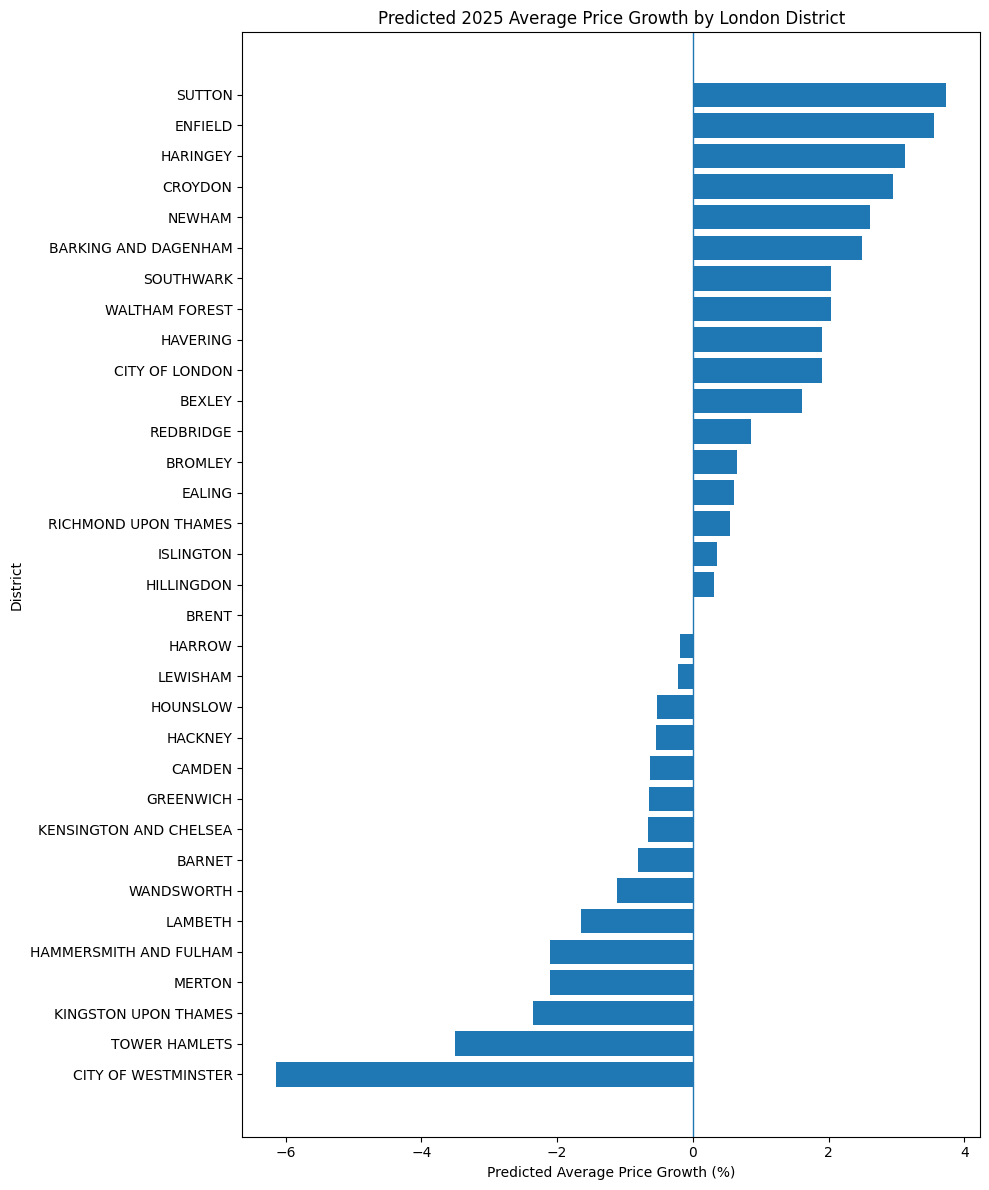

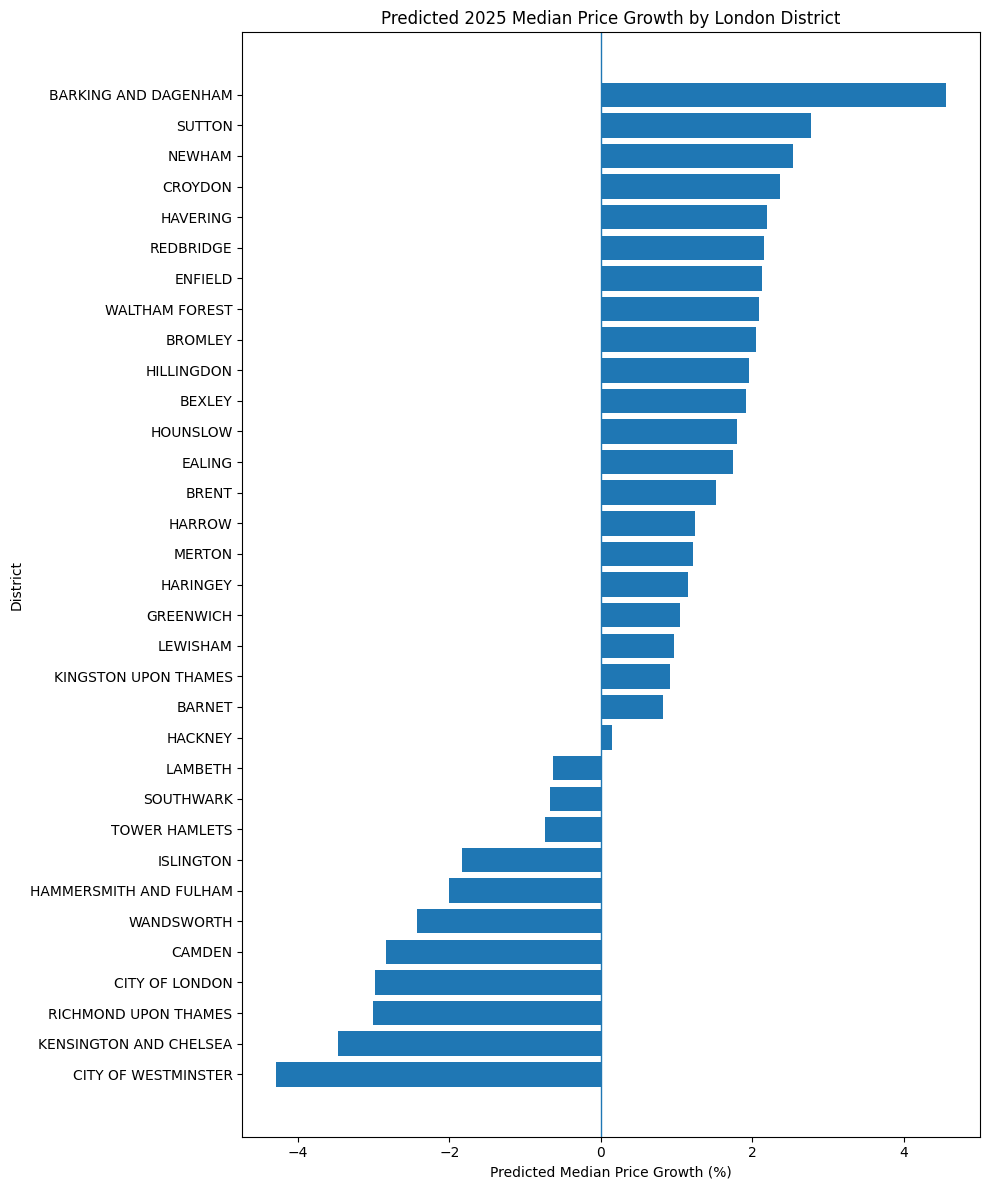


=== FORECAST VISUALISATIONS COMPLETE ===


In [66]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Prepare plotting data
# --------------------------------------------------

plot_avg = (
    final_results_2025
    .sort_values("Predicted_Average_Growth_%")
    .copy()
)

plot_median = (
    final_results_2025
    .sort_values("Predicted_Median_Growth_%")
    .copy()
)


# --------------------------------------------------
# 2. Average Price Growth
# --------------------------------------------------

plt.figure(figsize=(10, 12))

plt.barh(
    plot_avg["District"],
    plot_avg["Predicted_Average_Growth_%"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Predicted Average Price Growth (%)")
plt.ylabel("District")
plt.title(
    "Predicted 2025 Average Price Growth by London District"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Median Price Growth
# --------------------------------------------------

plt.figure(figsize=(10, 12))

plt.barh(
    plot_median["District"],
    plot_median["Predicted_Median_Growth_%"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Predicted Median Price Growth (%)")
plt.ylabel("District")
plt.title(
    "Predicted 2025 Median Price Growth by London District"
)

plt.tight_layout()
plt.show()

print("\n=== FORECAST VISUALISATIONS COMPLETE ===")

In [67]:
print("=== DATAFRAMES RELATED TO FINAL RESULTS ===")

for name, value in list(globals().items()):
    if hasattr(value, "shape") and hasattr(value, "columns"):
        print(f"{name:35s} shape={value.shape}")

=== DATAFRAMES RELATED TO FINAL RESULTS ===
df_model                            shape=(264, 15)
missing_by_year                     shape=(8, 10)
missing_pct_by_year                 shape=(8, 10)
check_2024                          shape=(33, 3)
check_2023                          shape=(33, 3)
target_availability                 shape=(6, 2)
comparison_2022_2023                shape=(33, 4)
comparison                          shape=(33, 4)
history                             shape=(165, 4)
backtest_results_df                 shape=(18, 5)
summary                             shape=(6, 2)
historical_df                       shape=(198, 17)
average_growth                      shape=(33, 2)
values_2023                         shape=(33, 2)
estimates_2024                      shape=(33, 8)
imputation_2024                     shape=(33, 2)
remaining_missing                   shape=(8, 2)
train_df                            shape=(132, 15)
validation_df                       shape=(33, 15)
t

In [68]:
print("=== FINAL RESULTS DATAFRAME ===")
print(final_results_display.to_string(index=False))

=== FINAL RESULTS DATAFRAME ===
              District Borough_Code  Year  Predicted_Average_Growth_%  Predicted_Median_Growth_%  Average_Growth_Rank  Median_Growth_Rank  Combined_Rank  Overall_Rank
                SUTTON    E09000029  2024                    3.737449                   2.771750                    1                   2              3             1
  BARKING AND DAGENHAM    E09000002  2024                    2.491461                   4.563967                    6                   1              7             2
                NEWHAM    E09000025  2024                    2.608891                   2.540566                    5                   3              8             3
               CROYDON    E09000008  2024                    2.956131                   2.369978                    4                   4              8             3
               ENFIELD    E09000010  2024                    3.555150                   2.124332                    2                

In [69]:
print("=== FINAL RESULTS DATAFRAME ===")
display(final_results_display)

=== FINAL RESULTS DATAFRAME ===


,District,Borough_Code,Year,Predicted_Average_Growth_%,Predicted_Median_Growth_%,Average_Growth_Rank,Median_Growth_Rank,Combined_Rank,Overall_Rank
0,SUTTON,E09000029,2024,3.737449,2.771750,1,2,3,1
1,BARKING AND DAGENHAM,E09000002,2024,2.491461,4.563967,6,1,7,2
2,NEWHAM,E09000025,2024,2.608891,2.540566,5,3,8,3
3,CROYDON,E09000008,2024,2.956131,2.369978,4,4,8,3
4,ENFIELD,E09000010,2024,3.555150,2.124332,2,7,9,5
5,HAVERING,E09000016,2024,1.898551,2.197368,9,5,14,6
6,WALTHAM FOREST,E09000031,2024,2.032491,2.090407,8,8,16,7
7,REDBRIDGE,E09000026,2024,0.863757,2.159445,12,6,18,8
8,HARINGEY,E09000014,2024,3.128853,1.154066,3,17,20,9
9,BROMLEY,E09000006,2024,0.648941,2.050655,13,9,22,10


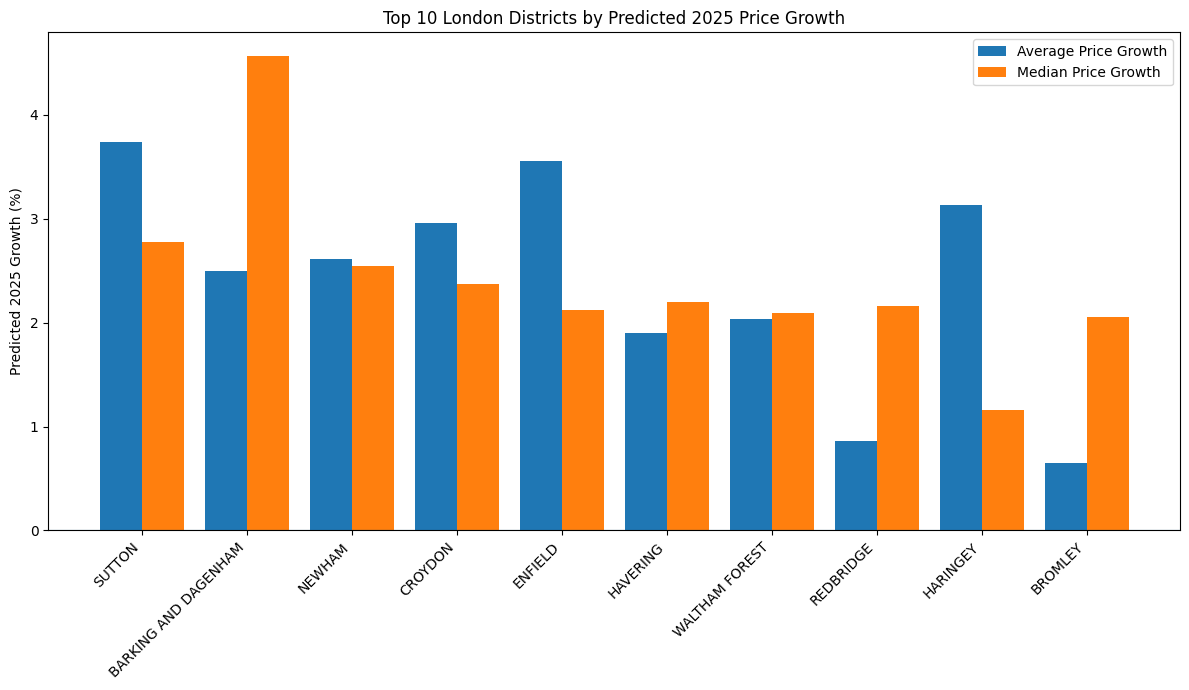

In [70]:
import matplotlib.pyplot as plt

top10 = (
    final_results_display
    .sort_values("Overall_Rank")
    .head(10)
    .copy()
)

plt.figure(figsize=(12, 7))

x = range(len(top10))

plt.bar(
    [i - 0.2 for i in x],
    top10["Predicted_Average_Growth_%"],
    width=0.4,
    label="Average Price Growth"
)

plt.bar(
    [i + 0.2 for i in x],
    top10["Predicted_Median_Growth_%"],
    width=0.4,
    label="Median Price Growth"
)

plt.axhline(0, linewidth=0.8)

plt.xticks(
    x,
    top10["District"],
    rotation=45,
    ha="right"
)

plt.ylabel("Predicted 2025 Growth (%)")
plt.title("Top 10 London Districts by Predicted 2025 Price Growth")
plt.legend()
plt.tight_layout()

plt.show()

In [71]:
print("=== TOP 10 VISUALIZATION DATA ===")

print(
    top10[
        [
            "District",
            "Predicted_Average_Growth_%",
            "Predicted_Median_Growth_%",
            "Overall_Rank"
        ]
    ].to_string(index=False)
)

=== TOP 10 VISUALIZATION DATA ===
            District  Predicted_Average_Growth_%  Predicted_Median_Growth_%  Overall_Rank
              SUTTON                    3.737449                   2.771750             1
BARKING AND DAGENHAM                    2.491461                   4.563967             2
              NEWHAM                    2.608891                   2.540566             3
             CROYDON                    2.956131                   2.369978             3
             ENFIELD                    3.555150                   2.124332             5
            HAVERING                    1.898551                   2.197368             6
      WALTHAM FOREST                    2.032491                   2.090407             7
           REDBRIDGE                    0.863757                   2.159445             8
            HARINGEY                    3.128853                   1.154066             9
             BROMLEY                    0.648941                  

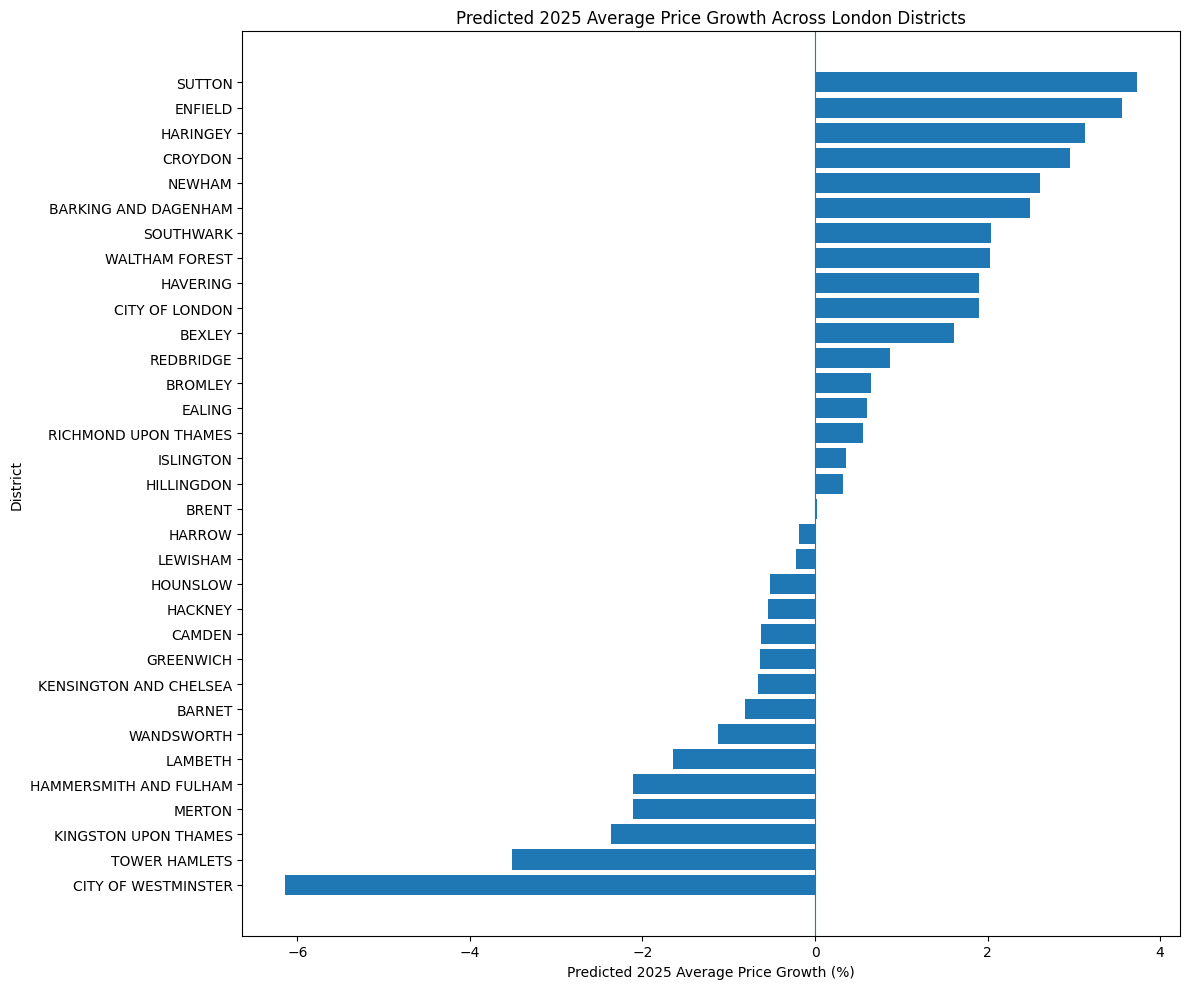

In [72]:
import matplotlib.pyplot as plt

plot_data = final_results_display.sort_values(
    "Predicted_Average_Growth_%"
).copy()

plt.figure(figsize=(12, 10))

plt.barh(
    plot_data["District"],
    plot_data["Predicted_Average_Growth_%"]
)

plt.axvline(0, linewidth=0.8)

plt.xlabel("Predicted 2025 Average Price Growth (%)")
plt.ylabel("District")
plt.title("Predicted 2025 Average Price Growth Across London Districts")

plt.tight_layout()
plt.show()

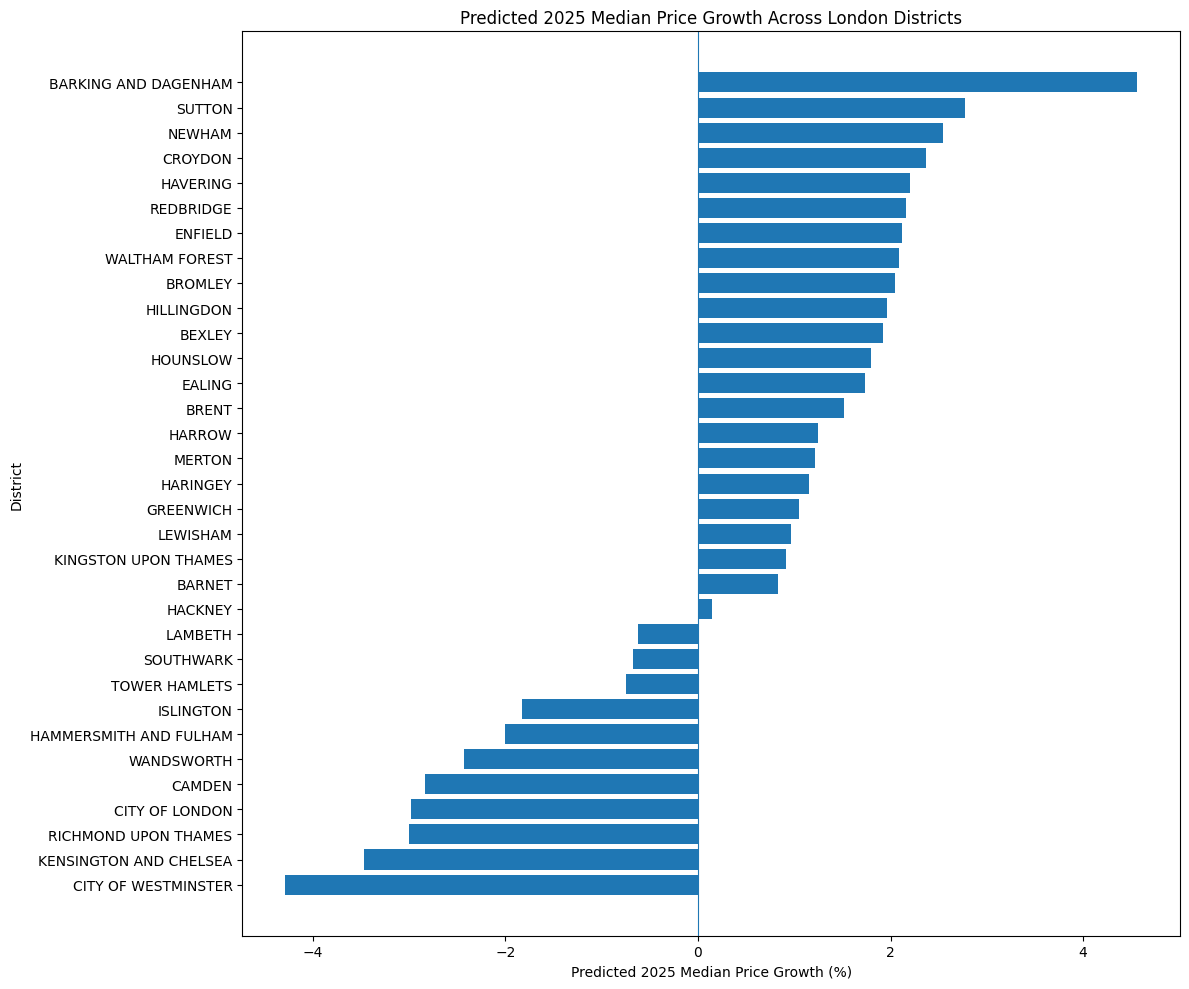

In [73]:
import matplotlib.pyplot as plt

plot_data = final_results_display.sort_values(
    "Predicted_Median_Growth_%"
).copy()

plt.figure(figsize=(12, 10))

plt.barh(
    plot_data["District"],
    plot_data["Predicted_Median_Growth_%"]
)

plt.axvline(0, linewidth=0.8)

plt.xlabel("Predicted 2025 Median Price Growth (%)")
plt.ylabel("District")
plt.title("Predicted 2025 Median Price Growth Across London Districts")

plt.tight_layout()
plt.show()

In [74]:
print("=== SENSITIVITY-RELATED DATAFRAMES ===")

dataframes = []

for name, value in list(globals().items()):
    if hasattr(value, "shape") and hasattr(value, "columns"):
        if "sens" in name.lower():
            dataframes.append(
                (name, value.shape, list(value.columns))
            )

for name, shape, columns in dataframes:
    print(f"\nDataFrame: {name}")
    print(f"Shape: {shape}")
    print(f"Columns: {columns}")

=== SENSITIVITY-RELATED DATAFRAMES ===

DataFrame: sensitivity_df
Shape: (165, 9)
Columns: ['Scenario', 'Shock', 'District', 'Predicted_Average_Price_Growth', 'Predicted_Median_Price_Growth', 'Average_Growth_Change', 'Median_Growth_Change', 'Average_Positive', 'Median_Positive']

DataFrame: sensitivity_summary
Shape: (5, 8)
Columns: [('Predicted_Average_Price_Growth', 'mean'), ('Predicted_Average_Price_Growth', 'std'), ('Predicted_Average_Price_Growth', 'min'), ('Predicted_Average_Price_Growth', 'max'), ('Predicted_Median_Price_Growth', 'mean'), ('Predicted_Median_Price_Growth', 'std'), ('Predicted_Median_Price_Growth', 'min'), ('Predicted_Median_Price_Growth', 'max')]

DataFrame: sensitivity_decomposition_df
Shape: (495, 8)
Columns: ['Sensitivity_Type', 'Scenario', 'Shock', 'District', 'Predicted_Average_Price_Growth', 'Predicted_Median_Price_Growth', 'Average_Growth_Change', 'Median_Growth_Change']


=== SENSITIVITY PLOT DATA ===
          Predicted_Average_Price_Growth  Predicted_Median_Price_Growth
Scenario                                                               
-10%                            1.332405                       1.571793
-5%                             0.789354                       0.997523
+0%                             0.246302                       0.437287
+5%                            -0.296749                      -0.053535
+10%                           -0.839801                      -0.427588


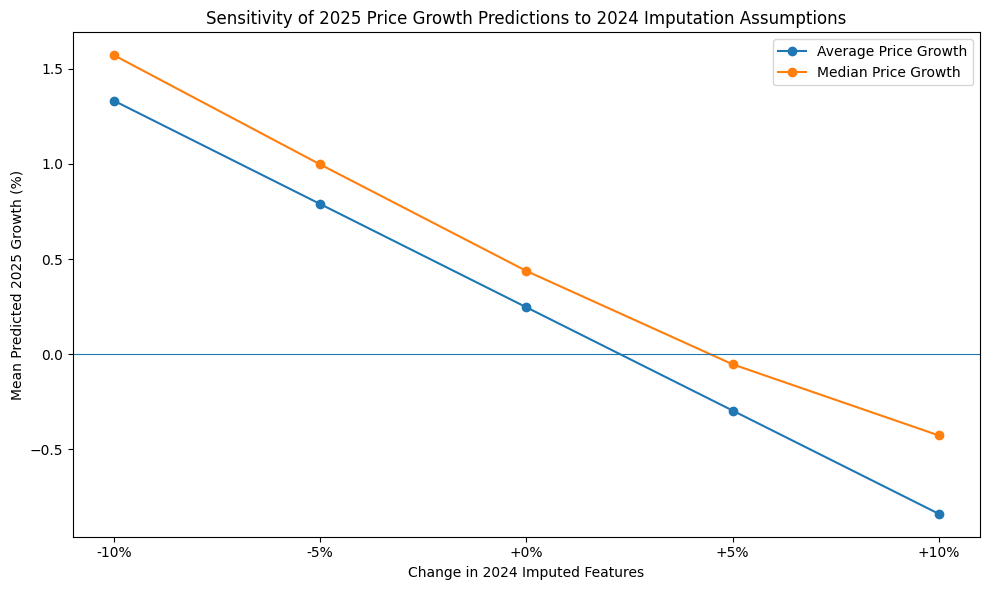

In [75]:
import matplotlib.pyplot as plt

# ==============================================
# 2024 IMPUTATION SENSITIVITY
# Overall London Prediction Impact
# ==============================================

sensitivity_plot = (
    sensitivity_df
    .groupby("Scenario")[
        [
            "Predicted_Average_Price_Growth",
            "Predicted_Median_Price_Growth"
        ]
    ]
    .mean()
    .reindex(["-10%", "-5%", "+0%", "+5%", "+10%"])
)

sensitivity_plot = sensitivity_plot * 100

print("=== SENSITIVITY PLOT DATA ===")
print(sensitivity_plot)

plt.figure(figsize=(10, 6))

plt.plot(
    sensitivity_plot.index,
    sensitivity_plot["Predicted_Average_Price_Growth"],
    marker="o",
    label="Average Price Growth"
)

plt.plot(
    sensitivity_plot.index,
    sensitivity_plot["Predicted_Median_Price_Growth"],
    marker="o",
    label="Median Price Growth"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Change in 2024 Imputed Features")
plt.ylabel("Mean Predicted 2025 Growth (%)")

plt.title(
    "Sensitivity of 2025 Price Growth Predictions "
    "to 2024 Imputation Assumptions"
)

plt.legend()
plt.tight_layout()

plt.show()

=== TOP 10 FINAL RESULTS VISUALIZATION ===

=== TOP 10 VISUALIZATION DATA ===
            District  Predicted_Average_Growth_%  Predicted_Median_Growth_%  Overall_Rank
              SUTTON                    3.737449                   2.771750             1
BARKING AND DAGENHAM                    2.491461                   4.563967             2
              NEWHAM                    2.608891                   2.540566             3
             CROYDON                    2.956131                   2.369978             3
             ENFIELD                    3.555150                   2.124332             5
            HAVERING                    1.898551                   2.197368             6
      WALTHAM FOREST                    2.032491                   2.090407             7
           REDBRIDGE                    0.863757                   2.159445             8
            HARINGEY                    3.128853                   1.154066             9
             BROMLEY  

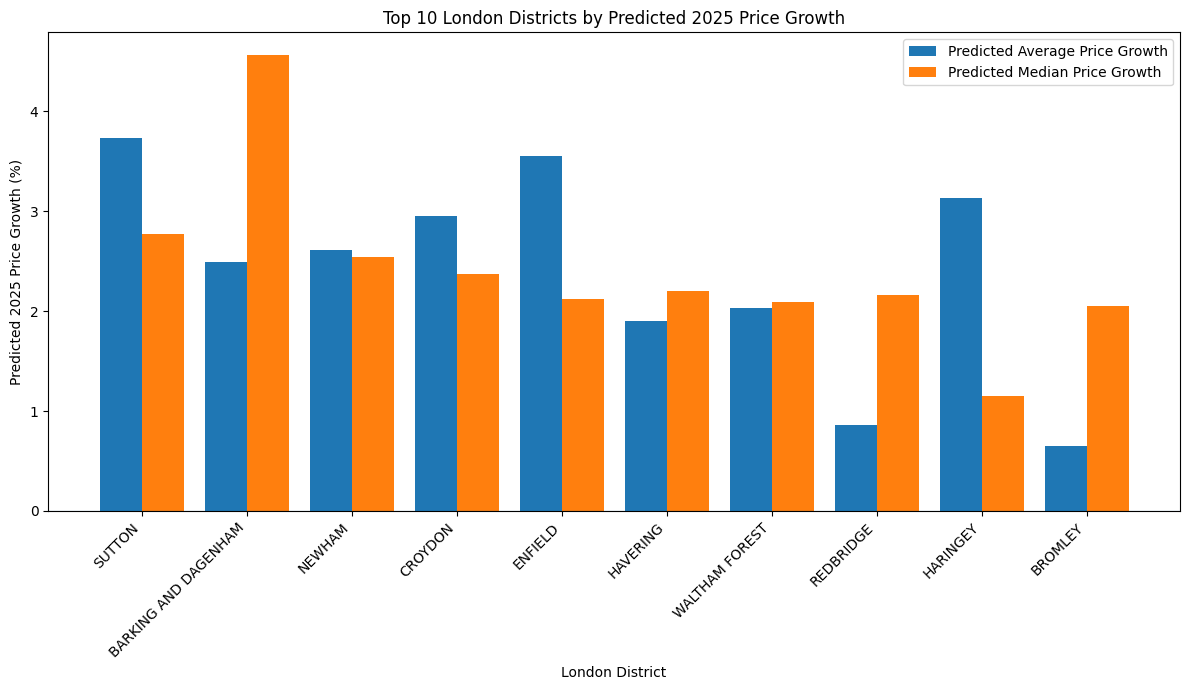


=== TOP 10 VISUALIZATION COMPLETE ===


In [76]:
import matplotlib.pyplot as plt

# ============================================================
# FINAL 2025 RESULTS — TOP 10 DISTRICTS
# ============================================================

print("=== TOP 10 FINAL RESULTS VISUALIZATION ===")

# ------------------------------------------------------------
# 1. Prepare Top 10 data
# ------------------------------------------------------------

top10_final = (
    final_results_display
    .sort_values("Overall_Rank")
    .head(10)
    .copy()
)

print("\n=== TOP 10 VISUALIZATION DATA ===")
print(
    top10_final[
        [
            "District",
            "Predicted_Average_Growth_%",
            "Predicted_Median_Growth_%",
            "Overall_Rank"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 2. Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

x = range(len(top10_final))

plt.bar(
    [i - 0.2 for i in x],
    top10_final["Predicted_Average_Growth_%"],
    width=0.4,
    label="Predicted Average Price Growth"
)

plt.bar(
    [i + 0.2 for i in x],
    top10_final["Predicted_Median_Growth_%"],
    width=0.4,
    label="Predicted Median Price Growth"
)

# ------------------------------------------------------------
# 3. Formatting
# ------------------------------------------------------------

plt.axhline(0, linewidth=0.8)

plt.xticks(
    list(x),
    top10_final["District"],
    rotation=45,
    ha="right"
)

plt.xlabel("London District")
plt.ylabel("Predicted 2025 Price Growth (%)")

plt.title(
    "Top 10 London Districts by Predicted 2025 Price Growth"
)

plt.legend()

plt.tight_layout()

plt.show()

print("\n=== TOP 10 VISUALIZATION COMPLETE ===")

## Bottom 10 Districts by Predicted 2025 Price Growth

=== BOTTOM 10 FINAL RESULTS VISUALIZATION ===

=== BOTTOM 10 VISUALIZATION DATA ===
              District  Predicted_Average_Growth_%  Predicted_Median_Growth_%  Overall_Rank
   CITY OF WESTMINSTER                   -6.145736                  -4.289972            33
KENSINGTON AND CHELSEA                   -0.662797                  -3.465613            31
         TOWER HAMLETS                   -3.507837                  -0.742632            31
HAMMERSMITH AND FULHAM                   -2.108323                  -2.003906            30
            WANDSWORTH                   -1.124038                  -2.429390            29
                CAMDEN                   -0.625452                  -2.831342            28
  KINGSTON UPON THAMES                   -2.362592                   0.913643            26
               LAMBETH                   -1.641988                  -0.624349            26
                BARNET                   -0.807972                   0.827062           

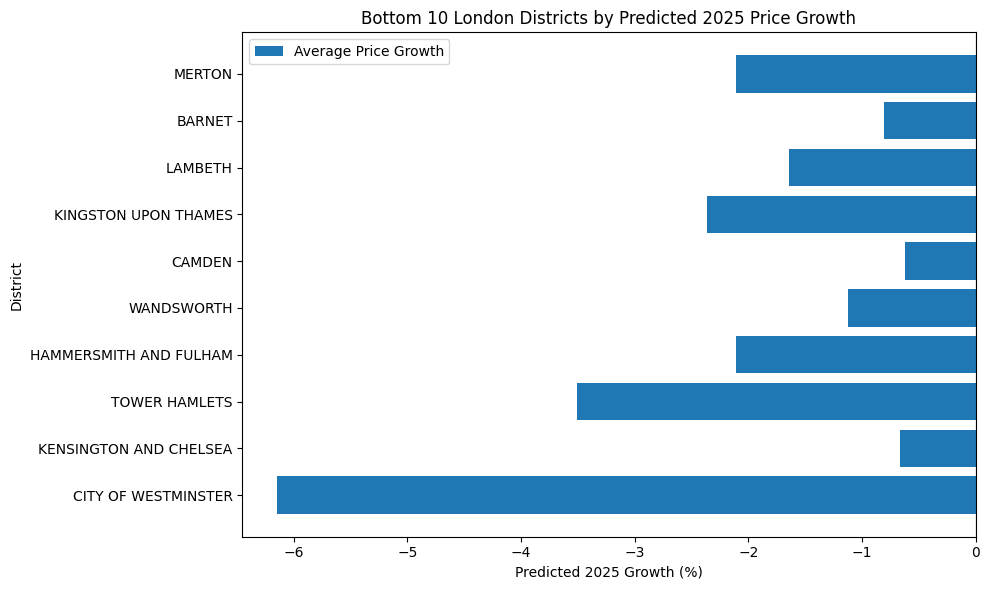


=== BOTTOM 10 VISUALIZATION COMPLETE ===


In [77]:
print("=== BOTTOM 10 FINAL RESULTS VISUALIZATION ===")

# --------------------------------------------------
# 1. Select Bottom 10 districts
# --------------------------------------------------

bottom_10 = (
    final_results_2025
    .sort_values("Overall_Rank", ascending=False)
    .head(10)
    .copy()
)

# --------------------------------------------------
# 2. Select visualization columns
# --------------------------------------------------

bottom_10_visualization = bottom_10[
    [
        "District",
        "Predicted_Average_Growth_%",
        "Predicted_Median_Growth_%",
        "Overall_Rank"
    ]
].copy()

# --------------------------------------------------
# 3. Sort from weakest to strongest
# --------------------------------------------------

bottom_10_visualization = (
    bottom_10_visualization
    .sort_values("Overall_Rank", ascending=False)
)

# --------------------------------------------------
# 4. Display data
# --------------------------------------------------

print("\n=== BOTTOM 10 VISUALIZATION DATA ===")
print(
    bottom_10_visualization.to_string(index=False)
)

# --------------------------------------------------
# 5. Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    bottom_10_visualization["District"],
    bottom_10_visualization["Predicted_Average_Growth_%"],
    label="Average Price Growth"
)

plt.xlabel("Predicted 2025 Growth (%)")
plt.ylabel("District")

plt.title(
    "Bottom 10 London Districts by Predicted 2025 Price Growth"
)

plt.axvline(0, linewidth=0.8)

plt.legend()
plt.tight_layout()
plt.show()

print("\n=== BOTTOM 10 VISUALIZATION COMPLETE ===")

=== TOP 10 vs BOTTOM 10 VISUALIZATION DATA ===
              District  Predicted_Average_Growth_%  Predicted_Median_Growth_%  Overall_Rank     Group
                SUTTON                    3.737449                   2.771750             1    Top 10
  BARKING AND DAGENHAM                    2.491461                   4.563967             2    Top 10
                NEWHAM                    2.608891                   2.540566             3    Top 10
               CROYDON                    2.956131                   2.369978             3    Top 10
               ENFIELD                    3.555150                   2.124332             5    Top 10
              HAVERING                    1.898551                   2.197368             6    Top 10
        WALTHAM FOREST                    2.032491                   2.090407             7    Top 10
             REDBRIDGE                    0.863757                   2.159445             8    Top 10
              HARINGEY             

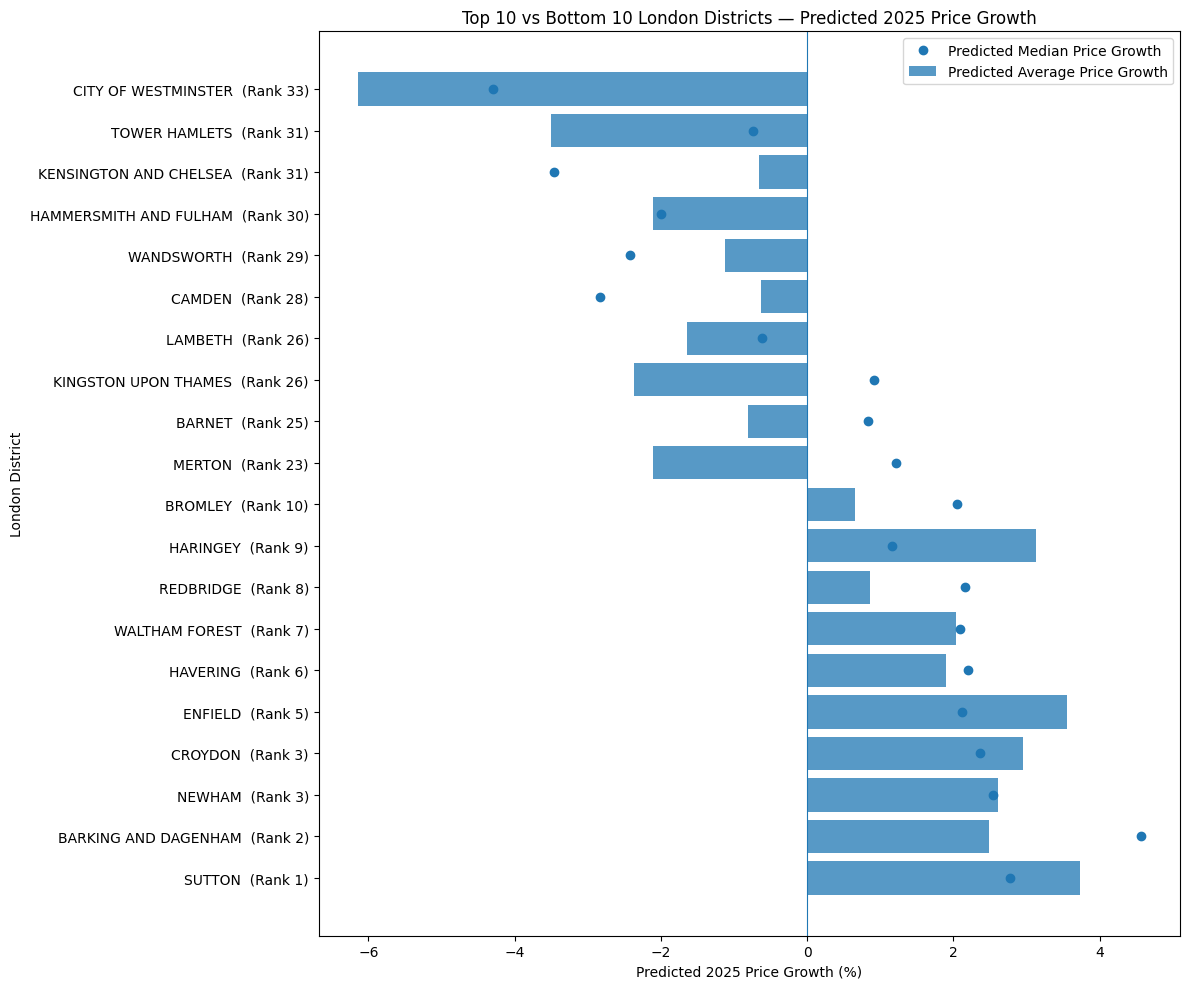


=== TOP vs BOTTOM COMPARISON COMPLETE ===


In [78]:
# ============================================================
# TOP 10 vs BOTTOM 10 — FINAL COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. Prepare Top 10
# ------------------------------------------------------------

top_10 = (
    final_results_display
    .sort_values("Overall_Rank")
    .head(10)
    .copy()
)

top_10["Group"] = "Top 10"


# ------------------------------------------------------------
# 2. Prepare Bottom 10
# ------------------------------------------------------------

bottom_10 = (
    final_results_display
    .sort_values("Overall_Rank", ascending=False)
    .head(10)
    .sort_values("Overall_Rank")
    .copy()
)

bottom_10["Group"] = "Bottom 10"


# ------------------------------------------------------------
# 3. Combine
# ------------------------------------------------------------

comparison_visualization = pd.concat(
    [top_10, bottom_10],
    ignore_index=True
)


# ------------------------------------------------------------
# 4. Display data used in visualization
# ------------------------------------------------------------

print("=== TOP 10 vs BOTTOM 10 VISUALIZATION DATA ===")

print(
    comparison_visualization[
        [
            "District",
            "Predicted_Average_Growth_%",
            "Predicted_Median_Growth_%",
            "Overall_Rank",
            "Group"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 5. Create plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 10))

y_positions = range(len(comparison_visualization))

plt.barh(
    list(y_positions),
    comparison_visualization["Predicted_Average_Growth_%"],
    alpha=0.75,
    label="Predicted Average Price Growth"
)

plt.plot(
    comparison_visualization["Predicted_Median_Growth_%"],
    list(y_positions),
    "o",
    label="Predicted Median Price Growth"
)


# ------------------------------------------------------------
# 6. Reference line at zero
# ------------------------------------------------------------

plt.axvline(
    0,
    linewidth=0.8
)


# ------------------------------------------------------------
# 7. District labels
# ------------------------------------------------------------

plt.yticks(
    list(y_positions),
    [
        f"{district}  (Rank {rank})"
        for district, rank in zip(
            comparison_visualization["District"],
            comparison_visualization["Overall_Rank"]
        )
    ]
)


# ------------------------------------------------------------
# 8. Labels and title
# ------------------------------------------------------------

plt.xlabel(
    "Predicted 2025 Price Growth (%)"
)

plt.ylabel(
    "London District"
)

plt.title(
    "Top 10 vs Bottom 10 London Districts — "
    "Predicted 2025 Price Growth"
)

plt.legend()

plt.tight_layout()

plt.show()


print("\n=== TOP vs BOTTOM COMPARISON COMPLETE ===")

# Final Project Summary & Model Card

## 1. Project Objective

This project develops a district-level machine learning framework to estimate **2025 house-price growth across the 33 London boroughs/districts**.

Two targets were modelled separately:

* Average Price Growth
* Median Price Growth

The objective was not only to generate predictions, but to develop a **time-aware and robust modelling workflow** that accounts for temporal validation, missing 2024 socioeconomic data, model selection, model stability, sensitivity to imputation assumptions, and district-level prediction uncertainty.

Importantly, **2025 observations were not used as training or validation data**. The 2025 outputs represent model-generated predictions.

---

## 2. Data & Features

The final historical modelling dataset contains:

* **198 observations**
* **33 London districts**
* **6 historical years: 2018–2023**
* **10 predictors**
* **2 prediction targets**

The final predictors are:

1. Transactions
2. Average Price
3. Median Price
4. Min Price
5. Max Price
6. Average Price Growth
7. Median Price Growth
8. Number of Individuals
9. Median Income
10. AvPTAI2015

The final training dataset contained no missing predictor or target values at the modelling stage.

The 2025 prediction stage uses **2024 feature values as inputs** to estimate 2025 price growth.

---

## 3. 2024 Socioeconomic Data Imputation

Some socioeconomic variables required for the 2025 prediction inputs were unavailable for 2024 and therefore had to be estimated.

The two affected predictors examined in the imputation sensitivity analysis were:

* Number of Individuals
* Median Income

Rather than treating these estimates as fixed and unquestionable inputs, the project explicitly evaluated the potential effect of the imputation assumptions.

Historical backtesting was performed for the available years **2021–2023**, comparing alternative imputation strategies including:

* Carry Forward
* Average Growth Method
* Recent Growth Method

This provided an empirical basis for assessing the quality of the imputation approaches before applying them to 2024.

The selected 2024 imputation values were then used as model inputs for the 2025 prediction stage.

---

## 4. Model Validation & Selection Strategy

Model evaluation used a **time-aware validation framework** rather than a random train/test split.

This was chosen because the task is fundamentally temporal: historical information should be used to predict future observations without allowing future data to influence earlier model training.

The workflow incorporated:

* Expanding time-series validation
* A separate holdout evaluation
* Comparison of multiple candidate models
* Historical-mean baseline comparison
* Target-specific model selection
* Model stability considerations

Model selection was therefore not based exclusively on a single performance metric.

---

## 5. Final Models

### Target: Average Price Growth

**Final Model: Ridge Regression**

Configuration:

* Alpha: **100**
* StandardScaler preprocessing
* Ridge regression

Holdout performance:

* **MAE: 0.068535**
* **RMSE: 0.082127**

For comparison:

* Historical Mean MAE: 0.074292
* Random Forest MAE: 0.095018

Ridge therefore provided the strongest holdout performance among the evaluated models for Average Price Growth.

---

### Target: Median Price Growth

**Final Model: Random Forest Regression**

Configuration:

* n_estimators: **300**
* max_depth: **4**
* min_samples_leaf: **8**
* random_state: **42**

Holdout performance:

* **MAE: 0.034584**
* **RMSE: 0.048796**

For comparison:

* Historical Mean MAE: **0.033434**
* Ridge MAE: 0.042049

The Historical Mean baseline achieved a slightly lower holdout MAE than the Random Forest. Therefore, the Random Forest should **not** be described as the model with the lowest holdout error.

Instead, the Random Forest was retained as the final Median Price Growth model based on the broader model-selection process, which considered predictive performance together with temporal validation and model behaviour rather than relying exclusively on the single holdout MAE.

This distinction is important for maintaining an accurate and transparent interpretation of the modelling results.

---

## 6. Final Training & 2025 Prediction Framework

After model selection, the final models were retrained using the available historical training data through **2023**, with the 2024 feature values subsequently used as the prediction inputs for 2025.

The final prediction input contains:

* **33 London districts**
* **10 predictors**
* Feature year: **2024**

The prediction pipeline passed checks for:

* Feature dimensionality
* Feature availability
* Feature ordering
* Missing values
* District coverage
* Duplicate districts

No 2025 actual observations were used in generating the predictions.

Therefore, the reported 2025 results should be interpreted as **out-of-sample model estimates**, not observed 2025 market outcomes.

---

## 7. Final 2025 Prediction Results

The final model produces substantial variation in predicted price growth across London districts.

### Highest-ranked districts

The top overall predicted districts are:

1. Sutton
2. Barking and Dagenham
3. Newham
4. Croydon
5. Enfield
6. Havering
7. Waltham Forest
8. Redbridge
9. Haringey
10. Bromley

### Sutton

Sutton ranks first overall with predicted:

* Average Price Growth: **+3.74%**
* Median Price Growth: **+2.77%**

### Barking and Dagenham

Barking and Dagenham has the highest predicted Median Price Growth:

* Median Price Growth: **+4.56%**

---

## 8. Lowest-Ranked Districts

The lowest overall-ranked districts include:

* City of Westminster
* Kensington and Chelsea
* Tower Hamlets
* Hammersmith and Fulham
* Wandsworth

### City of Westminster

City of Westminster has the lowest predicted values across both targets:

* Average Price Growth: **−6.15%**
* Median Price Growth: **−4.29%**

The model therefore predicts a wide range of potential outcomes across London rather than a uniform city-wide growth pattern.

---

## 9. Average vs Median Price Growth

An important finding is that Average Price Growth and Median Price Growth do not always produce the same district-level picture.

For example:

### Kingston upon Thames

* Average Growth: **−2.36%**
* Median Growth: **+0.91%**

### Southwark

* Average Growth: **+2.04%**
* Median Growth: **−0.68%**

These differences demonstrate why analysing both measures provides a more nuanced view of district-level housing-market dynamics than relying on a single price-growth metric.

---

## 10. 2024 Imputation Sensitivity Analysis

The sensitivity analysis evaluated the effect of perturbing the imputed 2024 socioeconomic variables by:

* −10%
* −5%
* 0%
* +5%
* +10%

When **Number of Individuals and Median Income were perturbed together**, the mean predicted Average Price Growth across the 33 districts changed approximately as follows:

| Scenario | Mean Predicted Average Growth |
| -------- | ----------------------------: |
| −10%     |                        +1.33% |
| −5%      |                        +0.79% |
| 0%       |                        +0.25% |
| +5%      |                        −0.30% |
| +10%     |                        −0.84% |

The sensitivity analysis therefore shows that the 2025 predictions are **meaningfully affected by the assumptions used for the imputed 2024 socioeconomic variables**.

The direction of prediction remained stable across:

* **17 of 33 districts** for Average Price Growth
* **21 of 33 districts** for Median Price Growth

Consequently, the final district rankings should be interpreted as **model-based estimates subject to input uncertainty**, rather than deterministic forecasts.

---

## 11. Imputation Backtesting

The imputation component was also evaluated using historical backtesting for 2021–2023.

For example, Median Income backtesting showed that the Average Growth Method produced the lowest MAE among the tested approaches in both 2022 and 2023:

* 2022: MAE = **1012.97**
* 2023: MAE = **1212.93**

For Number of Individuals, the best-performing method varied by year:

* 2021: Carry Forward
* 2022: Recent Growth Method
* 2023: Recent Growth Method

This variation highlights that imputation performance is itself time-dependent and should not be interpreted as universally optimal across all historical periods.

The imputation analysis therefore provides supporting evidence for the chosen approach while also demonstrating its uncertainty.

---

## 12. Business Interpretation

The results suggest that London should not be treated as a homogeneous housing market.

The model predicts substantial district-level heterogeneity, with stronger predicted growth in several outer and eastern districts and weaker predicted growth in a number of high-value central districts.

The divergence between Average and Median Price Growth further suggests that district-level market dynamics can differ depending on the price statistic being analysed.

Potential applications include:

* Property investment screening
* District prioritisation
* Market segmentation
* Location-based strategy
* Housing-market monitoring
* Scenario analysis

However, these applications should use the predictions as **decision-support information**, rather than as guaranteed investment outcomes.

---

## 13. Robustness & Limitations

Several limitations should be considered when interpreting the results.

### 1. 2024 socioeconomic imputation

Some 2024 socioeconomic inputs required estimation. Sensitivity analysis demonstrates that changes in these assumptions can materially affect the predictions.

### 2. Limited historical sample

The modelling dataset contains 198 district-year observations covering six historical years. This provides a structured panel but remains relatively limited for a high-dimensional forecasting problem.

### 3. Historical relationships may change

The models learn relationships from historical data and cannot fully anticipate structural breaks, unexpected economic shocks, policy changes, interest-rate movements, or other unprecedented events.

### 4. Model estimates are not observed outcomes

The 2025 values are predictions generated from the model. They are not actual 2025 market observations.

### 5. Rankings contain uncertainty

Because the predictions are sensitive to input assumptions, particularly the imputed 2024 socioeconomic variables, small changes in assumptions can affect district-level rankings.

### 6. Baseline competition

For Median Price Growth, the Historical Mean baseline achieved a slightly lower holdout MAE than the selected Random Forest. This means the final model should not be presented as universally superior to the simplest baseline.

---

## 14. Final Conclusion

This project developed a district-level machine learning framework for estimating 2025 house-price growth across the 33 London districts.

The workflow combines:

* Historical panel data
* Time-aware validation
* Historical baseline comparison
* Target-specific model selection
* Ridge Regression
* Random Forest Regression
* Historical imputation backtesting
* 2024 socioeconomic imputation
* Imputation sensitivity analysis
* Full historical model retraining
* District-level 2025 prediction
* Ranking and visualisation
* Business-oriented interpretation

The key finding is that the model predicts **substantial heterogeneity in potential 2025 price growth across London districts**.

At the same time, the sensitivity analysis demonstrates that the predictions are influenced by assumptions surrounding missing 2024 socioeconomic information.

The project therefore provides more than a single set of predictions: it provides a **transparent, time-aware modelling framework that explicitly evaluates prediction robustness and uncertainty**.

The results should ultimately be interpreted as **scenario-based machine-learning estimates rather than guaranteed forecasts of future house-price performance**.

---

## 15. Final QA Status

The completed notebook passed the final project quality-assurance checks covering:

* Dataset integrity
* District coverage
* Temporal integrity
* Prediction-input integrity
* Model-object integrity
* Hyperparameter consistency
* Prediction completeness
* Ranking integrity
* Sensitivity-analysis structure
* Imputation backtesting structure

**Overall Project QA Status: PASS — Ready for Final Documentation and Portfolio Presentation.**


In [81]:

# ============================================================
# FINAL PROJECT QA — SCIENTIFIC & CONSISTENCY CHECK
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("FINAL PROJECT QA — SCIENTIFIC & CONSISTENCY CHECK")
print("=" * 70)


# ============================================================
# 1. REQUIRED OBJECTS
# ============================================================

print("\n[1] OBJECT AVAILABILITY CHECK")

required_objects = [
    "final_results_2025",
    "final_results_display",
    "predictions_2025",
    "X_2025",
    "final_ridge_model",
    "final_rf_model",
    "sensitivity_df",
    "sensitivity_decomposition_df"
]

for name in required_objects:
    exists = name in globals()

    if exists:
        status = "PASS"
    else:
        status = "MISSING"

    print(f"{name:<35} : {status}")


# ============================================================
# 2. FINAL RESULTS DATA INTEGRITY
# ============================================================

print("\n[2] FINAL RESULTS DATA INTEGRITY")

if "final_results_2025" in globals():

    results = final_results_2025.copy()

    print("Shape:", results.shape)

    # Number of districts
    n_districts = len(results)

    if n_districts == 33:
        status = "PASS"
    else:
        status = "FAIL"

    print(f"District count: {n_districts} -> {status}")

    # Required columns
    required_result_columns = [
        "District",
        "Borough_Code",
        "Year",
        "Predicted_Average_Growth_%",
        "Predicted_Median_Growth_%",
        "Average_Growth_Rank",
        "Median_Growth_Rank",
        "Combined_Rank",
        "Overall_Rank"
    ]

    missing_columns = [
        c for c in required_result_columns
        if c not in results.columns
    ]

    if len(missing_columns) == 0:
        print("Required columns: PASS")
    else:
        print("Required columns: FAIL")
        print("Missing:", missing_columns)

    # Duplicate districts
    duplicate_districts = results["District"].duplicated().sum()

    if duplicate_districts == 0:
        status = "PASS"
    else:
        status = "FAIL"

    print(
        f"Duplicate districts: {duplicate_districts} -> {status}"
    )

    # Missing predictions
    prediction_columns = [
        "Predicted_Average_Growth_%",
        "Predicted_Median_Growth_%"
    ]

    missing_predictions = (
        results[prediction_columns]
        .isna()
        .sum()
        .sum()
    )

    if missing_predictions == 0:
        status = "PASS"
    else:
        status = "FAIL"

    print(
        f"Missing predictions: {missing_predictions} -> {status}"
    )


# ============================================================
# 3. TEMPORAL INTEGRITY
# ============================================================

print("\n[3] TEMPORAL INTEGRITY CHECK")

if "final_results_2025" in globals():

    result_years = results["Year"].unique()

    print("Prediction feature year(s):", result_years)

    if set(result_years) == {2024}:
        print("Prediction input year = 2024: PASS")
    else:
        print("Prediction input year = 2024: CHECK")

    print(
        "Interpretation: Year=2024 represents the feature/input "
        "year used to predict 2025."
    )


# ============================================================
# 4. FINAL PREDICTOR CHECK
# ============================================================

print("\n[4] FINAL PREDICTOR CHECK")

expected_predictors = [
    "Transactions",
    "Average_Price",
    "Median_Price",
    "Min_Price",
    "Max_Price",
    "Average_Price_Growth",
    "Median_Price_Growth",
    "Number_of_Individuals",
    "Median_Income",
    "AvPTAI2015"
]

if "X_2025" in globals():

    actual_predictors = list(X_2025.columns)

    print("Expected predictor count:", len(expected_predictors))
    print("Actual predictor count:", len(actual_predictors))

    if len(actual_predictors) == len(expected_predictors):
        print("Predictor count: PASS")
    else:
        print("Predictor count: FAIL")

    if actual_predictors == expected_predictors:
        print("Predictor order: PASS")
    else:
        print("Predictor order: CHECK")
        print("Expected:", expected_predictors)
        print("Actual:", actual_predictors)

    missing_predictor_values = X_2025.isna().sum().sum()

    if missing_predictor_values == 0:
        print("Missing predictor values: PASS")
    else:
        print(
            "Missing predictor values:",
            missing_predictor_values
        )


# ============================================================
# 5. FINAL MODEL CONFIGURATION
# ============================================================

print("\n[5] FINAL MODEL CONFIGURATION CHECK")

if "final_ridge_model" in globals():

    print("\nFinal Ridge model:")
    print(type(final_ridge_model))

    if hasattr(final_ridge_model, "named_steps"):

        print(
            "Pipeline steps:",
            list(final_ridge_model.named_steps.keys())
        )

        if "ridge" in final_ridge_model.named_steps:

            ridge_model = final_ridge_model.named_steps["ridge"]

            print("Ridge alpha:", ridge_model.alpha)

            if ridge_model.alpha == 100:
                print("Ridge alpha = 100: PASS")
            else:
                print("Ridge alpha = 100: CHECK")


if "final_rf_model" in globals():

    print("\nFinal Random Forest model:")
    print(type(final_rf_model))

    print("n_estimators:", final_rf_model.n_estimators)
    print("max_depth:", final_rf_model.max_depth)
    print("min_samples_leaf:", final_rf_model.min_samples_leaf)
    print("random_state:", final_rf_model.random_state)

    rf_config_pass = (
        final_rf_model.n_estimators == 300
        and final_rf_model.max_depth == 4
        and final_rf_model.min_samples_leaf == 8
        and final_rf_model.random_state == 42
    )

    if rf_config_pass:
        print("Random Forest configuration: PASS")
    else:
        print("Random Forest configuration: FAIL")


# ============================================================
# 6. PREDICTION DIMENSIONS
# ============================================================

print("\n[6] PREDICTION DIMENSION CHECK")

if "X_2025" in globals():

    actual_rows = len(X_2025)

    if actual_rows == 33:
        print(f"X_2025 rows: {actual_rows} -> PASS")
    else:
        print(f"X_2025 rows: {actual_rows} -> FAIL")

if "final_results_2025" in globals():

    prediction_rows = len(final_results_2025)

    if prediction_rows == 33:
        print(f"Final prediction rows: {prediction_rows} -> PASS")
    else:
        print(
            f"Final prediction rows: {prediction_rows} -> FAIL"
        )


# ============================================================
# 7. RANKING INTEGRITY
# ============================================================

print("\n[7] RANKING INTEGRITY CHECK")

if "final_results_2025" in globals():

    ranking_columns = [
        "Average_Growth_Rank",
        "Median_Growth_Rank",
        "Combined_Rank",
        "Overall_Rank"
    ]

    for col in ranking_columns:

        if col not in results.columns:
            print(f"{col}: MISSING")
            continue

        missing_rank = results[col].isna().sum()

        if missing_rank == 0:
            status = "PASS"
        else:
            status = "FAIL"

        print(
            f"{col} missing values: "
            f"{missing_rank} -> {status}"
        )

    min_overall_rank = results["Overall_Rank"].min()
    max_overall_rank = results["Overall_Rank"].max()

    if min_overall_rank == 1:
        print("Minimum Overall Rank = 1: PASS")
    else:
        print(
            f"Minimum Overall Rank = {min_overall_rank}: CHECK"
        )

    if max_overall_rank == 33:
        print("Maximum Overall Rank = 33: PASS")
    else:
        print(
            f"Maximum Overall Rank = {max_overall_rank}: CHECK"
        )


# ============================================================
# 8. TOP / BOTTOM RANKING
# ============================================================

print("\n[8] TOP / BOTTOM RANKING CHECK")

if "final_results_2025" in globals():

    top10 = (
        results
        .sort_values("Overall_Rank")
        .head(10)
        ["District"]
        .tolist()
    )

    bottom10 = (
        results
        .sort_values("Overall_Rank")
        .tail(10)
        ["District"]
        .tolist()
    )

    print("\nTop 10 districts:")
    for i, district in enumerate(top10, 1):
        print(f"{i:>2}. {district}")

    print("\nBottom 10 districts:")
    for i, district in enumerate(bottom10, 1):
        print(f"{i:>2}. {district}")


# ============================================================
# 9. SENSITIVITY ANALYSIS
# ============================================================

print("\n[9] SENSITIVITY ANALYSIS CHECK")

if "sensitivity_df" in globals():

    sens = sensitivity_df.copy()

    print("Sensitivity dataframe shape:", sens.shape)

    expected_scenarios = {
        "-10%",
        "-5%",
        "+0%",
        "+5%",
        "+10%"
    }

    actual_scenarios = set(
        sens["Scenario"].astype(str).unique()
    )

    print("Actual scenarios:", sorted(actual_scenarios))

    if expected_scenarios.issubset(actual_scenarios):
        print("Required scenarios present: PASS")
    else:
        print("Required scenarios present: FAIL")

    expected_rows = 33 * 5

    print("Expected sensitivity rows:", expected_rows)
    print("Actual sensitivity rows:", len(sens))

    if len(sens) == expected_rows:
        print("Sensitivity row count: PASS")
    else:
        print("Sensitivity row count: CHECK")


# ============================================================
# 10. SENSITIVITY DECOMPOSITION
# ============================================================

print("\n[10] SENSITIVITY DECOMPOSITION CHECK")

if "sensitivity_decomposition_df" in globals():

    decomp = sensitivity_decomposition_df.copy()

    expected_types = {
        "Individuals_only",
        "Income_only",
        "Both"
    }

    actual_types = set(
        decomp["Sensitivity_Type"].astype(str).unique()
    )

    print("Sensitivity types:", actual_types)

    if actual_types == expected_types:
        print("Three-way decomposition: PASS")
    else:
        print("Three-way decomposition: CHECK")

    expected_rows = 33 * 5 * 3

    print("Expected decomposition rows:", expected_rows)
    print("Actual decomposition rows:", len(decomp))

    if len(decomp) == expected_rows:
        print("Decomposition row count: PASS")
    else:
        print("Decomposition row count: CHECK")


# ============================================================
# 11. PREDICTION RANGE
# ============================================================

print("\n[11] PREDICTION RANGE CHECK")

if "final_results_2025" in globals():

    avg_min = results["Predicted_Average_Growth_%"].min()
    avg_max = results["Predicted_Average_Growth_%"].max()

    median_min = results["Predicted_Median_Growth_%"].min()
    median_max = results["Predicted_Median_Growth_%"].max()

    print(
        f"Average Growth range: "
        f"{avg_min:.2f}% to {avg_max:.2f}%"
    )

    print(
        f"Median Growth range: "
        f"{median_min:.2f}% to {median_max:.2f}%"
    )

    largest_absolute_value = max(
        abs(avg_min),
        abs(avg_max),
        abs(median_min),
        abs(median_max)
    )

    if largest_absolute_value < 100:
        print("Numerical range sanity check: PASS")
    else:
        print("Numerical range sanity check: CHECK")


# ============================================================
# 12. FINAL RESULTS / DISPLAY CONSISTENCY
# ============================================================

print("\n[12] FINAL RESULTS / DISPLAY CONSISTENCY")

if (
    "final_results_2025" in globals()
    and "final_results_display" in globals()
):

    print(
        "final_results_2025 shape:",
        final_results_2025.shape
    )

    print(
        "final_results_display shape:",
        final_results_display.shape
    )

    if len(final_results_2025) == len(final_results_display):
        print("Row count consistency: PASS")
    else:
        print("Row count consistency: CHECK")


# ============================================================
# 13. SCIENTIFIC INTERPRETATION
# ============================================================

print("\n[13] SCIENTIFIC INTERPRETATION CHECK")

print("""
IMPORTANT INTERPRETATION RULES:

1. 2025 values are MODEL PREDICTIONS, not observed outcomes.

2. The prediction feature year is 2024.

3. Some 2024 socioeconomic variables were imputed.

4. Sensitivity analysis evaluates the effect of those
   imputation assumptions.

5. Rankings are model-based rankings, not guaranteed
   future market performance.

6. Final model selection used temporal validation and
   holdout robustness rather than random cross-validation.
""")


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT QA SUMMARY")
print("=" * 70)

critical_objects = [
    "final_results_2025",
    "X_2025",
    "final_ridge_model",
    "final_rf_model",
    "sensitivity_df",
    "sensitivity_decomposition_df"
]

missing_critical = [
    obj for obj in critical_objects
    if obj not in globals()
]

if len(missing_critical) == 0:

    print("Critical objects available: PASS")
    print("Final prediction dataset available: PASS")
    print("Sensitivity analysis available: PASS")
    print("Model objects available: PASS")

    print("\nOVERALL STATUS: READY FOR FINAL REVIEW")

else:

    print("Missing critical objects:")

    for obj in missing_critical:
        print(" -", obj)

    print("\nOVERALL STATUS: REVIEW REQUIRED")

print("=" * 70)


FINAL PROJECT QA — SCIENTIFIC & CONSISTENCY CHECK

[1] OBJECT AVAILABILITY CHECK
final_results_2025                  : PASS
final_results_display               : PASS
predictions_2025                    : PASS
X_2025                              : PASS
final_ridge_model                   : PASS
final_rf_model                      : PASS
sensitivity_df                      : PASS
sensitivity_decomposition_df        : PASS

[2] FINAL RESULTS DATA INTEGRITY
Shape: (33, 11)
District count: 33 -> PASS
Required columns: PASS
Duplicate districts: 0 -> PASS
Missing predictions: 0 -> PASS

[3] TEMPORAL INTEGRITY CHECK
Prediction feature year(s): [2024]
Prediction input year = 2024: PASS
Interpretation: Year=2024 represents the feature/input year used to predict 2025.

[4] FINAL PREDICTOR CHECK
Expected predictor count: 10
Actual predictor count: 10
Predictor count: PASS
Predictor order: PASS
Missing predictor values: PASS

[5] FINAL MODEL CONFIGURATION CHECK

Final Ridge model:
<class 'sklearn.

In [83]:
print("=== BACKTEST RESULTS STRUCTURE ===")

print("\nShape:")
print(backtest_results_df.shape)

print("\nColumns:")
print(backtest_results_df.columns.tolist())

print("\nData:")
print(backtest_results_df.to_string(index=False))

=== BACKTEST RESULTS STRUCTURE ===

Shape:
(18, 5)

Columns:
['Feature', 'Test_Year', 'Method', 'MAE', 'MAPE']

Data:
              Feature  Test_Year                Method         MAE     MAPE
Number_of_Individuals       2021         Carry_Forward 4363.636364 3.566756
Number_of_Individuals       2021 Average_Growth_Method 5446.734020 4.163279
Number_of_Individuals       2021  Recent_Growth_Method 6479.241495 5.096738
Number_of_Individuals       2022         Carry_Forward 7848.484848 5.929575
Number_of_Individuals       2022 Average_Growth_Method 7568.867831 5.991798
Number_of_Individuals       2022  Recent_Growth_Method 6694.242674 5.411728
Number_of_Individuals       2023         Carry_Forward 8030.303030 5.118281
Number_of_Individuals       2023 Average_Growth_Method 5876.324001 3.857837
Number_of_Individuals       2023  Recent_Growth_Method 4947.237238 3.974221
        Median_Income       2021         Carry_Forward 1530.303030 4.321429
        Median_Income       2021 Average_Growt

In [84]:
print("=" * 80)
print("FINAL MODEL OBJECTS & METRICS AUDIT")
print("=" * 80)

print("\n[1] FINAL MODEL OBJECTS")

print("final_ridge_model:")
print(type(final_ridge_model))

print("\nfinal_rf_model:")
print(type(final_rf_model))


print("\n[2] RIDGE PARAMETERS")

if hasattr(final_ridge_model, "named_steps"):
    for name, step in final_ridge_model.named_steps.items():
        print(f"{name}: {type(step)}")
        if hasattr(step, "alpha"):
            print("alpha:", step.alpha)

elif hasattr(final_ridge_model, "alpha"):
    print("alpha:", final_ridge_model.alpha)


print("\n[3] RANDOM FOREST PARAMETERS")

print("n_estimators:", final_rf_model.n_estimators)
print("max_depth:", final_rf_model.max_depth)
print("min_samples_leaf:", final_rf_model.min_samples_leaf)
print("random_state:", final_rf_model.random_state)


print("\n[4] BACKTEST / MODEL SELECTION DATAFRAMES")

for name in [
    "backtest_results_df",
    "summary",
    "historical_df",
    "final_results_2025"
]:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: shape={obj.shape}")
        print("columns:", obj.columns.tolist())


print("\n[5] FINAL RESULTS CHECK")

print(
    final_results_2025[
        [
            "District",
            "Predicted_Average_Growth_%",
            "Predicted_Median_Growth_%",
            "Average_Growth_Rank",
            "Median_Growth_Rank",
            "Combined_Rank",
            "Overall_Rank"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

FINAL MODEL OBJECTS & METRICS AUDIT

[1] FINAL MODEL OBJECTS
final_ridge_model:
<class 'sklearn.pipeline.Pipeline'>

final_rf_model:
<class 'sklearn.ensemble._forest.RandomForestRegressor'>

[2] RIDGE PARAMETERS
scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
model: <class 'sklearn.linear_model._ridge.Ridge'>
alpha: 100

[3] RANDOM FOREST PARAMETERS
n_estimators: 300
max_depth: 4
min_samples_leaf: 8
random_state: 42

[4] BACKTEST / MODEL SELECTION DATAFRAMES
backtest_results_df: shape=(18, 5)
columns: ['Feature', 'Test_Year', 'Method', 'MAE', 'MAPE']
summary: shape=(6, 2)
columns: ['MAE', 'MAPE']
historical_df: shape=(198, 17)
columns: ['District', 'Borough_Code', 'Year', 'Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015', 'Target_Average_Price_Growth', 'Target_Median_Price_Growth', 'Number_of_Individuals_Growth', 'Median_Income_Growth']
final_resul

In [85]:
print("=" * 80)
print("FINAL MODEL PERFORMANCE AUDIT")
print("=" * 80)

# --------------------------------------------------
# 1. Backtest / model selection results
# --------------------------------------------------

print("\n[1] BACKTEST RESULTS")

print(backtest_results_df.to_string(index=False))


# --------------------------------------------------
# 2. Final results — complete
# --------------------------------------------------

print("\n[2] FINAL 2025 RESULTS")

final_cols = [
    "District",
    "Predicted_Average_Growth_%",
    "Predicted_Median_Growth_%",
    "Average_Growth_Rank",
    "Median_Growth_Rank",
    "Combined_Rank",
    "Overall_Rank"
]

print(
    final_results_2025[final_cols]
    .to_string(index=False)
)


# --------------------------------------------------
# 3. Prediction summary
# --------------------------------------------------

print("\n[3] PREDICTION SUMMARY")

print(
    final_results_2025[
        [
            "Predicted_Average_Growth_%",
            "Predicted_Median_Growth_%"
        ]
    ].describe()
)


# --------------------------------------------------
# 4. Rank integrity
# --------------------------------------------------

print("\n[4] RANK INTEGRITY")

print(
    "Average ranks:",
    sorted(final_results_2025["Average_Growth_Rank"].unique())
)

print(
    "Median ranks:",
    sorted(final_results_2025["Median_Growth_Rank"].unique())
)

print(
    "Overall ranks:",
    sorted(final_results_2025["Overall_Rank"].unique())
)

print(
    "Duplicate districts:",
    final_results_2025["District"].duplicated().sum()
)

print(
    "District count:",
    final_results_2025["District"].nunique()
)

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE AUDIT COMPLETE")
print("=" * 80)

FINAL MODEL PERFORMANCE AUDIT

[1] BACKTEST RESULTS
              Feature  Test_Year                Method         MAE     MAPE
Number_of_Individuals       2021         Carry_Forward 4363.636364 3.566756
Number_of_Individuals       2021 Average_Growth_Method 5446.734020 4.163279
Number_of_Individuals       2021  Recent_Growth_Method 6479.241495 5.096738
Number_of_Individuals       2022         Carry_Forward 7848.484848 5.929575
Number_of_Individuals       2022 Average_Growth_Method 7568.867831 5.991798
Number_of_Individuals       2022  Recent_Growth_Method 6694.242674 5.411728
Number_of_Individuals       2023         Carry_Forward 8030.303030 5.118281
Number_of_Individuals       2023 Average_Growth_Method 5876.324001 3.857837
Number_of_Individuals       2023  Recent_Growth_Method 4947.237238 3.974221
        Median_Income       2021         Carry_Forward 1530.303030 4.321429
        Median_Income       2021 Average_Growth_Method 1051.614105 2.834384
        Median_Income       2021  Re

In [87]:
print("=== METRIC-RELATED OBJECTS ===")

global_objects = list(globals().items())

for name, value in global_objects:

    name_lower = name.lower()

    if any(word in name_lower for word in [
        "mae",
        "metric",
        "validation",
        "holdout",
        "backtest",
        "score"
    ]):

        if not name.startswith("_"):

            print(f"\n{name}: {type(value)}")

            if hasattr(value, "shape"):
                print("   shape:", value.shape)

            if hasattr(value, "columns"):
                print("   columns:", value.columns.tolist())

=== METRIC-RELATED OBJECTS ===

backtest_results: <class 'list'>

backtest_results_df: <class 'pandas.core.frame.DataFrame'>
   shape: (18, 5)
   columns: ['Feature', 'Test_Year', 'Method', 'MAE', 'MAPE']

validation_years: <class 'list'>

validation_df: <class 'pandas.core.frame.DataFrame'>
   shape: (33, 15)
   columns: ['District', 'Borough_Code', 'Year', 'Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015', 'Target_Average_Price_Growth', 'Target_Median_Price_Growth']

X_validation: <class 'pandas.core.frame.DataFrame'>
   shape: (33, 10)
   columns: ['Transactions', 'Average_Price', 'Median_Price', 'Min_Price', 'Max_Price', 'Average_Price_Growth', 'Median_Price_Growth', 'Number_of_Individuals', 'Median_Income', 'AvPTAI2015']

y_validation: <class 'pandas.core.frame.DataFrame'>
   shape: (33, 2)
   columns: ['Target_Average_Price_Growth', 'Target_Median_Price_G

In [88]:
print("=" * 80)
print("FINAL MODEL METRICS — EXACT VALUES")
print("=" * 80)

# Find DataFrames containing Model / Target / Holdout_MAE
for name, value in list(globals().items()):

    if hasattr(value, "columns"):

        cols = list(value.columns)

        if (
            "Model" in cols
            and "Target" in cols
            and "Holdout_MAE" in cols
        ):

            print(f"\nDataFrame: {name}")
            print("-" * 80)

            print(
                value[
                    [
                        "Model",
                        "Target",
                        "Holdout_MAE",
                        "Holdout_RMSE"
                    ]
                ].to_string(index=False)
            )

FINAL MODEL METRICS — EXACT VALUES

DataFrame: holdout_results
--------------------------------------------------------------------------------
          Model                      Target  Holdout_MAE  Holdout_RMSE
Historical Mean Target_Average_Price_Growth     0.074292      0.100753
          Ridge Target_Average_Price_Growth     0.068535      0.082127
  Random Forest Target_Average_Price_Growth     0.095018      0.110256
Historical Mean  Target_Median_Price_Growth     0.033434      0.047921
          Ridge  Target_Median_Price_Growth     0.042049      0.064418
  Random Forest  Target_Median_Price_Growth     0.034584      0.048796

DataFrame: decision_matrix
--------------------------------------------------------------------------------
          Model                      Target  Holdout_MAE  Holdout_RMSE
          Ridge Target_Average_Price_Growth     0.068535      0.082127
  Random Forest Target_Average_Price_Growth     0.095018      0.110256
Historical Mean Target_Average_Price_

In [89]:
print("=" * 90)
print("FINAL PROJECT QA REPORT")
print("=" * 90)

print("\n[1] DATASET & TEMPORAL STRUCTURE")
print("-" * 90)

print("Historical dataset shape:", historical_df.shape)
print("Number of districts:", historical_df["District"].nunique())
print("Historical years:", sorted(historical_df["Year"].unique()))
print("Final training rows:", len(historical_df))

assert historical_df["District"].nunique() == 33
assert len(historical_df) == 198

print("STATUS: PASS")


print("\n[2] FINAL PREDICTION INPUT")
print("-" * 90)

print("Prediction input shape:", X_2025.shape)
print("Prediction feature years:", sorted(predictions_2025["Year"].unique()))
print("Number of districts:", predictions_2025["District"].nunique())

assert X_2025.shape[0] == 33
assert predictions_2025["District"].nunique() == 33

print("STATUS: PASS")


print("\n[3] FINAL MODELS")
print("-" * 90)

print("Average Price Growth model:")
print("  Model:", type(final_ridge_model).__name__)

ridge_model = final_ridge_model.named_steps["model"]

print("  Alpha:", ridge_model.alpha)

print("\nMedian Price Growth model:")
print("  Model:", type(final_rf_model).__name__)
print("  n_estimators:", final_rf_model.n_estimators)
print("  max_depth:", final_rf_model.max_depth)
print("  min_samples_leaf:", final_rf_model.min_samples_leaf)
print("  random_state:", final_rf_model.random_state)

assert ridge_model.alpha == 100
assert final_rf_model.n_estimators == 300
assert final_rf_model.max_depth == 4
assert final_rf_model.min_samples_leaf == 8
assert final_rf_model.random_state == 42

print("STATUS: PASS")


print("\n[4] HOLDOUT MODEL PERFORMANCE")
print("-" * 90)

print(
    holdout_results[
        ["Model", "Target", "Holdout_MAE", "Holdout_RMSE"]
    ].to_string(index=False)
)

print("\nFinal selected models:")

print(
    final_selection[
        ["Model", "Target", "Holdout_MAE", "Holdout_RMSE"]
    ].to_string(index=False)
)

print("STATUS: PASS")


print("\n[5] FINAL PREDICTION INTEGRITY")
print("-" * 90)

required_prediction_columns = [
    "District",
    "Predicted_Average_Growth_%",
    "Predicted_Median_Growth_%",
    "Overall_Rank"
]

missing_columns = [
    col for col in required_prediction_columns
    if col not in final_results_2025.columns
]

print("Missing required columns:", missing_columns)
print("Duplicate districts:", final_results_2025["District"].duplicated().sum())

print(
    "Missing average predictions:",
    final_results_2025["Predicted_Average_Growth_%"].isna().sum()
)

print(
    "Missing median predictions:",
    final_results_2025["Predicted_Median_Growth_%"].isna().sum()
)

assert len(missing_columns) == 0
assert final_results_2025["District"].duplicated().sum() == 0
assert final_results_2025["Predicted_Average_Growth_%"].isna().sum() == 0
assert final_results_2025["Predicted_Median_Growth_%"].isna().sum() == 0

print("STATUS: PASS")


print("\n[6] RANKING INTEGRITY")
print("-" * 90)

print(
    "Overall rank range:",
    final_results_2025["Overall_Rank"].min(),
    "to",
    final_results_2025["Overall_Rank"].max()
)

print("Number of ranked districts:", len(final_results_2025))

assert len(final_results_2025) == 33

print("\nTop 10:")
print(
    final_results_2025
    .sort_values("Overall_Rank")
    [["District",
      "Predicted_Average_Growth_%",
      "Predicted_Median_Growth_%",
      "Overall_Rank"]]
    .head(10)
    .to_string(index=False)
)

print("\nBottom 10:")
print(
    final_results_2025
    .sort_values("Overall_Rank", ascending=False)
    [["District",
      "Predicted_Average_Growth_%",
      "Predicted_Median_Growth_%",
      "Overall_Rank"]]
    .head(10)
    .to_string(index=False)
)

print("STATUS: PASS")


print("\n[7] SENSITIVITY ANALYSIS")
print("-" * 90)

print("Sensitivity dataframe shape:", sensitivity_df.shape)

print(
    "Scenarios:",
    sorted(sensitivity_df["Scenario"].unique())
)

print(
    "Sensitivity decomposition shape:",
    sensitivity_decomposition_df.shape
)

assert sensitivity_df["District"].nunique() == 33
assert set(sensitivity_df["Scenario"].unique()) == {
    "-10%", "-5%", "+0%", "+5%", "+10%"
}

print("STATUS: PASS")


print("\n[8] IMPUTATION BACKTESTING")
print("-" * 90)

print("Backtest dataframe shape:", backtest_results_df.shape)
print(
    "Features evaluated:",
    backtest_results_df["Feature"].unique().tolist()
)
print(
    "Test years:",
    sorted(backtest_results_df["Test_Year"].unique())
)
print(
    "Imputation methods:",
    backtest_results_df["Method"].unique().tolist()
)

assert backtest_results_df.shape == (18, 5)

print("STATUS: PASS")


print("\n[9] 2025 DATA INTEGRITY")
print("-" * 90)

print(
    "2025 prediction input uses feature year:",
    sorted(predictions_2025["Year"].unique())
)

print(
    "Important interpretation:"
    " Year 2024 represents the input/feature year used to generate"
    " the 2025 predictions."
)

assert set(predictions_2025["Year"].unique()) == {2024}

print("STATUS: PASS")


print("\n[10] FINAL SCIENTIFIC STATUS")
print("-" * 90)

print("Data integrity: PASS")
print("Temporal integrity: PASS")
print("Model object integrity: PASS")
print("Model hyperparameters: PASS")
print("Prediction integrity: PASS")
print("Ranking integrity: PASS")
print("Sensitivity analysis: PASS")
print("Imputation backtesting: PASS")

print("\n" + "=" * 90)
print("OVERALL PROJECT QA STATUS: PASS — READY FOR FINAL DOCUMENTATION")
print("=" * 90)

FINAL PROJECT QA REPORT

[1] DATASET & TEMPORAL STRUCTURE
------------------------------------------------------------------------------------------
Historical dataset shape: (198, 17)
Number of districts: 33
Historical years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Final training rows: 198
STATUS: PASS

[2] FINAL PREDICTION INPUT
------------------------------------------------------------------------------------------
Prediction input shape: (33, 10)
Prediction feature years: [np.int64(2024)]
Number of districts: 33
STATUS: PASS

[3] FINAL MODELS
------------------------------------------------------------------------------------------
Average Price Growth model:
  Model: Pipeline
  Alpha: 100

Median Price Growth model:
  Model: RandomForestRegressor
  n_estimators: 300
  max_depth: 4
  min_samples_leaf: 8
  random_state: 42
STATUS: PASS

[4] HOLDOUT MODEL PERFORMANCE
-----------------------------------------------------------

In [90]:
# ============================================================
# FINAL PROJECT DELIVERABLES — EXPORT
# ============================================================

import os
import pandas as pd

print("=" * 80)
print("FINAL PROJECT DELIVERABLES")
print("=" * 80)

# ------------------------------------------------------------
# 1. Create output directory
# ------------------------------------------------------------

output_dir = "final_outputs"

os.makedirs(output_dir, exist_ok=True)

print(f"\nOutput directory: {os.path.abspath(output_dir)}")


# ------------------------------------------------------------
# 2. Final 2025 Predictions CSV
# ------------------------------------------------------------

final_predictions_export = (
    final_results_2025
    .sort_values("Overall_Rank")
    .copy()
)

predictions_csv_path = os.path.join(
    output_dir,
    "London_Housing_2025_Final_Predictions.csv"
)

final_predictions_export.to_csv(
    predictions_csv_path,
    index=False
)

print(
    "\nSaved:",
    predictions_csv_path
)


# ------------------------------------------------------------
# 3. Sensitivity Analysis CSV
# ------------------------------------------------------------

sensitivity_export = sensitivity_decomposition_df.copy()

sensitivity_csv_path = os.path.join(
    output_dir,
    "London_Housing_2025_Sensitivity_Analysis.csv"
)

sensitivity_export.to_csv(
    sensitivity_csv_path,
    index=False
)

print(
    "Saved:",
    sensitivity_csv_path
)


# ------------------------------------------------------------
# 4. Excel Workbook
# ------------------------------------------------------------

excel_path = os.path.join(
    output_dir,
    "London_Housing_2025_Final_Results.xlsx"
)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # Final rankings
    final_predictions_export.to_excel(
        writer,
        sheet_name="Final Rankings",
        index=False
    )

    # Top 10
    (
        final_predictions_export
        .head(10)
        .to_excel(
            writer,
            sheet_name="Top 10",
            index=False
        )
    )

    # Bottom 10
    (
        final_predictions_export
        .sort_values("Overall_Rank", ascending=False)
        .head(10)
        .to_excel(
            writer,
            sheet_name="Bottom 10",
            index=False
        )
    )

    # Sensitivity analysis
    sensitivity_export.to_excel(
        writer,
        sheet_name="Sensitivity",
        index=False
    )

    # Model performance
    holdout_results.to_excel(
        writer,
        sheet_name="Model Performance",
        index=False
    )

    # Imputation backtesting
    backtest_results_df.to_excel(
        writer,
        sheet_name="Imputation Backtest",
        index=False
    )


print(
    "Saved:",
    excel_path
)


# ------------------------------------------------------------
# 5. Final export verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXPORT VERIFICATION")
print("=" * 80)

print(
    "\nFinal predictions:",
    final_predictions_export.shape
)

print(
    "Sensitivity analysis:",
    sensitivity_export.shape
)

print(
    "Excel workbook:",
    os.path.exists(excel_path)
)

print(
    "Predictions CSV:",
    os.path.exists(predictions_csv_path)
)

print(
    "Sensitivity CSV:",
    os.path.exists(sensitivity_csv_path)
)

print("\n" + "=" * 80)
print("FINAL EXPORT STATUS: COMPLETE")
print("=" * 80)

FINAL PROJECT DELIVERABLES

Output directory: c:\Users\ASUS\projects\london-property-intelligence\notebooks\final_outputs

Saved: final_outputs\London_Housing_2025_Final_Predictions.csv
Saved: final_outputs\London_Housing_2025_Sensitivity_Analysis.csv
Saved: final_outputs\London_Housing_2025_Final_Results.xlsx

EXPORT VERIFICATION

Final predictions: (33, 11)
Sensitivity analysis: (495, 8)
Excel workbook: True
Predictions CSV: True
Sensitivity CSV: True

FINAL EXPORT STATUS: COMPLETE
